# Mini Project 1: Text Generation with 4-gram Language Models

**Course:** Natural Language Processing  
**Program:** Master of Data Science  
**Corpus:** Combined Khmer Wikipedia articles related to Angkor Wat  
**Main topic:** ប្រាសាទ អង្គរវត្ត

**Source URLs:**
- https://km.wikipedia.org/wiki/ប្រាសាទ_អង្គរវត្ត
- https://km.wikipedia.org/wiki/អង្គរធំ
- https://km.wikipedia.org/wiki/ប្រាសាទបាយ័ន
- https://km.wikipedia.org/wiki/ខេត្តសៀមរាប
- https://km.wikipedia.org/wiki/ចក្រភពខ្មែរ

This notebook completes the assignment in one file. It performs preprocessing, train/validation/test splitting, vocabulary limiting with `<UNK>`, two 4-gram language models, perplexity evaluation, visualizations, and text generation.

## Assignment Tasks

1. Select a text corpus.
2. Split the corpus into training 70%, validation 10%, and testing 20%.
3. Tokenize the corpus.
4. Limit vocabulary size and replace rare/out-of-vocabulary tokens with `<UNK>`.
5. Build two 4-gram language models:
   - **LM1:** unsmoothed backoff model.
   - **LM2:** interpolation model with add-k smoothing.
6. Use validation data to choose `lambda` values and `k`.
7. Evaluate both models on the test set using perplexity.
8. Create a text generator using the models.

## 1. Import Libraries

Only standard Python libraries are required for the language modeling work. `requests` and `BeautifulSoup` are used only if we want to refresh the source text from Wikipedia. If internet is unavailable, the notebook uses the embedded corpus fallback.

In [1]:
import math
import random
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

try:
    import requests
    from bs4 import BeautifulSoup
except Exception:
    requests = None
    BeautifulSoup = None

URLS = [
    "https://km.wikipedia.org/wiki/%E1%9E%94%E1%9F%92%E1%9E%9A%E1%9E%B6%E1%9E%9F%E1%9E%B6%E1%9E%91_%E1%9E%A2%E1%9E%84%E1%9F%92%E1%9E%82%E1%9E%9A%E1%9E%9C%E1%9E%8F%E1%9F%92%E1%9E%8F",
    "https://km.wikipedia.org/wiki/%E1%9E%A2%E1%9E%84%E1%9F%92%E1%9E%82%E1%9E%9A%E1%9E%92%E1%9F%86",
    "https://km.wikipedia.org/wiki/%E1%9E%94%E1%9F%92%E1%9E%9A%E1%9E%B6%E1%9E%9F%E1%9E%B6%E1%9E%91%E1%9E%94%E1%9E%B6%E1%9E%99%E1%9F%90%E1%9E%93",
    "https://km.wikipedia.org/wiki/%E1%9E%81%E1%9F%81%E1%9E%8F%E1%9F%92%E1%9E%8F%E1%9E%9F%E1%9F%80%E1%9E%98%E1%9E%9A%E1%9E%B6%E1%9E%94",
    "https://km.wikipedia.org/wiki/%E1%9E%85%E1%9E%80%E1%9F%92%E1%9E%9A%E1%9E%97%E1%9E%96%E1%9E%81%E1%9F%92%E1%9E%98%E1%9F%82%E1%9E%9A",
]


try:
    from khmernltk import word_tokenize as khmer_word_tokenize
    KHMER_TOKENIZER_AVAILABLE = True
except Exception:
    khmer_word_tokenize = None
    KHMER_TOKENIZER_AVAILABLE = False

random.seed(7)

## 2. Load Corpus

To improve corpus size, this notebook combines several related Khmer Wikipedia articles instead of using only one article. If internet access is unavailable, the embedded `FALLBACK_CORPUS` keeps the notebook self-contained.

In [2]:
FALLBACK_CORPUS = 'ARTICLE_TITLE: ប្រាសាទ_អង្គរវត្ត\nប្រាសាទ អង្គរវត្ត ឬ នគរវត្ត ( អង់គ្លេស : Angkor Wat) or (Nokor Wat) ជាប្រាសាទ ដែលធំបំផុតនៅក្នុងប្រទេសកម្ពុជា ដែលមានមាត្រដ្ឋាន  លើផ្ទៃដីទំហំ ១៦២,៦ ហិចតា ដោយស្មើនឹង (1,626,000 m2) ។ រចនាសម្ព័ន្ធ នៃសំណង់ប្រាសាទត្រូវបានចាត់ទុកជាស្ថាបត្យកម្មដ៏កំពូល នៃអច្ឆរិយៈវត្ថុរបស់ពិភពលោក ដែលត្រូវបានសាងសង់ឡើងក្នុងស.វទី១២ ដោយព្រះបាទ សូរ្យវរ្ម័នទី២ ដែលជាព្រះមហាក្សត្រនាសម័យកាល ចក្រភពខ្មែរ ។ ប្រាសាទនេះសាងសង់ដើម្បីឧទ្ទិសដល់ព្រហ្មញ្ញសាសនានៃលទ្ធិ ព្រះវិស្ណុ ។ ដូចនេះហើយ ប្រាសាទអង្គរវត្តត្រូវបានគេសន្មតថា ជាប្រាសាទសាសនាដ៏ធំបំផុតនៅលើពិភពលោក ដែលជាប់ក្នុងកំណត់ត្រាពិភពលោក "ហ្គីនណេស" (Guinness World Records) ក្នុងអំឡុងឆ្នាំ ១៩៨៥ ។\nប្រាសាទអង្គរវត្តមានភាពល្បីល្បាញដោយសារជា បូជនីយស្ថាន សាសនាដ៏ធំបំផុតក្នុងពិភពលោក ដែលជានិមិត្តរូបនៃប្រទេសកម្ពុជា និងជាគំរូដ៏គួរឱ្យភ្ញាក់ផ្អើលនៃស្ថាបត្យកម្មខ្មែរ ដែលត្រូវបានគេស្គាល់ថា មានដើមកំណើតនៅសតវត្សទី 12 ជាប្រាសាទហិណ្ឌូ ដែលក្រោយមកបានប្រែក្លាយទៅជាប្រសាទពុទ្ធសាសនា ។ វាត្រូវបានប្រារព្ធឡើងសម្រាប់ចម្លាក់លៀនដ៏ប្រណិត ការរចនាគួរឱ្យចាប់អារម្មណ៍ ដែលតំណាងឱ្យភ្នំព្រះសុមេរុ និងឋានៈជាចំណុចកណ្តាលនៃតំបន់បេតិកភណ្ឌពិភពលោករបស់អង្គការយូណេស្កូ។\nប្រវត្តិប្រាសាទ\nTemple History\nប្រាសាទអង្គរវត្តត្រូវបានកសាងឡើងក្នុងឆ្នាំ ១១២២ នៃគ.ស. ដែលត្រូវនឹងស.វទី១២ ក្នុងរជ្ជកាលព្រះបាទ សូរ្យវរ្ម័នទី២ ដែលប្រាសាទនេះបានសាងសង់ឡើងក្នុងពហុបំណងច្រើនយ៉ាងរបស់ព្រះអង្គ ដោយការឧទ្ទិសឱ្យអង្គទេព ព្រះវិស្ណុ ការរំលឹកដល់ស្នាដៃរបស់អង្គខ្លួនឯងផ្ទាល់ផង ការផ្ដល់ជាទីឋានបរមសុខនៅពេលដែលទ្រង់សោយទីវង្គតនៅពេលខាងមុខផងដែរ។ ប្រាសាទអង្គរវត្តត្រូវបានបោះបង់ចោលដោយសង្គ្រាមឈ្លានពានរបស់កងទ័ពសៀមក្នុងអំឡុងស.វទី១៤ ដោយព្រះបាទ បរមរាជាទី១ នៃអង្គ ពញ្ញាយ៉ាត ដែលប្រកាសចាកចោលរាជធានីអង្គរក្នុងឆ្នាំ ១៣៨៨ នៃគ.ស. នេះបើយោងតាមពង្សាវតារនៃកំណត់ត្រាប្រវត្តិសាស្ត្ររបស់កម្ពុជាក្នុងសៀវភៅឯកសារ "មហាបុរសខ្មែរ" ក្នុងឆ្នាំ ១៩២៩ ដែលត្រូវបានយកមកប្រែសម្រួលដោយលោក អេងស៊ុត ក្នុងឆ្នាំ ១៩៦៩ ។ ប្រាសាទអង្គរវត្តបានបន្តការបោះបង់ចោលរហូតដល់រាជព្រះបាទ ចន្ទរាជា ដែលបានលើកកងទ័ពពីលង្វែកទៅកំចាត់សៀមនៅតំបន់អង្គរក្នុងឆ្នាំ ១៥៤០ នៃគ.ស.។ ក្រោយមកទើបព្រះអង្គបានជួសជុលប្រាសាទអង្គរវត្តត្រង់រោងថែវចម្លាក់ផ្នែកខាងកើតឈៀងខាងជើង និងរោងថែវមួយផ្ទាំងទៀតនៅខាងជើង ចំណែកឯផ្នែកខាងលើនៃតួប៉មកណ្ដាលមានតឹកតាងនៃការលម្អដោយរូបព្រះពុទ្ធរូប៤អង្គឈរបែរខ្នងទល់គ្នាទៅរកទិសធំទាំងបួន កើត-លិច-ជើង-ត្បូង ដែលត្រូវបានតម្កល់ដើម្បីបិទផ្ជិតចំហរបស់តួប៉មកណ្ដាលនៃគូបរៈ ដែលរូបចម្លាក់បង្ហាញពីការឆ្លាក់ក្នុងទម្រង់ខុសៗគ្នា នៃទឹកដៃរបស់ជាងចម្លាក់ផងដែរ ។\nអង្គរវត្ត នៃកំណត់ត្រាអុឺរ៉ុប\nAngkor Wat of European Record\nជនជាតិអុឺរ៉ុបដំបូងបង្អស់ដែលបានរកឃើញ ប្រាសាទអង្គរវត្តក្នុងឆ្នាំ ១៥៨៦ នៃគ.ស.លោកមានឈ្មោះថា "អានតូនីញូ ដា មាដេឡេណា" (Antonio da Magdalena) លោកគឺជាបុព្វជិត សាសនកាតុលិក (Catholic Religion) ដែលជាជនជាតិ "ប៉ុទុយហ្គេស" (Portuguese) ដែលបានធ្វើកំណត់ត្រានៃការរកឃើញប្រាសាទអង្គរវត្ត ជាមួយនិងការពណ៌នាអំពីដំណើររបស់លោកចូលមកក្នុងព្រៃដ៏ជ្រៅ និងបានប្រទះឃើញនូវប្រាសាទក្នុងព្រៃជាច្រើន ជាមួយនិងកំពូលប្រាំនៃប្រាសាទដែលមានរចនាបថ ដូចទៅនិងផ្កាឈូក ដែលត្រូវបានបំផុសគំនិតឱ្យពួកគេធ្វើកំណត់ត្រាពីប្រាសាទដ៏អស្ចារ្យនេះ ។ រយៈពេល ៣ឆ្នាំ បន្ទាប់ ពោលគឺនៅឆ្នាំ ១៥៨៩ នៃគ.សករាជ មានប្រវត្តិវិទូជនជាតិ ប៉ុទុយហ្គេស មួយរូបទៀតមានឈ្មោះថា "ឌៀអាហ្គូ ដូគោតូ" (Diago do Couto) ដែលបានរកឃើញប្រាសាទក្នុងតំបន់អង្គរ ជាមួយនិងការពិពណ៌នារបស់លោក អំពីលក្ខណៈដែលលោកបានមើលឃើញ នៅសំណង់ប្រាសាទ ដែលមើលទៅដូចជ្រុងនៃទីក្រុងមួយក្នុងទម្រង់ដូចរាជវាំង ដែលមានគូទឹកព័ទ្ធជុំវិញ និង មានស្ពានឆ្លងកាត់ចំនួន ៥ច្រកទ្វារ ជាមួយនិងរូបចម្លាក់ដែលមានសណ្ឋានដូចកាន់ខ្សែរពួរ និង មានត្រចៀកវែងៗ ផងដែរ ដែលនេះប្រហែលជាទីក្រុង អង្គរធំ ។\nអង្គរវត្ត នៃកំណត់ត្រា ស.វទី១៧\nAngkor Wat of the 17th Century Record\nការមកដល់របស់ ជនជាតិជប៉ុន (Japanese) នាស.វទី១៧ ក្នុងរាជព្រះបាទ បរមរាជសម្ភារ តាមរយៈឈ្មួញសំពៅ ដោយលោក "ខេនរីអុ សុីម៉ាណុ" (Kenryo Shimano) ដែលមកពី "ណាកាសាគុី" (Nagasaki) ដែលបានរកឃើញប្រាសាទអង្គរវត្ត ក្នុងឆ្នាំ ១៦៣២ នៃគ.សករាជ លោកបានគូរនូវ គំនូរព្រាង របស់ប្រាសាទអង្គរវត្ត ជាមួយនិង ការគូរនូវរូបសំណង់ប្រាសាទ ដែលមានបរិវេណដ៏ធំ និង គំនូរដែលមានសំណង់ប្រាសាទដ៏ច្រើន តាមរយៈនៃការរកឃើញប្រាសាទអង្គរវត្តនេះ ដែលមានដំណើរសុីចង្វាក់គ្នាទៅនិង កំណត់ត្រា ពងស្សាវតារនៃប្រវត្តិសាស្ត្ររបស់កម្ពុជា ដែលកត់ត្រា អំពីព្រះបរមរាជសម្ភារ ដែលទៅបួសជាភិក្ខុសង្ឃនៅនគរវត្ត ក្នុងព្រះនាមនៃអង្គ ពញ្ញាតូ ក្នុងឆ្នាំ ១៦៣០ នៃគ.សករាជ ដែលបានកត់ត្រាក្នុងឯកសារមហាបុរសខ្មែរ ក្នុងឆ្នាំ ១៩២៩ ដែលអាចបញ្ចាក់បានយ៉ាងច្បាស់ថា លោក ខេនរីអុ សុីម៉ាណុ ទំនងជាអ្នកផ្សព្វផ្សាយសាសនាព្រះពុទ្ធម្នាក់ផងដែរ ។\nអង្គរវត្ត នៃកំណត់ត្រា បារាំង\nAngkor Wat of the French Record\nការរកឃើញ ប្រាសាទអង្គរវត្ត របស់លោក "ឆាលី អុីមម៉ូញែល បួលវ៉ក" (Charles-Emile Bouillevaux) ដែលជាបេសកជន នៃអ្នកផ្សព្វផ្សាយសាសនា និង ជាអ្នករុករកជនជាតិបារាំង ដែលបានមកទស្សនាអង្គរក្នុង ខែធ្នូ ឆ្នាំ១៨៥០ ហើយលោក បានបោះពុម្ពផ្សាយដំណើររឿងនៃការរុករករបស់លោកនៅក្នុងប្រទេសកម្ពុជាក្នុងឆ្នាំ ១៨៥៨ មុនពេលពីរឆ្នាំនៃការមកដល់របស់លោក "ហេនរីមូហត" (Henri Mouhot) ក្នុងឆ្ន ១៨៦០ នៃគ.សករាជ ។ លោក ឆាលី អុីមម៉ូញែល បានមកដល់ "កូសាំងស៊ីន" (Cochinchina) នៅឆ្នាំ១៨៤៩ ហើយគាត់បានបន្តដំណើរនៃការរុករករបស់គាត់ និងបានឃើញអង្គរវត្ត ក្នុង ឆ្នាំ១៨៥០ ហើយពីរបីខែក្រោយមកលោកបានស្នាក់នៅជាមួយប្រជាជនព្នង នៅភាគឦសាននៃប្រទេសកម្ពុជា ហើយធ្វើដំណើរពីសំបូរទៅ ហាទៀង (Ha-Tien) ក្នុងរយៈពេលប្រាំបួនថ្ងៃ បន្ទាប់មកស្នាក់នៅ ប្រទេសឡាវ ក្នុងឆ្នាំ១៨៥៣ ទើបត្រឡប់មកកម្ពុជាវិញនៅឆ្នាំ ១៨៥៥ ដែលបានមក ខេត្តបាត់ដំបង បន្ទាប់មកលោកបានត្រឡប់ទៅ អុឺរ៉ុបវិញ ដោយបម្រើការជាអាចារ្យនៃ "ស៊ូហ្គន" (Choquan) ពីឆ្នាំ ១៨៦៧ ដល់ឆ្នាំ ១៨៧៣ ក្រោយមកទើបឆ្នាំ ១៨៧៨ ទើបលោកបោះពុម្ភផ្សាយនូវដំណើររុករករបស់លោកនៅកម្ពុជា ទោះជាយ៉ាងណា ការចេញផ្សាយរបស់លោក គឺនៅពេលក្រោយ នៃការចេញផ្សាយរបស់លោក ហេនរីម៉ូហត ដែលបានចេញផ្សាយនូវ ទិនានុប្បវត្តិ និង គំនូររបស់គាត់ទាក់ទងនិងប្រាសាទអង្គរវត្តផងដែរ ។\nអង្គរវត្ត ពីលោក ហេនរីមូហត\nAngkor Wat by Henri Mouhot\nការបោះពុម្ពផ្សាយលើកដំបូងនៃដំណើរដ៏ល្បីល្បាញរបស់ លោក "ហេនរីមូហត" (Henri Mouhot) ក្នុងការធ្វើដំណើររបស់គាត់ឆ្លងកាត់ឥណ្ឌូចិន ។ លោក ហេនរីមូហត លោកជាទស្សនៈវិទូ និងជាអ្នកថតរូបដោយខ្លួនឯងជាមួយនិងធម្មជាតិនិយម\xa0លោកកើតនៅថ្ងៃទី១៥ ខែឧសភា ឆ្នាំ ១៨២៦ នៅឯ "ម៉ុងបេលីអាដ" (Montbeliard) ប្រទេសបារាំង ហើយលោក បានទទួលមរណៈភាពនៅឯ "ណាផាន" (Naphan) ប្រទេសឡាវ ដោយជំងឺគ្រុនចាញ់ នៅថ្ងៃទី១០ ខែវិច្ឆិកា ឆ្នាំ១៨៦១ ។ លោក ហេនរីមូហត  បានចាប់ផ្តើមរុករកអាស៊ីអាគ្នេយ៍នៅឆ្នាំ ១៨៥៦ ដោយមានការគាំទ្រពី "សង្គមភូមិសាស្ត្រ"\xa0Royal Geographical Society\xa0និង សង្គមសត្វវិទ្យា\xa0Zoological Society នៃទីក្រុងឡុង (London) ចក្រភពអង់គ្លេស រីឯអាជ្ញាធរបារាំងមិនដែលគាំទ្រការធ្វើដំណើររបស់គាត់ក្នុងគោលបំណងស្រាវជ្រាវវិទ្យាសាស្ត្រធម្មជាតិទេនាពេលនោះទេ ។ ទិនានុប្បវត្តិ និងសំបុត្ររបស់លោក "ហេនរី អេលិចសាន់ដ្រេ មូហត" (Henri Alexandre Mouhot) បានផ្ញើទៅភរិយារបស់គាត់និងប្អូនប្រុសរបស់គាត់ គឺលោក "ឆាលីមូហត" (Charles Mouhot) ក្រោយមកត្រូវបានចងក្រងនៅក្នុងសៀវភៅ "ដំណើរទៅកាន់ព្រះរាជាណាចក្រ សៀម កម្ពុជា និង ឡាវ"\xa0Voyage dans les Royaumes de Siam, de Cambodge et de Laos\xa0(1868) សម្រាប់សាធារណៈជនបារាំង បានក្លាយជាអារម្មណ៍មួយសម្រាប់ការពិពណ៌នាអំពី ប្រាសាទ អង្គរវត្ត របស់គាត់ ដែលគាត់បានទៅដល់ភាគខាងត្បូងក្នុងខែមករា ឆ្នាំ ១៨៦០\xa0។ ប្រសិនបើគាត់មិនមែនជាជនជាតិបស្ចិមប្រទេសដំបូងគេដែលរកឃើញប្រាសាទអង្គរវត្ត នេះទោះ ភាពទាក់ទងរបស់គាត់ ដែលមានភាពរស់រវើក លម្អិត និងសរសេរបានល្អ ដែលគេបានផ្តល់ឱ្យគាត់នៅសម័យកាលក្រោយមកទៀត គឺការផ្ដល់ នូវកេរ្តិ៍ឈ្មោះចំពោះបុព្វហេតុនៃស្នាដៃរបស់លោកដែលជាអ្នករកឃើញនូវប្រាសាទអង្គរវត្តឡើងវិញផងដែរ ។\nស្ថាបត្យកម្ម អង្គរវត្ត\nAngkor Wat Architecture\nប្រាសាទ អង្គរវត្ត ត្រូវបានសាងសង់ឡើងក្នុងឆ្នាំ ១១២២ នៃគ.សករាជ ដែលត្រូវនិង ស.វទី១២ ក្នុងរជ្ជកាល ព្រះបាទ សូរ្យវរ្ម័នទី២ ប្រាសាទនេះសាងសង់ឡើង ដើម្បីឧទ្ទិសឱ្យ ព្រហ្មញ្ញសាសនា នៃលទ្ធិជំនឿលើ ព្រះវិស្ណុ ។ ប្រាសាទ អង្គរវត្ត មានកម្ពស់សរុប ៦៥ម៉ែត្រ និង មានជើងសសរសរុប ១៥៣២ ដើម និងបានប្រើប្រាសកម្លាំងពលកម្មសរុប ប្រមាណជា ៣០០,០០០ (៣សែននាក់) ដោយសាងសង់ក្នុងទំហំផ្ទៃដី ១៦២,៦ ហិចតា លើទំហំផ្ទៃដីសរុប ៤០២ ហិចតា និង បានប្រើប្រាសសត្វដំរី ប្រមាណជា ៦០០០ ក្បាល ក្នុងការដឹកជញ្ជូននូវកំំំណាត់ថ្មធំៗ ដែលយក\nមកសាងសង់ប្រមាណជា ១០លានតោន ជាមួយនិងពេលវាលា នៃរយៈពេលសាងសង់ប្រមាណជា ២៨ ឆ្នាំ ។ ប្រាសាទ អង្គរវត្ត ត្រូវបានរចនាឡើងតាមលំនាំនៃភ្នំព្រះសុមេរុ (Mount Meru) ដែលជាលំនៅដ្ឋានរបស់ពួកទេវវៈ ឬ ពួកទេវតា ក្នុងជំនឿទេវកថារបស់សាសនាហិណ្ឌូ អង្គរវត្ត មានរាង្គជាចតុកោណកែង ដែលមានកសិណ ឬគូទឹកព័ទ្ធជុំវិញប្រមាណជា ១៦គីឡូម៉ែត្រ ។ ចំណែកកសិណពិតប្រាកដរបស់ប្រាសាទ មានបណ្ដោយប្រវែង ១៥០០មែត្រ គុណនិង ទទឹង ១៣០០ម៉ែត្រ ផ្លូវធំដើរចូលពីទិសខាងលិចទៅដល់ប្រាសាទកណ្តាលមានប្រវែង ២៥០ម៉ែត្រ និងជញ្ជាំងខាងក្រៅ ៣,៦ សហាតិមាត្រ ដោយស្មើនិង ២,២ ម៉ាយ ប្រវែងវែង គឺជាថែវមានបីជ្រុង ដែលថែវនីមួយៗឡើងខ្ពស់ទៅថែវដែលជាប់គ្នា នៅចំកណ្ដាលនៃប្រាសាទបញ្ឈរនូវជួរចតុរង្គនៃប៉ម ។ កំពូលប្រាសាទ មានសណ្ឋានដូចផ្កាឈូកក្រពុំ កំពូលប្រាសាទ អង្គរវត្ត មានកំពូលប្រាំ តំណាងឱ្យបញ្ចក្ខន្ធ (5 Khandha) ដែលជាក្ខន្ធទាំង៥របស់មនុស្ស "ក្ខន្ធ" គឺជា\u200bបាតុភូត នៃញាណ ទាំង៥ របស់មនុស្ស ដែលជាមូលដ្ឋាននៃវិញ្ញាណ\u200bឱ្យដឹងអំពីខ្លួន\u200b ។ បញ្ចក្ខន្ធរួមមាន៖ រូបក្ខន្ធ (Selt Form), វេទនាក្ខន្ធ (Misery), សញ្ញាក្ខន្ធ (Perception), សង្ខារក្ខន្ធ (Judgement), វិញ្ញាណក្ខន្ធ (Conscience) ប្រាសាទ អង្គរវត្ត បែរមុខទៅទិសខាងលិច តំណាងឱ្យសេចក្ដីផុតទុក្ខ តាមដំណើរគោចរណ៍ របស់ព្រះអាទិត្យ ដែលធ្វើដំណើរ ពីថ្ងៃរះនៃទិសខាងកើត ហើយរលត់ទៅវិញនៅទិសខាងលិច ។\nសិល្បៈអង្គរវត្ត\nAngkor Wat Art\nប្រាសាទ អង្គរវត្ត ស្ថិតក្នុងរចនាបថ អង្គរទី២ ដែលមានសិល្បៈនៃការកំណត់ដាច់ដោយឡែកហៅថា សិល្បៈអង្គរវត្ត ដែលជ្រុងនៃថែវនីមួយៗរបស់ប្រាសាទបានឆ្លាក់នៅចម្លាក់ក្បាច់យ៉ាងច្រើនស្អេកស្កះផងដែរ ។ ប្រាសាទ អង្គរវត្ត មានចម្លាក់អប្សរាប្រមាណជា ២,០០០ ចម្លាក់ដែលជាស្នាដៃដ៏អស្ចារ្យ ដែលអាចឆ្លាក់រូបទាំងអស់នោះក្នុងទំហំប៉ុនៗគ្នា និង មានទម្រង់នៃមូដសក់ខុសគ្នាប្រមាណជា ៣៧ ប្រភេទ ដែលចម្លាក់អប្សារាទាំងនេះអាចបែងចែកនៃការឆ្លាក់នូវចម្លាក់មូដសក់ខុសគ្នាក្នុងទម្រង់ដ៏ច្រើននិងមិនគួរឱ្យជឿ ។\n\nARTICLE_TITLE: អង្គរធំ\nរាជធានីអង្គរធំគឺជារាជធានីចុងក្រោយគេបង្អស់ និងឋិតថេរជាងគេនៃ សម័យអង្គរ រហូតដល់សតវត្សរ៍ទី១៥ ដែលជារាជធានីដ៏អស្ចារ្យមួយ និងជាកន្លែង សាសនា និងរដ្ឋបាលនៃអាណាចក្រខ្មែរ។ ទីក្រុងនេះត្រូវបានកាសាងឡើងនៅចុងសតវត្សទី១២ដោយ ព្រះបាទជ័យវរ្ម័នទី៧ ។ រាជធានីនេះគ្របដណ្តប់លើផ្ទៃដីដែលមានទំហំ ៩គីឡូម៉ែត្រក្រឡា ដែលមានពូជនីយដ្ឋានជាច្រើនបន្សល់ទុកតាំងពីសម័យមុនៗមក និងសម័យ ព្រះបាទជ័យវរ្ម័នទី៧ និង អ្នកស្នងរាជពីអង្គបានកសាងជាបន្តបន្ទាប់។ នៅចំកណ្តាលនៃរាជធានីនេះមានប្រាសាទមួយ ដែលកសាងដោយ ព្រះបាទជ័យវរ្ម័នទី៧ គឺ ប្រាសាទបាយ័ន ។ ពាក្យថាអង្គរធំ គឺមានន័យថាជារាជធានី ឬជាទីក្រុងដែលធំ។ រាជធានីនេះលាតសន្ធឹងពីមាត់ ស្ទឹងសៀមរាប ដែលជាដៃនៃ\nក្លោងទ្វាររាជធានីអង្គរធំ\nកេរដំណែលជាច្រើនដែលបានបញ្ជាក់ថា ខែ្មរជាជាតិសាសន៍មួយដ៏ចំណាស់រស់នៅលើទឹកដីរបស់ខ្លួន ហើយ បានកសាងប្រទេសជាតិឲ្យមានសេដ្ឋកិច្ចរីកចំរើនរុងរឿង និងមានវប្បធខ្ពង់ខ្ពស់នៅតំបន់ អាស៊ីអាគេ្នយ៍ ។ កេរដំណែលទាំងនោះរួមមាន ប្រាង្គប្រាសាទ បារាយណ៍ ផ្លូវថ្នល់ ស្ពាន និងឧបករណ៍ប្រើប្រាស់ធ្វើពីថ្ម ដីដុត លោហៈ ស្ពាន់ មាស លង្អិន ដែលមានអាយុកាលដ៏ចំណាស់។ ចំណែកឯស្ពាននាគនៅខ្លោងទ្វារ ចូលអង្គរធំ ខេត្តសៀមរាប គេឃើញមានចម្លាក់ទេវតា និងយក្ស ទាញព្រ័ត្រឈរកាន់ក្បាលនាគទាំងសងខាង ដើម្បីយកទឹកអម្រឹតដែលឆ្លុះបញ្ចាំងពីជំនឿសាសនាយ៉ាងជ្រាលជ្រៅ និងការរីកចំរើននៃប្រព័ន្ធគមនាគមន៍ និងទ្វារទឹក។ យោងតាមឯកសារប្រវត្តិសាស្រ្តបានបញ្ជាក់ថា នៅសម័យមហានគរដ៏រុងរឿង គេសងេ្កតឃើញមាន សមិទ្ធផលជាច្រើនបានរីកព្រោងព្រាតពាសពេញផៃ្ទប្រទេស ជាពិសេស ស្ពាន ថ្នល់ ដែលជាមធ្យោបាយក្នុងការធើ្វដំណើរ និងជាទ្វារទឹកដ៏សំខាន់ក្នុងការងារ កសិកម្ម ក្នុងរជ្ជកាល ព្រះបាទជ័យវរ្ម័នទី៧ គេបានប្រទះឃើញផ្លូវ២ខែ្សធំ និង២ខែ្សតូចៗទៀតសំរាប់តភ្ជាប់ពីរាជធានីអង្គរទៅកាន់តំបន់នានា និងស្ពាន បុរាណមួយចំនួនទៀតសំរាប់តភ្ជាប់ប្រព័ន្ធគមន៍ក៏ដូចជា ទ្វារទឹកសំរាប់ការងារកសិកម្មផងដែរ។  ស្ពានបុរាណទាំងនោះខ្លះចាស់ទ្រុឌទ្រោម និងខ្លះទៀតនៅមានគុណភាពល្អអាចប្រើប្រាស់បាន ហើយមានរចនា រូបនាគ គ្រុឌ យក្ស ទេវតា ឆ្លុះបញ្ចាំងពីទស្សនសាសនាទៀតផង។ ចំណែកស្ពានថ្មមានរូបនាគ យក្ស និងទេវតា ទាញក្បាលនាគ ដែលស្ថិតនៅខាងមុខខ្លោងទ្វារនៃទីក្រុងអង្គរធំអតីតរាជធានីសម័យបុរាណ ហើយរូបចម្លាក់នេះ ក៏បានទទួលរងនូវការគំរាមកំហែងដោយសារ សង្រ្គាមខូចខាតអស់មួយចំនួន។  ពិសេសចំលាក់ស្ពានរូបនាគនៅខាងមុខខ្លោងទ្វាររាជធានីអង្គរធំ ផែ្នកខាងត្បូងឆ្លងកាត់ទនេ្លអុំ ដែលកសាងក្នុងរជ្ជកាល ព្រះបាទជ័យវរ្ម័នទី៧ សម័យមហានគរនោះមាន ចម្លាក់ទេវតា និងយក្សកាន់ក្បាលនាគទាញព្រ័ត្រម្ខាង៥៤។ ចម្លាក់ដ៏រស់រវើកនេះមានការអះអាងថាជា និមិត្តរូបនៃការចម្លងមនុស្សទៅកាន់ឋានបរមសុខគ្មានការកើត ចាស់ ឈឺ ស្លាប់ឡើយ ដែលទទួលឥទ្ធិពល ពី ព្រហ្មញ្ញសាសនា និង ព្រះពុទ្ធសាសនា ដើម្បីដណ្តើមយកទឹកអម្រឹតទៅផឹកឲ្យមានជីវិតអមតៈ។  នៅក្នុង គម្ពីរឥណ្ឌាបុរាណ ក៏មានចែងអំពីបញ្អានេះដែរ គឺឋានមនុស្ស និងឋានលើតភ្ជាប់គ្នាទៅដោយបន្ទាត់ ពិសិដ្ឋមួយតំណាងឲ្យ ឥន្ទធនូ ដែលមានកសិណទឹកតំណាងឲ្យចក្រវាល។ អត្ថន័យនៃចម្លាក់នេះ ត្រូវបានស្ថាបត្យករយើងឆ្លាក់នៅតាមវត្តអារាម និងទីសាធារណៈ មួយចំនួនរហូតដល់សព្វថៃ្ង ដែលមាន ការអះអាងថា ព្រះពុទ្ធបរមគ្រូនៃយើងបានយាងចុះពីឋានសួត្រៃត្រិង្សតាមជណ្តើរឥន្ទធនូនេះ ហើយ ជណ្តើរនេះនឹងជួយចំលងមនុស្សដែលធ្វើបុណ្យសន្សំកុសលបានច្រើនឲ្យទៅកើតនៅឋានសួទៀតផង។ មានការកត់សំគាល់ថា ចាប់តាំងពី សម័យអង្គរ នាគច្រើនតែងទ្រដោយមករ ដែលតំណាងឲ្យត្រីសមុទ្រ នាគក៏ជាយានជំនិះអចិន្រៃ្តយ៍របស់ ព្រះភិរុណ ដែលគេសងេ្កតឃើញនៅតាមក្បាច់ចម្លាក់ខាងជើង ប្រាសាទអង្គរវត្ត និងជួនកាលមានសត្វនាគអូសរទេះទៀតផង។ រូបភាពតូច|ប្លង់ព្រះបរមរាជវាំង ចំណែកក្នុងទេវកថានាគឈ្មោះថា វាសុគិ ដែលត្រូវគេចាប់យកមកធើ្វជាខែ្សសំរាប់បង្វិលស្នូលនៃលោហធាតុដោយយក ភ្នំមន្ទរ មកធ្វើជាប្រដាប់កូរ ដើម្បីយកទឹ កអម្រឹត ហើយនៅផែ្នកក្បាលគេឃើញមានពពួកយក្សចំនួន៩២នាក់ និងផែ្នកកន្ទុយគឺមាន ទេវតាចំនួន៨អង្គ កំពុងកាន់កន្ទុយនាគយ៉ាងណែននៅនឹងដៃ ដើម្បីទាញបង្វិលភ្នំនេះឲ្យកើតជាភោគផល។ ដោយសារនាគមានសារសំខាន់បែបនេះ ទើបគេសងេ្កតឃើញស្ថាបត្យករយើងឆ្លាក់នៅតាម ខ្លោងទ្វារ ផែ្តរ ស៊ុម ហោងជាង និងតាមផ្លូវចូលវត្តអារាមនិងប្រាសាទយ៉ាងច្រើនតាំងពីសម័យបុរាណរហូតដល់សព្វថៃ្ង។ ចំណែកឯក្នុងជីវភាពរស់នៅប្រចាំថៃ្ងការកសាងស្ពានឆ្លងកាត់ព្រែក ស្ទឹង ទនេ្ល ដើម្បីតភ្ជាប់ប្រព័ន្ធ គមនាគមន៍ និងជាទ្វារទឹកដ៏សំខាន់សំរាប់ការងារកសិកម្មទៀតផង ហើយស្ពានទាំងនោះបន្ទាប់ពីកសាងរួច គេតែងរចនារូបនាគលំអផងដែរ។ សំណង់ស្ពាននាគនៅខ្លោងទ្វារអង្គរធំនេះបានឆ្លុះបញ្ចាំងពីជំនឿសាសនារបស់សង្គមខែ្មរយ៉ាងជ្រាលជ្រៅ ចំពោះទឹកអម្រឹតដែលជាវត្ថុស័ក្តិសិទ្ធិអាចជួយឲ្យមនុស្សរួចផុតពីជំងឺបៀតបៀនឧបទ្រព្យចង្រៃ មានសិរី សួស្តី ជាពិសេសមានជីវិតអមតៈទៀតផង  លើសពីនេះទៀតសំណង់ស្ពាននេះ ក៏មិនខុសបែ្លកពីស្ពាន នានាដែរ គឺបានឆ្លុះបញ្ចាំងពីការរីកចំរើន នៃប្រព័ន្ធគមនាគមន៍ទ្វារទឹកដែលជាប្រភព នៃការងារកសិកម្ម និងទំនៀមទំលាប់ប្រពៃណីរបស់ជាតិសាសន៍ខែ្មរដែលនិយមឆ្លាក់រូបនាគនៅតាមវត្តអារាម សំណង់ប្រាសាទ និង ទីសាធារណៈនានា។\nរូបភាព\n\nARTICLE_TITLE: ប្រាសាទបាយ័ន\nប្រាសាទបាយ័ន គឺជា\u200bប្រាសាទ\u200bខ្មែរ\u200bដែលប្រកបដោយក្បូចក្បាច់រចនាល្អវិសេសទាក់ទងនឹង ពុទ្ធសាសនា ក្នុងប្រទេសកម្ពុជា។ ប្រាសាទបាយ័នត្រូវបានសាងសង់ឡើងនៅចុងសតវត្សទី១២ ឬដើមសតវត្សទី១៣ កសាងដោយព្រះបាទជ័យវរ្ម័នទី៧ ប្រាសាទនេះកសាងសម្រាប់ឧទ្ទិសថ្វាយដល់ ព្រះពុទ្ធសាសនាមហាយាន មានទីតាំងស្ថិតនៅក្រុងអង្គរធំ។\u200bការហៅ «ប្រាសាទបាយ័ន» មិនមែនជាឈ្មោះដើមរបស់ប្រាសាទនេះនោះទេ។ លោក សួម សុភា បុរាណវិទូ នៃអាជ្ញាធរជាតិអប្សរា បានប្រាប់អ្នកសារព័ត៌មានថ្មីៗ ថា «វជយន្ត» ជាពាក្យមួយ ដែលមាននៅក្នុងសិលាចារិកប្រាសាទបាយ័ននេះ។ ដូច្នេះ អ្នកស្រាវជ្រាវយល់ថា «វជយន្ត» ជាឈ្មោះដើម របស់ប្រាសាទបាយ័ននាពេលបច្ចុប្បន្ន។ អ្នកស្រុកអង្គរ មិនសូវហៅប្រាសាទនេះថា ប្រាសាទបាយ័ននោះទេ។ ភាគច្រើន អ្នកស្រុកអង្គរ ហៅប្រាសាទនេះថា ព្រហ្មបាយ័ន។\nទីតាំងភូមិសាស្រ្ត\nប្រាសាទបាយ័នមានទីតាំងស្ថិតនៅចំកណ្តាលនៃរាជធានីអង្គរធំ។ ប្រាសាទនេះកសាងនៅចុងសតវត្សរ៍ទី ១២ និងដើមសតវត្សរ៍ទី ១៣ ដោយ ព្រះបាទជ័យវរ្ម័នទី៧ ។ ប្រាសាទនេះមាន តួប៉មនីមួយៗ មានមុខបួន ដែលមានកំពូល ៤៩ និងកំពូលក្លោងទ្វារចូល៥ ទៀត  សរុបទាំងអស់ ៥៤ កំពូល ដែលតំណាងឲ្យខេត្តក្រុង ខ្មែរ ទាំង ៥៤ នៅសម័យកាលនោះ។ មានអ្នកប្រាជ្ញមួយចំនួនបានគិតថា មុខទាំង ៤ នោះតំណាងឲ្យព្រះពោធិសត្វលោកេស្វរៈនៃព្រះពុទ្ធសាសនាមហាយាន  អ្នកខ្លះទៀត  គិតថា  ជារូបតំណាង ព្រះបាទជ័យវរ្ម័នទី៧ ។ ប្រាសាទបាយ័នមានប្លង់បីជាន់។ ជាន់ទី១ និងទី ២  មានថែវដែលមានចម្លាក់ដ៏ល្អវិចិត្រ។ ប្រាង្គនៅកណ្តាល ១៦ និងស្ថិតនៅជាន់ទី ៣ មានរាងកាកបាទ។ សំណង់ប្រាសាទបាយ័នមានលក្ខណៈស្មុគស្មាញ  ទាំងថែវ ផ្លូវដើរ និងជណ្តើរ។ ក្រៅពីទឹកមុខញញឹមនៃរូបបាយ័ន ប្រាសាទនេះមានចម្លាក់ដ៏ល្អប្រណីត  ដែលរៀបរាប់ពីរឿងទេវកថានៅថែវខាងក្នុង  និងខាងក្រៅ រៀបរាប់ពីជីវភាពរស់នៅរបស់ប្រជាជននៅសម័យអង្គរ មានទាំងផ្សារ ការនេសាទ ពិធីបុណ្យ ល្បែងប្រដាល់ ជល់មាន់ ។ល។  និងថែមទាំងមានការរៀបរាប់ពីព្រឹត្តិការណ៍ប្រវត្តិសាស្រ្តចម្បាំង និងព្យុហយាត្រាជាដើម។ ចម្លាក់នោះឆ្លាក់បានជ្រៅជាងនៅ ប្រាសាទអង្គរវត្ត តែមានលក្ខណៈសាមញ្ញ។ ទិដ្ឋភាពនៃចម្លាក់  បង្ហាញដោយផ្ទាំងតាមជួរ ពីរឬបីជួរ ។\nប្រវត្តិនៃឈ្មោះបាយ័ន្ត\nពាក្យថាបាយ័ន  អ្នកគ្រូ ពៅ សាវរស បានលើកយកគំនិតរបស់លោក ប្វាស្សឺលីយ៉េរ៍ (Boisselier) ដែលបានកំណត់លើឫសនៃពាក្យនេះ ដោយបានលើកឡើងថា បាយ័នជាស្នាដៃរបស់ ព្រះបាទជ័យវរ្ម័នទី៧ ដែលបានកសាងនៅក្នុងប្លង់ខុសគេ  មានរាងមូល ដែលរំលឹកដល់យន្ត្រ។  គំនិតខាងលើនេះមិនអាចយកជាការបានទេ ហើយអ្នកគ្រូ ពៅ សាវរស បានបន្ថែមទៅគំនិតរបស់លោក សេដែស (Cœdès) ដែលបានឲ្យយោបល់ប្រៀបធៀបនៃពាក្យបាយ័ន្ត ជាមួយ វជយន្ត ដែលនិយាយនៅក្នុងសិលាចារឹក។  វជយន្ត គឺជាវាំងរបស់ព្រះឥន្ទ  បើតាមអត្ថបទ ល្បើកអង្គរវត្ត  ដែលបានសរសេរឡើងនៅក្នុងសម័យកណ្តាល គឺព្រះឥន្ទបានឲ្យព្រះពិស្ណុការ (វិឝ្វកម៌ន៑) ចុះមកឋានកណ្តាល  ដើម្បីកសាងប្រាសាទឲ្យព្រះកេតុមាលា ដែលរំលឹកដល់វាំងរបស់ព្រះអង្គក្នុងគំនិតខ្មែរ គឺពេជយន្តរត្ន ឬ ទេវជយន្ត។ ឈ្មោះមកពីការធ្វើឡើងវិញជាច្រើន និងការបង្ហាញពីការធ្វើឲ្យដូចទៅនឹងស្នាដៃនៅលើផែនដីរបស់វិឝ្វកម៌ន៑។ thumb|ប្រាសាទបាយ័ន\nព្រះពុទ្ធរាជនៅប្រាសាទបាយ័ន\nគេបានប្រទះឃើញចម្លាក់ព្រះពុទ្ធអង្គប្រក់នាគ  ស្ថិតនៅក្នុងឥរិយាបថសមាធិ  នៅបាតអណ្តូង  ដែលស្ថិតនៅចំកណ្តាលប្រាសាទបាយ័ន កាលពីឆ្នាំ ១៩៣២ ។ ចម្លាក់ព្រះពុទ្ធអង្គនេះ  បង្អាញឲ្យយើងដឹងនូវផ្នត់គំនិតនយោបាយនាសម័យ ព្រះបាទជ័យវរ្ម័នទី៧ កាលពីចុងគ្រិស្តសតវត្សរ៍ទី១២ ដើមគ្រិស្តសតវត្សរ៍ទី ១៣ ។ បណ្ឌិត មីសែល ត្រាណេ អ្នកឯកទេសខាងវប្បធម៌ប្រវត្តិសាស្រ្ត  បានមានប្រសាសន៍ឲ្យដឹងថា ក្រៅពីការបង្ហាញនូវផ្នត់គំនិតនយោបាយរបស់ ព្រះបាទជ័យវរ្ម័នទី៧ នាសតវត្សរ៍នោះ ចម្លាក់ថ្មបុរាណនេះនៅមានសារៈសំខាន់មួយទៀត គឺបង្ហាញពីការផ្លាស់ប្តូរពីលទ្ធិទេវរាជមកលទ្ធិពុទ្ធរាជក្នុងរជ្ជកាលរបស់ ព្រះបាទជ័យវរ្ម័នទី៧ ។ ពីព្រោះថា  បល្ល័ង្ក ឬព្រះអាទិទេពខាង ព្រហ្មញ្ញសាសនា ត្រូវបានជំនួសដោយព្រះបដិមាតំណាងឲ្យព្រះសម្មាសម្ពុទ្ធអង្គ ឬព្រះអវលោកេស្វរៈទៅវិញ  ដូចករណីចម្លាក់ព្រះពុទ្ធអង្គខាងលើនេះ  ជាដើម ។ លោកបណ្ឌិតបានបន្តឲ្យដឹងថា ការផ្លាស់ប្តូរប្រព័ន្ធសាសនាខាងលើនេះ  អាចគូសបញ្ជាក់តាមរយៈព្រះភក្រ្តរបស់ព្រះអង្គ  ដែលតំណាងឲ្យព្រះរូបរបស់ព្រះមហាវីរក្សត្រ គឺព្រះបាទជ័យវរ្ម័ន ទី ៧ តែម្តង នេះជាចំណុចយ៉ាងសំខាន់បំផុត ។ តាមការស្រាវជ្រាវខាងបុរាណវិទ្យា និង ខាងសិលាចារឹក លោកសាស្រ្តាចារ្យបានឲ្យដឹងថា ការដែលគេឆ្លាក់ព្រះរូបព្រះមហាក្សត្រក្រោមរូបភាពរបស់ព្រះពុទ្ធ  ឬគេថ្វាយព្រះនាមព្រះមហាក្សត្រទៅជាព្រះពុទ្ធរូប គឺជាប្រពៃណីទូទៅក្នុងសង្គមខែ្មរបុរាណ ។ លោកត្រាណេ បានបញ្ជាក់ឲ្យដឹងថា កត្តាទាំងនេះហើយដែលបង្ហាញឲ្យយើងដឹងថា ព្រះពុទ្ធអង្គនៃប្រាសាទបាយ័ន ដែលសព្វថៃ្ង  គេបានយកទៅទុកនៅក្នុងអគារកែ្បរលានព្រះគម្លង់ ពិតជាតំណាងឲ្យព្រះពុទ្ធរាជ  ជំនួសឲ្យទេវរាជយ៉ាងប្រាកដមែន។ ចំពោះចលនាបន្លាស់ប្រព័ន្ធគំនិតពីទេវរាជ មកពុទ្ធរាជ បានទទួលការគាំទ្រពីអ្នកប្រាជ្ញធំៗ  ដូចជា ហ្គ្រោស៍លីយ៉េរ៍  និង សេដែស ជាដើម ។  គួររំឭកថា ព្រះពុទ្ធដ៏ធំរបស់យើង  ត្រូវបានគេជួលជុលឡើងវិញ  ព្រោះត្រូវបានគេកមេ្ទចជាច្រើនចំណែក ហើយទម្លាក់ចោលក្នុងបាតអណ្តូង  ក្រោយពីប្រតិកម្មសិវនិយមចំពោះលទ្ធិព្រះពុទ្ធសាសនា  ក្រោយ\u200bពី ព្រះបាទជ័យវរ្ម័នទី៧ បានសោយទិវង្គតទៅនោះ ។ thumb|ប្រាង្គកណ្តាល\nចម្លាក់ត្រីប្រាសាទបាយ័ន្តនិងអង្គរវត្ត\nចម្លាក់ក្រឡោតទាបនៅលើជញ្ជាំងរោងំខាងកើត ស្លាបខាងត្បូង ប្រាសាទអង្គវត្ត បង្ហាញពីរឿងទេវកថាមួយបរិយាអំពី”ការកូរសមុទ្រទឹកដោះ”។ផ្ទាំងចម្លាក់នេះមានបណ្តោយប្រវែង ៥០ មែត្រ ចែកជាបីផ្នែក ផ្នែកខាងលើនៃផ្ទាំងចម្លាក់ បង្ហាញនូវពូកទេពអប្សរា កំពុងហោះរេរាំនៅលើផ្ទៃ អាកាស។ ផ្នែកកណ្តាល បង្ហាញពសកម្មភាពកូរសមុទ្រទឹកដោះដោយពូកអាសូនិងទេវតាដែលមានព្រះនារាយណ៍ជាអាជ្ញាកណ្តាល។ពួកអាសូរដែលឈរនៅផ្នែក ខាងក្រោមបង្ហាញពី ពពួកសត្វទឹកជាច្រើនប្រភេទដែលមានរូបរាងប្លែកៗ។ ក្នុងនោះ ត្រីខ្លះមានរូបរាងចម្លែកណាស់ ហើយមិនដែលប្រទះឃើញក្នុងធម្មជាតិទៀតផង។ តាមរយៈដំណើររឿងខាងលើ ការកូសមុទ្រទឹកដោះប្រព្រឹត្តទៅ អស់រយៈពេល១.០០០ឆ្នាំ ហើយលេចចេញនូវបាតុភូត ផ្សេងៗជាច្រើនដូចជា ពួកទេពអប្សរា ដំរីព្វរ៉ាវ័ន្ត សេះ ឧច្ច័យស្រព នាងលក្សីនិងអ្វីៗជាច្រើនទៀត ។ចុងក្រោយបង្អស់គឺទឹកអម្រឹតដែលជាទឹកមន្តពិសិដ្ឌសម្រាប់ធ្វើអោយជីវិតលែងស្លាប់។\n\tក្រៅពីប្រាសាទអង្គវត្ត ចម្លាក់ត្រីក៍មានបង្ហាញនៅលើជញ្ជាំងប្រាសាទដទៃដែរ។ ប្រាសាទបាយ័ន ដែលសង់ក្នុងរាជ្យព្រះបាទជ័យវរ្ម័ន (ទី៧)នៅអំពីរឿងរ៉ាវប្រវត្តិសាស្រ្តទេវកថានិងជីវកថាប្រចាំថ្ងៃរបស់ប្រជាជន។ ចម្លាក់នៅរោងទងខាងត្បូង ស្លាបខាងកើតនៃប្រាសាទនេះបង្ហាញអំពីការប្រើប្រាស់ឧបករណ៍នេសាទដូចជាធ្មុកដៃ និងសំណាញ់ ។លើសពីនេះ ចម្លាក់ហាក់ដូចជា បង្ហាញពីផល់ប្រយោជន៍ត្រីក្នុងជីវភាពប្រចាំថ្ងៃរបស់ប្រជាជននាសម័យអង្គរ។ ម្យ៉ាងទៀត ចម្លាក់ទាំងនេះមើលទៅហាក់ ដូចជាត្រីកំពុងហែលក្នុងទឹកតាមបែបធម្មជាតិ។\n\tតាមរយៈសារណាបញ្ចាប់បរិញ្ញាប័ត្ររបស់ លោក ជ័យ ឈន (១៩៧៣) យើងអាច ស្គាល់ ឈ្មោះត្រី ខ្លះដែល ឆ្លាក់នៅលើជញ្ជាំង ប្រាសាទបាយ័ន វិភាគរក ប្រភេទពូជត្រីទាំអស់នេះទេ។ ដោយមានការជួយជ្រោមជ្រែងពីរលោក ទូច សៀង តាណា អ្នកឯកទេសត្រីប្រចាំគណៈកម្មាធិការជាតិទន្លេ មេគង្គ និងអ្នកស្រី Barbara Albrecht យើងអាចបញ្ចាក់ អំពីអំបូរត្រី ឬជួនកាលថែមទាំងអាចស្គាល់ប្រភេទពូជ ត្រីដែលឆ្លាក់នៅលើជញ្ជាំងរោងទងខាងត្បូងនៃប្រាសាទបាយ័ន និងរោងទងខាងកើតនៃប្រាសាទអង្គរវត្តទៀតផង ។ thumb|រូបគំនូរ ក្នុងចំណោមប្រភេទត្រីចំនួន១៦ដែល ឆ្លាក់បង្ហា្ញញនៅលើជញ្ជាំងនៃរោងទងប្រាសាទអង្គវត្ត និងបាយ័ន យើងអាចវិភាគស្គាល់ពូជត្រីចំនួន១៣ ការសង្កេតពិនិត្យផ្ទាល់លើចម្លាក់នៃប្រាសាទទាំងពីនេះ យើងរាប់ឃើញមានត្រីចំនួន ១.១៩៣។ ចំនូននេះយើងរាប់ចំពោះត្រីដែលអាចមើលឃើញច្បាស់ប៉ុណ្ណោះ។ ក្រៅពីនេះ មានត្រីជាច្រើនទៀតដែលយើងពុំមានលទ្ធភាពវិភាគបាន ដោយហេតុថាចម្លាក់ខ្លះឆ្លាក់មិនទាន់រូច ហើយផ្នែកខ្លះពុកផុយដោយសារធម្មជាតិនិងការបំផ្លាញដោយទង្វើមនុស្ស។\n\tចម្លាក់មច្ឆជាតិមិនត្រឹមតែឆ្លាក់ទៅលើប្រាសាទទាំងពីរខាងលើទេ។ នៅលើជញ្ជាំងស្រះស្រី(ឈ្មោះបុរាណគេហៅ “សិលាតដាក”) ដែលស្ថិតក្នុង បរិវេណព្រះបរមរាជ្យវាំងអង្គរ \nនិងជញ្ជាំងលានស្តេច គម្លង់ចម្លាក់ត្រីច្រើនដែរ។ តែនៅទីនេះយើងសូមលើកយកតែចម្លាក់ត្រីនៅប្រាសាទអង្គរវត្តនិងបាយ័នមកសិក្សាតែប៉ុណ្ណោះ។ ចម្លាក់នៅប្រាសាទអង្គវត្តមាន បង្ហាញអំបូរត្រីមានស្រកាច្រើន ។គេចាត់ទុកថាប្រភេទត្រីមានស្រកានេះប្រហែល ៧៨%នៃប្រភេទត្រីទាំងអស់ ។ក្រៅពីនោះ អំបូរត្រីស្លាតមាន៧%អំបូរត្រីរាស់មាន៤%និងអំបូរត្រីផ្ទូងមាន៤.៦។\nវិធីសាស្រ្តរំលីងថ្ម ក្រោយពេលឆ្លាក់រួច\nដោយគ្មានឯកសារបន្សល់ទុក គេមិនដឹងមូលហេតុច្បាស់ពីភាពមិនហើយ តែកត្តាខ្លះបណ្តាលមកពីព្រះមហាក្សត្រសោយរាជ្យបានខ្លី ហើយរាជ្យទាយាទមិនបង្ហើយការសាងសង់ ឬមានសង្គ្រាមជួលកាលអព្ភតហេតុ ដូចជារន្ទះបាញ់នៅ ប្រាសាទតាកែវ តាមសិលាចារឹកនៅទីនោះ។ ក្រោយពីបានឆ្លាក់បានមួយផ្ទាំងៗកូនជាងស្រីត្រូវតែជះទឹកលើផ្ទាំងចម្លាក់ និងធ្វើការដុះខាត់ ព្រោះវាជាការងារងាយស្រួលសម្រាប់ស្រ្តី ត្រង់ក្បាច់តូចៗ គេដុះស្រាល និងប្រហែលប្រើដែកអង្រូសផង។ ដោយមានជំនឿយ៉ាងមុតមាំ អ្នកខ្លះសុខចិត្តបម្រើសាសនាដោយលះបង់ពេលវេលា ទ្រព្យសម្បត្តិដោយហេតុផល កម្ម និងផល ។\nរូបភាព\nសូមមើលផងដែរ\nកូអរដោនេ: 13°26′31″N 103°51′35″E \ufeff / \ufeff 13.44194°N 103.85972°E \ufeff / 13.44194; 103.85972\n\nARTICLE_TITLE: ខេត្តសៀមរាប\nខេត្តសៀមរាប ( អង់គ្លេស : Siem Reap Province) គឺជាខេត្តមួយដែលមានទីតាំងស្ថិតនៅភាគពាយ័ព្យនៃ ព្រះរាជាណាចក្រកម្ពុជា ។ទីរួមខេត្តរបស់ខេត្តសៀមរាបគឺ ក្រុងសៀមរាប និង ក្រុងរុនតាឯក ។ខេត្តសៀមរាបត្រូវបានដាក់ឈ្មោះបែបនេះគឺដើម្បីរំលឹកដល់ជ័យជម្នះរបស់កងទ័ព ខ្មែរ វាយឈ្នះលើកងទ័ព សៀម នៅ សម័យលង្វែក នៅក្នុងសតវត្សរ៍ទី ១៦។សព្វថ្ងៃខេត្តសៀមរាបត្រូវបានគេស្គាល់ទូទាំងពិភពលោកថាជាទីតាំងនៃ ប្រាសាទអង្គរវត្ត ដ៏ល្បីល្បាញ។ខេត្តនេះគឺជាតំបន់ទេសចរណ៍ដ៏សំខាន់របស់ ព្រះរាជាណាចក្រកម្ពុជា ដោយសារខេត្តនេះមាន ប្រាសាទអង្គរវត្ត ដ៏ល្បីល្បាញនិង ប្រាសាទបុរាណ ដទៃទៀតជាច្រើន។ថ្មីៗនេះ ក្រុងសៀមរាប កំពុងប្រែក្លាយរូបរាងទៅជាក្រុងទំនើបតាមរយៈកំណើនសណ្ឋាគារ ភោជនីយដ្ឋាន ហាងលក់ទំនិញជាដើមដែលបម្រើឲ្យវិស័យទេសចរណ៍។រមណីយដ្ឋានបុរាណនិង ប្រាសាទបុរាណ ជាច្រើនដែលស្ថិតនៅក្នុងក្រុងនិងក្រៅក្រុងនៃខេត្តសៀមរាបគឺជាគោលដៅទេសចរណ៍ដ៏សំខាន់សម្រាប់ឲ្យភ្ញៀវទេសចរមកពីគ្រប់ទិសទីទស្សនានិងសិក្សាស្វែងយល់អំពីវប្បធម៌ អរិយធម៌ និង សង្គមធម៌របស់ ខ្មែរ ។ តំបន់អង្គរ ត្រូវបានរងនូវការលុកលុយជាច្រើនដងពីពួក សៀម ហើយទីបំផុត រាជធានីអង្គរ ត្រូវបានបោះបង់ចោលនៅក្នុងឆ្នាំ ១៤៣១។គួររំលឹកផងដែរថារាជធានីរបស់ ប្រទេសកម្ពុជា ត្រូវបានប្តូរពី អង្គរ ទៅ រាជធានីចតុមុខ នៅក្នុងឆ្នាំ ១៤៣២ រួចបន្តទៅ រាជធានីលង្វែក និង រាជធានីឧដុង្គ ហើយត្រឡប់ទៅ រាជធានីចតុមុខ វិញនៅក្នុងឆ្នាំ ១៨៦៦។ជនជាតិបទេសដែលបានមកដល់ ប្រាសាទអង្គរវត្ត មុនគេគឺអ្នករុករក ជនជាតិបារាំង លោក ហង់រី មូហូ នៅក្នុងឆ្នាំ ១៨៦០(នា សម័យលង្វែក សតវត្សរ៍ទី ១៦ ក៏មានជនបរទេសខាងបស្ចឹមលោកក៏បានមកមើល ប្រាសាទអង្គរវត្ត រួចមកហើយដែរ)។ តំបន់សៀមរាបអង្គរ គឺជាគោលដៅចម្បងសម្រាប់ភ្ញៀវទេសចរទូទាំងពិភពលោកហើយក៏ជាតំបន់ដែលសម្បូរទៅដោយសំណង់ ប្រាសាទបុរាណ តូចធំជាច្រើនអនេកដែលជាទីស្ថានរបស់ពពួកអាទិទេពទាំងឡាយទាំងពួងផងដែរ។\nខេត្តសៀមរាប គឺជា\u200bខេត្ត\u200bធំ\u200bទី \u200b១០ \u200bនៅក្នុង\u200b ព្រះរាជាណាចក្រកម្ពុជា ។ចំនួនប្រជាជននៅក្នុងខេត្តនេះកើនឡើងដល់ខ្ទង់លាននាក់ហើយជាប់ចំណាត់ថ្នាក់ជាខេត្តដែលមានប្រជាជនច្រើនជាងគេបំផុតនៅក្នុង ព្រះរាជាណាចក្រកម្ពុជា ។មួយផ្នែកធំនៃព្រំដែនភាគខាងត្បូងរបស់ខេត្តសៀមរាបគឺជាប់នឹង បឹងទន្លេសាប ដូច្នេះហើយបានជាខេត្តសៀមរាបគឺជាខេត្តមួយនៅក្នុងចំណោមខេត្តទាំង ០៩ ដែលបង្កើតបានជាតំបន់ ទុនបម្រុងជីវមណ្ឌលទន្លេសាប ។នាពេលបច្ចុប្បន្នខេត្តនេះត្រូវបានគេស្គាល់ថាជាទីតាំងនៃ ប្រាសាទអង្គរវត្ត ដែលជា តំបន់បេតិកភ័ណ្ឌពិភពលោក របស់ អង្គការយូណេស្កូ និងជា អច្ឆរិយវត្ថុរបស់ពិភពលោក ផងដែរ។ហើយក៏ជាទីតាំងប្រាសាទល្បីល្បាញជាច្រើនផ្សេងទៀតក្រៅពី ប្រាសាទអង្គរវត្ត ដូចជា ប្រាសាទបាយ័ន ប្រាសាទព្រះខ័ន ប្រាសាទតាព្រហ្ម ប្រាសាទភ្នំបាខែង ប្រាសាទបាគង ប្រាសាទបឹងមាលា ប្រាសាទបន្ទាយស្រី និង ប្រាសាទនានា ផ្សេងៗទៀតដែលជាសម្បត្តិបេតិកភ័ណ្ឌរបស់ អង្គការយូណេស្កូ ផងដែរ។ ឧទ្យានជាតិភ្នំគូលែន គឺជារមណីយដ្ឋានប្រវត្តិសាស្ត្រនិងធម្មជាតិល្បីល្បាញមួយដែលជាទីពេញនិយមសម្រាប់ភ្ញៀវទេសចរជាតិនិងអន្តរជាតិទៅទស្សនាកម្សាន្តមិនអាចរំលងបាន។\nឈ្មោះនៃខេត្ត\nខេត្តសៀមរាប គឺជាអតីត ខេត្តខ្មែរ មួយឈ្មោះថា ខេត្តមហានគរ ។ការប្ដូរឈ្មោះជាខេត្តសៀមរាបនេះគឺនៅក្នុងរជ្ជកាល ព្រះបាទច័ន្ទរាជា ។បើតាម ព្រះរាជពង្សាវតារខ្មែរ មូលហេតុបានជាផ្លាស់ប្ដូរឈ្មោះខេត្តនេះបានបញ្ជាក់ថានៅក្នុងឆ្នាំ ១៥៣០ នៃគ្រិស្តសករាជ ស្ដេចអយុធ្យា បានបញ្ជាឲ្យកងទ័ពខ្លួនវាយលុក ប្រទេសកម្ពុជា នៅក្នុង ខេត្តមហានគរ ដើម្បីបង្ក្រាបការមិនចុះញ៉មរបស់ ព្រះបាទច័ន្ទរាជា ។ទ័ព សៀម ដណ្ដើម ខេត្តមហានគរ បានមួយរយៈហើយមេដឹកនាំបានទៅទស្សនាប្រាសាទយ៉ាងគួរឲ្យស្ងប់ស្ងែង។បន្ទាប់មកទ័ព ស្ដេចសៀម នេះបានជួបនឹងទ័ព ស្ដេចខ្មែរ នៅ តំបន់អង្គរ ហើយបានប្រយុទ្ធគ្នាធ្វើឲ្យកងទ័ព សៀម ទទួលបរាជ័យយ៉ាងធ្ងន់ធ្ងរ។ក្រោយពីទទួលបានជ័យជំនះមក ព្រះបាទច័ន្ទរាជា បានបរិញ្ញាតិ្តឲ្យប្ដូរឈ្មោះ ខេត្តមហានគរ នេះទៅជាខេត្តសៀមរាបវិញដែលមានន័យថា ទ័ពសៀមត្រូវបង្ក្រាបឲ្យរាបនៅទីនេះ ។\nអ្នក\u200bប្រវត្តិសាស្ត្រ\u200bនៃ\u200b ប្រទេស\u200bកម្ពុជា បាន\u200bពន្យល់\u200bប្រហាក់\u200bប្រហែល\u200bគ្នា\u200bថាពាក្យ សៀម គឺ\u200bទាក់ទង\u200bនឹង\u200bជាតិសាសន៍មួយដែល\u200bបច្ចុប្បន្ន\u200bបាន\u200bប្រែ\u200bឈ្មោះ\u200bទៅ\u200bជា ថៃ ទៅ\u200bហើយ។រីឯ\u200bពាក្យ\u200bថា រាប គឺ\u200bមាន\u200bន័យ\u200bថា ចាញ់ខ្លបខ្លាច ។\nអនុ\u200bប្រធាន\u200bផ្នែក\u200b\u200bប្រវត្តិសាស្ត្រ\u200bនៃ\u200b សាកលវិទ្យាល័យ\u200bភូមិន្ទ\u200bភ្នំពេញ និង\u200bជា\u200bសាស្ត្រាចារ្យ\u200bប្រវត្តិសាស្ត្រ\u200bនៅ\u200b សាកលវិទ្យាល័យ\u200bបញ្ញា\u200bសាស្ត្រ\u200bកម្ពុជា លោក សំបូរ មាណ្ណារ៉ា បាន\u200bពន្យល់\u200bថាចាប់\u200bពី\u200bសតវត្ស\u200bរ៍ទី \u200b០៩ និង\u200bទី\u200b ១០ នៃគ្រិស្តសករាជខេត្ត\u200bសៀមរាបត្រូវបានគេ\u200b\u200bប្រើ\u200bឈ្មោះ\u200bជា\u200b\u200b ទីក្រុងយសោធបុរៈ ដោយសារ\u200bតែ\u200b ព្រះ\u200bមហាក្សត្រ\u200bខ្មែរ ព្រះនាម ព្រះបាទយសោ\u200bវរ្ម័ន\u200bទី\u200b ១ ជាអ្នកស្ថាបនិក។ក៏ប៉ុន្តែ\u200bក្រោយ\u200bមកត្រូវ\u200bបាន\u200bគេ\u200bហៅ\u200bថា អាណាចក្រ\u200bអង្គរ វិញ។នៅ\u200bក្នុង\u200bរជ្ជកាល\u200bនៃ\u200bព្រះរាជា\u200bក្រោយៗ\u200bមកទៀតដែល\u200bបានផ្លាស់\u200bប្ដូរ\u200bរាជធានី\u200bទៅ\u200bតាំង\u200bនៅ\u200bភាគ\u200bខាង\u200bត្បូងនិង\u200b ទួល\u200bបាសាន រហូត\u200bដល់\u200b ចតុមុខ ជាដើមគឺ\u200b ទីក្រុង\u200bអង្គរ ត្រូវ\u200bបាន\u200bបោះ\u200bបង់\u200bចោល\u200bមួយ\u200bរយៈ។ជាច្រើន\u200bឆ្នាំ\u200bក្រោយ\u200bមកទើប\u200bមាន\u200bការ\u200bចាប់\u200bផ្ដើម\u200bគ្រប់គ្រង\u200b\u200bជារាជធានី\u200bនេះឡើង\u200bវិញ។\nលោក\u200bសាស្ត្រាចារ្យ សំបូរ មាណ្ណារ៉ា បាន\u200bពន្យល់\u200bទៀត\u200bថាបន្ទាប់\u200bពី\u200bមាន\u200bការ\u200bគ្រប់គ្រង\u200bជា\u200bរដ្ឋបាល\u200bឡើង\u200bវិញ\u200bនោះគឺ\u200b តំបន់\u200bអង្គរ \u200bត្រូវ\u200bបាន\u200bទ័ព\u200b សៀម នៃ\u200b នគរ\u200bស្រីអយុធ្យា ចូល\u200bមក\u200bលុកលុយ\u200bជា\u200bច្រើន\u200bលើកចាប់\u200bតាំង\u200bពី\u200bសតវត្ស\u200bរ៍ទី\u200b ១៤ នៃគ្រិស្តសករាជ។នៅ\u200bក្នុង\u200bសតវត្ស\u200bរ៍ទី\u200b ១៥ ដល់ ១៦ មាន\u200b ព្រះមហាក្សត្រ\u200bខ្មែរ \u200bមួយ\u200bអង្គ\u200bព្រះនាម ព្រះបាទច័ន្ទរាជា បាន\u200bធ្វើ\u200bចម្បាំង\u200bជាមួយកង\u200bទ័ព\u200b សៀម ដើម្បី\u200bបណ្ដេញឲ្យពួក សៀម ចេញ\u200bពី\u200b តំបន់\u200bអង្គរ ។នៅក្នុង\u200bការ\u200bធ្វើ\u200bសង្គ្រាម\u200bកាល\u200bនោះគឺកងទ័ព ខ្មែរ ទទួលបានជោគជ័យយ៉ាងធំធេងហើយ\u200bពាក្យ\u200bថា សៀមរាប (អានថា\xa0: សៀមម៉ារាប)គឺ\u200bត្រូវ\u200bបាន\u200bគេ\u200bដាក់\u200bឈ្មោះបន្ទាប់\u200bពី\u200bជ័យ\u200bជម្នះ\u200bរបស់\u200bកងទ័ព\u200b ខ្មែរ លើពួក សៀម ។ពាក្យ\u200bថា សៀមរាប គឺ\u200bមាន\u200bន័យ\u200bថា សៀមបាន\u200bខ្លបខ្លាច\u200bលោក បាន\u200bចាញ់\u200bលោក បាន\u200bអស់\u200bឫទ្ធានុភាព ចាញ់រាបដលដី ។ដូច្នេះគេ\u200bឲ្យឈ្មោះ\u200bថា តំបន់\u200bសៀមរាប នេះ\u200bគឺជា\u200bទស្សនៈ\u200bរបស់\u200b ជាតិ\u200bខ្មែរ របស់\u200bអ្នក\u200bដែល\u200bបាន\u200bលើក\u200bឡើង\u200bនៅក្នុងកេរតំណែល\u200bប្រវត្តិសាស្ត្រ\u200bនេះ\u200bផង\u200bដែរ។ចំណុច\u200bនេះ\u200bហើយបានជា\u200bចាប់\u200bផ្ដើម\u200bមាន\u200bពាក្យ\u200bថា សៀមរាប ។\nការ\u200bអធិប្បាយ\u200bរបស់\u200bលោក\u200bសាស្ត្រាចារ្យ សំបូរ មាណ្ណារ៉ា នេះគឺ\u200bដូច\u200bគ្នា\u200bនឹង\u200bអ្នក\u200bស្រាវជ្រាវ\u200b ប្រវត្តិសាស្ត្រ\u200bខ្មែរ \u200bផ្សេង\u200bទៀតផងដែរ។\nសៀវភៅ\u200b ប្រវត្តិសាស្ត្រ\u200bខ្មែរ \u200bសង្ខេប\u200bមួយដែល\u200bសរសេរ\u200bដោយលោក នួន សុធិមន្ត ដែល\u200bបច្ចុប្បន្ន\u200bជា\u200bមន្ត្រី\u200bរាជការ\u200bនៅ\u200bទីស្ដីការគណៈរដ្ឋមន្ត្រីបាន\u200bអធិប្បាយ\u200bថានៅ\u200bក្នុងឆ្នាំ\u200b ១៥២៥ ព្រះ\u200bមហាក្សត្រ\u200bខ្មែរ \u200bព្រះនាម ព្រះបាទច័ន្ទ\u200bរាជា \u200bបាន\u200bវាយ\u200bបង្ក្រាប\u200bកងទ័ព\u200b សៀម ដែល\u200bឈ្លាន\u200bពានឲ្យបរាជ័យ\u200bយ៉ាងអាម៉ាស់នៅ\u200b តំបន់\u200bអង្គរ ។ដូច្នេះ\u200bហើយបាន\u200bជា\u200bព្រះអង្គបាន\u200bដាក់\u200bឈ្មោះ\u200bថា សៀមរាប គឺ\u200bមាន\u200bន័យ\u200bថា ទ័ព\u200bសៀមចាញ់\u200bរាប\u200bដូចជា\u200bកន្ទេលឬទ័ពសៀមចាញ់រាបដល់ដី ។\nបច្ចុប្បន្ន\u200bនេះខេត្តសៀមរាបមិន\u200bត្រឹម\u200bតែ\u200bជា\u200bនិមិត្តរូប\u200bនៃ\u200b ជាតិ\u200bខ្មែរ \u200bប៉ុណ្ណោះ\u200bទេក៏ប៉ុន្តែវា\u200bក៏\u200bកំពុង\u200bនាំ\u200b ប្រទេស\u200bកម្ពុជា ឲ្យទទួល\u200bបាន\u200bនាម\u200bថ្មី\u200bមួយ\u200bទៀតគឺ\u200b ព្រះរាជាណាចក្រ\u200bអច្ឆរិយៈ ដោយសារ\u200bតែ\u200bភាព\u200bល្បីល្បាញ\u200bខាង\u200bវប្បធម៌\u200bប្រវត្តិសាស្ត្រ។\nប្រវត្តិសាស្ត្រ\nសម័យមុនអង្គរ\nអ្នកស្រាវជ្រាវខាងប្រវត្តិវិទ្យានិងបុរាណវិទ្យាជាច្រើនបានអះអាងថាប្រវត្តិសាស្រ្តនៃ តំបន់សៀមរាបអង្គរ បានចាប់ផ្តើមឡើងនៅក្នុងឆ្នាំ ៨០២ នៃគ្រិស្តសករាជនៅក្នុងរជ្ជកាល ព្រះបាទជ័យវរ្ម័នទី ២ ក្រោយពីព្រះមហាក្សត្រអង្គនេះបានយាងមកពី ប្រទេសជ្វា នៅក្នុងឆ្នាំ ៨០០ នៃគ្រិស្តសករាជ។តាមឯកសារខាងលើបានឲ្យដឹងថា ព្រះបាទជ័យវរ្ម័នទី ២ កាលនៅក្នុងដំណាក់កាលទី ០២ ទ្រង់គង់នៅ ទីក្រុងឥន្រ្ទបុរៈ នៅ ខេត្តកំពង់ចាម បន្ទាប់មកទ្រង់គង់នៅលើ ភ្នំគូលែន (មហេន្ទ្របវ៌តឬមហិន្រ្ទបព៌ត)។និងចុងក្រោយបំផុតទ្រង់គង់នៅ ទីក្រុងហរិហរាល័យ (តំបន់រលួស)ដែលជារាជធានីដើមនា សម័យអង្គរ ។លោកបណ្ឌិត មីសែល ត្រាណេ បានមានប្រសាសន៍ឲ្យដឹងថា វប្បធម៌អង្គរ បានផ្តើមឡើងនៅក្នុងឆ្នាំ ៨០២ នៃគ្រិស្តសករាជគឺនៅពេលដែល ព្រះបាទជ័យវរ្ម័នទី ២ បានអភិសេកជាព្រះមហាក្សត្រនៅលើ ភ្នំគូលែន (មហេន្ទ្របវ៌តឬមហិន្រ្ទបព៌ត)។។ការអភិសេករបស់ព្រះអង្គគឺឈរនៅលើមូលដ្ឋាននៃ ពិធីទេវរាជ ដែលបានផ្តល់ចំពោះព្រះអង្គនូវមហិទ្ធិប្ញទ្ធិដើម្បីធ្វើការបង្រួបបង្រួមជាតិហើយជាឆ្នាំដែល ព្រះបាទជ័យវរ្ម័នទី ២ ប្រារព្ធ ពិធីទេវរាជ នៅលើ ភ្នំគូលែន (មហេន្ទ្របវ៌តឬមហិន្រ្ទបព៌ត)។។ព្រះអង្គបានបើកសករាជថ្មីមួយដែលធ្វើឲ្យអរិយធម៌វប្បធម៌ ខ្មែរ រីកចម្រើនរុងរឿងនា សម័យមហានគរ ។ការអះអាងបែបនេះក៏បានបង្អាញឲ្យដឹងទៀតថាវប្បធម៌\u200c សម័យបុរេអង្គរ (មុនអង្គរ)គឺយោងតាមឯកសារមួយចំនួនដែលផែ្អកតាមកំណត់ហេតុរបស់ ចិន ។ឯកសាររបស់គេបានសម្អាងលើកំណត់ត្រាផងនិងស្ថាបត្យកម្មប្រាង្គប្រាសាទមួយចំនួនផង។រីឯព្រឹត្តិការណ៍ដែលគួរឲ្យកត់សម្គាល់ជាខ្លាំងមួយទៀតគឺនៅក្នុងអំឡុង សម័យចេនឡា នៅលើទឹកដីបវរនៃ ខេត្តសៀមរាបអង្គរ ។កំណត់ហេតុ ចិន បានឲ្យដឹងថាទីក្រុងដំបូងបំផុតនៅខេត្តសៀមរាបមានឈ្មោះថា នគរគម្ពីរ ដែលសិ្ថតនៅរវាង បារាយណ៍ខាងលិច និង បារាយណ៍ខាងកើត នៃ តំបន់សៀមរាបអង្គរ ។ សេ្តចខែ្មរ ដែលសោយរាជ្យសម្បត្តិនៅ នគរគម្ពីរ នេះគឺ ព្រះបាទច័ន្រ្ទវរ្ម័ន ។លោកបណ្ឌិត មីសែល ត្រាណេ បានមានប្រសាសន៍ឲ្យដឹងបនែ្ថមទៀតថាកាលពី សម័យបុរេអង្គរ នាអំឡុងឆ្នាំ ៨០២ នេះសេដ្ឋកិច្ចនិងបរិយាកាសង្គមរបស់ តំបន់សៀមរាបអង្គរ មានការវិវត្តជាវិជ្ជមាន។គេបានឃើញមានការរៀបចំដែនដីឬនគរូបនីយកម្មដែនដីនៅក្នុងតំបន់នីមួយៗនៃខេត្តនេះយ៉ាងច្បាស់លាស់ទៅហើយចាប់តាំងពីចុងសតវត្សរ៍ទី ០៦ នៃដើមសតវត្សរ៍ទី ០៧ នៃគ្រិស្តសករាជ។ ជនជាតិខែ្មរ ក្រោមការដឹកនាំរបស់ព្រះមហាក្សត្រនិងពួកព្រាហ្មបុរោហិតបានចាប់ផ្តើមគម្រោងការកសាង ប្រាសាទឥដ្ឋ ដំបូងបង្អស់ជាច្រើនមានជាអាទិ៍ ប្រាសាទព្រៃកេ្មង ប្រាសាទពោធិ៍ ប្រាសាទគោកតាសៀន ប្រាសាទវត្តខ្នាត និង ប្រាសាទព្រៃប្រាសាទ ជាដើម។រីឯវិស័យសង្គមកិច្ចវិញគេបានដឹងថា បុព្វការីជនខែ្មរ ចូលចិត្តកសាងទីលំនៅរបស់ខ្លួននៅកែ្បរៗ បឹងទនេ្លសាប កែ្បរអូរស្ទឹងធម្មជាតិជាដើម។ការកសាងប្រាសាទក៏ដូច្នោះដែរគឺ បុព្វការីជនខែ្មរ តែងតែជ្រើសរើសរកទីតាំងណាខ្ពស់មិនលិចទឹកនៅរដូវវស្សាគំនិតរបស់ ខែ្មរ នៅក្នុងការជ្រើសរើសទីតាំងខ្ពស់សម្រាប់ការកសាងសំណង់ផេ្សងៗគឺជាប្រយោជន៍រួមគឺនៅតែបន្តរហូតមកទល់សព្វថៃ្ងនេះ។\nសម័យអង្គរ\nខ្មែរ បានជ្រើសរើសទីតាំង តំបន់អង្គរ ធ្វើជារាជធានីព្រោះស្ថិតនៅចំចំណុចកណ្ដាលនៃ អាណាចក្រខ្មែរ និងជាទីប្រជុំនៃជំនួញទាំង ០២ គឺជើងគោកនិងជើងទឹកហើយសម្បូរទៅដោយធនធានធម្មជាតិសព្វគ្រប់ដូចជាត្រីនៅក្នុង បឹងទន្លេសាប ព្រៃឈើ ថ្មភក់ ថ្មបាយក្រៀម ឥដ្ឋ សម្រាប់កសាងប្រាសាទនិងដីដែលមានជីវជាតិផងដែរ។ខេត្តសៀមរាបនៅក្នុងសតវត្សរ៍ទី ០៩ ដល់សតវត្សរ៍ទី ១៥ បានបម្រើការជារាជធានីនិងជាមជ្ឈមណ្ឌលដ៏សំខាន់នៃអំណាចនយោបាយ វប្បធម៌ និង សាសនារបស់ អាណាចក្រខ្មែរ ។ភាពថ្កើងថ្កានរបស់ទីក្រុងគឺជារាជធានីនៃ អាណាចក្រខ្មែរ ដែលគ្រប់គ្រងដោយស្តេចដែលមានអំណាចជាបន្តបន្ទាប់។ខេត្តសៀមរាបមានទីតាំងយុទ្ធសាស្ត្រនៅចំចំណុចកណ្ដាលនៃអាណាចក្រហើយមានភាពងាយស្រួលនៅក្នុងការគ្រប់គ្រងត្រួតត្រានិងគ្រប់គ្រងទឹកដីដ៏ធំធេងមួយនេះ។ទីក្រុងនេះបានរីកចម្រើនក្លាយជាទីក្រុងដែលមានភាពអ៊ូអរបម្រើជាមជ្ឈមណ្ឌលរដ្ឋបាល សេដ្ឋកិច្ច និង សាសនានៅក្នុងតំបន់។ខេត្តសៀមរាបមានចំណុចគួរឲ្យទាក់ទាញជាច្រើនដូចជា ប្រាសាទអង្គរវត្ត ប្រាសាទបាយ័ន ប្រាសាទព្រះខ័ន ជាដើម។នៅក្នុង សម័យអង្គរ ខ្មែរ បានអនុវត្តនយោបាយវាតទីទឹកដីពង្រឹងអរិយធម៌ឲ្យរីកចម្រើនរុងរឿងនិងកសាងសំណង់ប្រាសាទល្បីល្បាញមួយចំនួនទាំងធំទាំងតូចដែលបង្ហាញអំពីតម្លៃវប្បធម៌អរិយធម៌ ខ្មែរ ពាសពេញ អាណាចក្រខ្មែរ ។ តំបន់សៀមរាប ត្រូវបានបម្រើការជារាជធានីអស់រយៈពេល ០៦ សតវត្សរ៍មកហើយ។នៅ តំបន់សៀមរាប មានការអភិវឌ្ឍរីកចម្រើនលូតលាស់គ្រប់វិស័យនិងមានភាពសម្បូរសប្បាយ ប្រជាជនខ្មែរ រស់នៅ តំបន់សៀមរាបអង្គរ ភាគច្រើនប្រកបមុខរបរកសិកម្មនិងនេសាទជាធំ។តំបន់ជុំវិញ បឹងទន្លេសាប ជាដីដ៏សម្បូរជីវជាតិ។គេអាចធ្វើស្រែនៅតំបន់នេះប្រហែលជាពីរទៅបីដងនៅក្នុងមួយឆ្នាំដូច្នេះហើយបានជាយើងឃើញមានប្រព័ន្ធធារាសាស្ត្រមួយចំនួនដែលបន្សល់ទុកតាំងពី សម័យអង្គរ មកម្ល៉េះ។\nសម័យក្រោយអង្គរ\nបើយោងតាមឯកសារក្រោយពីកងទ័ព ខ្មែរ របស់ ព្រះបាទច័ន្ទរាជា បានទទួលជ័យជម្នះលើកងទ័ព សៀម ឈ្លានពានជាស្ថាពរនៅព្រះរាជនគរគឺ អង្គរធំ ពោលគឺបានវាយកម្ទេចទ័ព សៀម រាបស្មើនឹងដីបានជា ខ្មែរ ដាក់ឈ្មោះថា ខេត្តសៀមរាប ។ស្ថានការណ៍បែបនេះបានធ្វើឲ្យយើងយល់ថាជាដើមកំណើតនៃការកកើតឈ្មោះខេត្តសៀមរាបតាំងពីរជ្ជកាលរបស់ ព្រះបាទច័ន្ទរាជា មកទល់នឹងសព្វថ្ងៃនេះបើទោះបីជា ព្រះរាជពង្សាវតារខ្មែរ ច្បាប់ ឧកញ៉ាព្រះឃ្លាំងនង មិនបាននិយាយដោយចំហក៏ដោយ។ប្រសិនជាយើងបើកច្បាប់ ព្រះរាជពង្សាវតារខ្មែរ ខាងលើមកមើលយើងពិតជាស្លុតចិត្តដោយហេតុថាកងទ័ព សៀម បានឈ្លានពានរុករាន ប្រទេសកម្ពុជា ឥតឈប់ឈរជាច្រើនលើក។ពួកវាក្រោយពីដណ្តើមបានអាណា ខេត្តខ្មែរ មួយចំនួនដែលសព្វថ្ងៃបានក្លាយទៅជាទឹកដី សៀម រួចទៅហើយនោះក៏បាននាំសង្គ្រាមចូលទៅយ៉ាងជ្រៅចំកណ្តាលបេះដូងនៃ ព្រះរាជាណាចក្រកម្ពុជា តែម្តងគឺ ទីក្រុងមហានគរ ដែលស្ថិតក្នុងខេត្តសៀមរាបតែពីមុនហៅថា ស្រុកនគរវត្ត ដែលធ្លាប់ជាសមរភូមិក្តៅពីមុនមក។ប៉ុន្តែលើកនេះពួកវាត្រូវបង្ខំចិត្តរត់ត្រឡប់ទៅ ក្រុងអយុធ្យា វិញក្រោយពីត្រូវចាញ់សង្គ្រាមនៅចុល្លសករាជ ៩០២ ត្រូវនឹងឆ្នាំ ១៥៤១ នៃគ្រិស្តសករាជ។កាលបើពិនិត្យលើទំព័រប្រវត្តិសាស្ត្រចាស់ដែលបានកើតឡើងនៅលើទឹកដីបវរដែលជាទីតាំងនៃព្រះរាជនគរយើងបានឲ្យដឹងថានៅក្នុងរាជ្យរបស់ ព្រះបាទជ័យវរ្ម័នទី ៨ និងដើមរាជ្យរបស់ ព្រះបាទស្រីឥន្ទ្រវរ្ម័ន រវាងឆ្នាំ ១២៩៦ សៀម បានបើកការវាយលុកមួយដ៏ធំសម្បើមនៅក្នុងខេត្តសៀមរាបដើម្បីយក ប្រទេសកម្ពុជា ធ្វើជាស្រុកឬនគរចំណុះរបស់ខ្លួនហើយមហិច្ឆតានេះពួកវាបានសម្រេចជាស្ថាពរព្រោះថាអាណាខេត្តមួយចំនួនដែលស្ថិតនៅក្នុងភូមិភាគកណ្តាលដូចជា ខេត្តសុខោទ័យ កំពែងពេជ្រ និង ខេត្តរណបនៃខេត្តទាំងនោះព្រមទាំងអាណាខេត្តដទៃៗឯទៀតដែលស្ថិតនៅជ្រលងនៃដង ទន្លេមេណាម ដូចជា ខេត្តអយុធ្យា និង ខេត្តសុពណ៌បុរី ។បន្ទាប់ពីបានទទួលជ័យជម្នះលើខេត្តទាំងឡាយនោះ សៀម ក៏បានពង្រឹងបណ្តាញអំណាចរបស់ខ្លួន។សង្គ្រាមឈ្លានពានមួយដែលគេត្រូវកត់សម្គាល់ដែលបានកើតឡើងជាលើកដំបូងបង្អស់នៅលើទឹកដី ខ្មែរ ត្រូវបានធ្វើឡើងនៅក្នុងរាជ្យរបស់ ព្រះបាទលំពង្សរាជា នៅក្នុងឆ្នាំ ១៣៥២។ចំពោះចម្បាំងនេះច្បាប់ ពង្សាវតារខ្មែរ បានបញ្ជាក់ថាគឺភាគីឈ្លានពាន សៀម បានទទួលជ័យជម្នះលើទ័ព ខ្មែរ ដោយពួកវាបានកាន់កាប់ ទីក្រុងអង្គរធំ នៅក្នុងឆ្នាំ ១៤៣១។មុននឹងដកថយចេញពួកវាបានកេណ្ឌឈ្លើយសឹក ខ្មែរ ជាច្រើនម៉ឺននាក់នាំទៅកាន់ ប្រទេសសៀម ។នៅក្នុងឱកាសនោះផងដែរពួកវាក៏បានលួចប្លន់យកទ្រព្យសម្បត្តិរបស់ ជាតិខ្មែរ គ្រប់ប្រភេទនៅក្នុងឆ្នាំ ១៤៣១ គឺជាឆ្នាំដែលកំណត់នូវឱនភាព ខ្មែរ ដែលប្រឈមនិងការវាតទីនិយមរបស់ សៀម ដែលគ្មានទីបញ្ចប់។ពិតណាស់ទោះបីជាភ្លើងសង្គ្រាមឈ្លានពានបានកន្លងផុតជាច្រើនសតវត្សរ៍មកហើយក្តីក៏ប៉ុន្តែវាបានបន្សល់ទុកនូវស្លាកស្នាមរបួសដ៏ឈឺចាប់នៅក្នុងផ្នត់គំនិត ខ្មែរ គ្មានថ្ងៃបំភ្លេចបាន។បើតាមច្បាប់ ព្រះរាជពង្សាវតារខ្មែរ គឺនៅក្នុងរាជ្យរបស់ ព្រះបាទច័ន្ទរាជា (១៥១៦ ដល់ ១៥៥៥ នៃគ្រិស្តសករាជ)កងទ័ព សៀម មកឈ្លានពាន ខ្មែរ ហើយត្រូវបានកងទ័ព ខ្មែរ បង្ក្រាបរាបស្មើទល់នឹងដីនៅត្រង់ ស្ទឹងអង្គរ នៅក្នុងឆ្នាំ ១៥៤១ ដោយហេតុនេះហើយបានជាព្រះអង្គត្រាស់បង្គាប់ឲ្យគេហៅតំបន់នេះថា តំបន់សៀមរាប ដើម្បីទុកជាការចងចាំរួមរបស់ ជាតិខ្មែរ អំពីជ័យជម្នះដ៏ត្រចះត្រចង់នេះមុនទីតាំងនេះបានក្លាយទៅជាស្រុកហើយបន្ទាប់មកទៀតក្លាយជាខេត្តនា សម័យអាណាព្យាបាលបារាំង ។ព្រឹត្តិការណ៍មួយគួរឲ្យកត់សម្គាល់គឺស្តេចអង្គនេះបានឆ្លាក់បង្ហើយនូវចម្លាក់មួយចំនួនដែល ព្រះបាទសូរ្យវរ្ម័នទី ២ មិនទាន់ឆ្លាក់រួច។ទោះបីជាបានទទួលបរាជ័យដ៏អាម៉ាស់មុខនេះក្តីទ័ព សៀម ក៏នៅតែទន្ទ្រាន មាតុភូមិខ្មែរ មិនស្រាកស្រាន្តឡើយហើយអំពើនេះត្រូវបានបន្តរហូតដល់ សម័យលង្វែក ។នៅក្នុងឆ្នាំ ១៥៩៤ ទីក្រុងលង្វែក ត្រូវបាន សៀម ដណ្តើមបានពី ខ្មែរ ដោយ ស្តេចសៀម ព្រះនាម ស្ដេចនរិន្ទសួន ។ចំពោះបរាជ័យនៃកងទ័ព សៀម ដែលដឹកនាំដោយ ស្តេចសៀម ដែលបានយកលេសថាដោយសារ ព្រះបាទច័ន្ទរាជា មិនបានប្រគល់ដំរីសមួយក្បាលបានជាមកវាយលុក ទីក្រុងអង្គរធំ ។បើតាមប្រសាសន៍របស់លោក ហ្សក ហ្រ្គូសលីយេ បានបញ្ជាក់ថា ព្រះបាទច័ន្ទរាជា គឺជា ព្រះមហាក្សត្រខ្មែរ ដ៏ខ្លាំងពូកែជាងគេបំផុតនា សម័យក្រោយអង្គរ ដោយហេតុថាស្តេចអង្គនេះមិនគ្រាន់តែបានខិតខំស្តារប្រទេសជាតិតែប៉ុណ្ណោះទេក៏ប៉ុន្តែទ្រង់ថែមទាំងមានមហិច្ឆិតាវាយដណ្តើមយក ខេត្តខ្មែរ មួយចំនួននៅក្នុង ប្រទេសសៀម បច្ចុប្បន្នដូចជា ខេត្តនគររាជសីមា ខេត្តបុរីរម្យ ខេត្តសុរិន្ទ្រ ខេត្តសង្គឹត ខេត្តគោកខ័ណ្ឌ ខេត្តសិរីសាកេត ខេត្តសុវណ្ណភូមិ ខេត្តឧប្បលរាជធានី ខេត្តច័ន្ទបុរី ខេត្តត្រាច ខេត្តស្រះកែវ ខេត្តស្ទឹងជ្រៅ ខេត្តរយ៉ង ខេត្តបស្ចឹមបុរី ខេត្តនាងរង ជាដើមដែល សៀម បានឈ្លានពានដណ្តើមយកបានពីមុនៗមកវិញ។មានហេតុផលជាច្រើនដើម្បីបញ្ជាក់ថាហេតុដូចម្តេចបានជានៅក្នុង ព្រះរាជពង្សាវតារសៀម ដូចជាច្បាប់របស់ អ្នកអង្គម្ចាស់នព្វរ័ត្ន តែងឡើងនៅក្នុងពុទ្ធសករាជ ២៤២០ ត្រូវនឹងគ្រិស្ដសករាជ ១៨៧៧ បានប្រើពាក្យ សៀមរ៉ាដ្ឋ ( សៀម : เสียมราฐ)ជំនួសឲ្យពាក្យ សៀមរាប ទៅវិញ។តាមពិតទៅការប្រើពាក្យ សៀមរ៉ាដ្ឋ (សៀមម៉ារ៉ាត)គឺដើម្បីហៅទីប្រជុំជនមួយដែលពីមុនគឺជាសមរភូមិឬទីលានប្រយុទ្ធស៊ីសាច់ហុតឈាមរវាង ខ្មែរ និង សៀម ស្ថិតនៅក្នុង ស្រុកនគរវត្ត គឺបណ្តាលមកពីអាជ្ញាធរ សៀម នៅក្នុងរជ្ជកាលរបស់ ស្ដេចរាមាទី ៣ មិនចង់រំលឹកនូវភាពបរាជ័យដ៏អាម៉ាស់មុខរបស់កងទ័ពឈ្លានពាន សៀម របស់ព្រះអង្គតែប៉ុណ្ណោះបើទោះបីជាសម័យនោះទ្រង់បានត្រួតត្រា ប្រទេសកម្ពុជា ក៏ដោយ។យ៉ាងណាមិញគឺដោយសារតែហេតុការណ៍នេះហើយទើប ស្ដេចរាមាទី ៤ ដែលបានគ្រប់គ្រង ប្រទេសកម្ពុជា ជាមួយ អាណ្ណាម ព្រះអង្គក៏បានប្រើពាក្យ ស្រុក ឬ មឿងព្រះនគរវត្ត ជំនួសឲ្យពាក្យ ស្រុក ឬ មឿងសៀមម៉ារ៉ាត ផងដែរ។គ្មានឯកសាររបស់ សៀម ណាមួយដែលបញ្ជាក់ឲ្យបានច្បាស់លាស់អំពីការផ្លាស់ប្តូរឈ្មោះពី មឿងព្រះនគរវត្ត ទៅជា សៀមរាប នោះទេហើយបើមានក៏អាចស្ថិតនៅក្នុងដើមសម័យរជ្ជកាលទី\u200b ០៣ ដែលជាសម័យបាងកកដែលគេហៅថា រតនកោសិន្ទ្រ ។ប៉ុន្តែចំពោះ ជនជាតិខ្មែរ វិញឈ្មោះ សៀមរាប ពិតជាត្រូវបានផ្តើមឡើងនៅក្នុងរជ្ជកាលរបស់ ព្រះបាទច័ន្ទរាជា យ៉ាងពិតប្រាកដឥតក្លែងក្លាយបើទោះបីជាទឡ្ហីករណ៍មានខ្វះចន្លោះយ៉ាងណាក៏ដោយព្រោះថាការតាំងឈ្មោះ សៀមរាប នេះមិនមែនជារឿងចៃដន្យឬជំនឿលេងសើចនោះទេជាពិសេសនៅក្នុងសម័យកាលមួយដែល ខ្មែរ និង សៀម នៅច្បាំងគ្នាមិនឈប់មិនឈរ។ដូច្នេះការចង់យល់ឲ្យលម្អិតអំពីប្រវត្តិពិតនៃឈ្មោះ សៀមរាប តម្រូវឲ្យយើងស្គាល់ពីបរិបទសង្គមនយោបាយហើយអំពើនេះគឺជាការចាំបាច់បំផុត។បើតាមសៀវភៅ ប្រវត្តិសាស្ត្រខ្មែរ រៀបរៀងដោយលោក នួន សុធិមន្ត បានអធិប្បាយថានៅក្នុងឆ្នាំ ១៥២៥ នៃគ្រិស្ដសករាជ ព្រះបាទច័ន្ទរាជា បានវាយបង្ក្រាបកងទ័ព សៀម ដែលឈ្លានពានឲ្យបរាជ័យនៅ តំបន់អង្គរ ។ដូច្នេះហើយបានជាព្រះអង្គបានដាក់ឈ្មោះថា សៀមរាប គឺមានន័យថាទ័ព សៀមចាញ់រាបដូចកន្ទេល ។\nឯកសាររដ្ឋបាលខេត្តសៀមរាបបានសរសេរថានៅថ្ងៃសុក្រ ០៥ រោច ខែមិគសិរ ឆ្នាំរកា នព្វស័ក គ្រិស្ដសករាជ ត្រូវនឹងថ្ងៃទី ០៨ ខែធ្នូ ឆ្នាំ ២០១៧ ឯកឧត្តមបណ្ឌិតសភាចារ្យ ស៊ន សំណាង ដែលជា ទីប្រឹក្សារដ្ឋាភិបាលកម្ពុជា បានដឹកនាំសិក្ខាសាលាមួយស្ដីពីបេសកកម្មស្រាវជ្រាវចងក្រងប្រវត្តិសាស្រ្តនៃខេត្តសៀមរាបដោយបានលើកឡើងតាមឯកសារដែលឯកឧត្តមបានស្រាវជ្រាវកន្លងមកដោយសង្ខេបដូចខាងក្រោម ៖\nសាសនា\nសាសនារបស់រដ្ឋគឺ សាសនាព្រះពុទ្ធថេរវាទ ។ប្រជាពលរដ្ឋនៅក្នុងខេត្តសៀមរាបជាង ៩៩.៣% ជាអ្នកកាន់ សាសនាព្រះពុទ្ធ ប្រមាណជា ០.៤% ជាអ្នកកាន់ សាសនាគ្រិស្ត និង សាសនាអុីស្លាម ដែលភាគច្រើនកាន់ដោយ ជនជាតិចាម គឺ ០.២%។\nព្រះរាជដំណាក់ ឬ វាំងចាស់\nព្រះរាជដំណាក់ ឬ វាំងចាស់ នៅក្នុង ក្រុងសៀមរាប គឺជាទីកន្លែងស្នាក់នៅបណ្ដោះអាសន្នរបស់អតីត ព្រះមហាក្សត្រ នៃយើងគឺ ព្រះបាទនរោត្តម សីហនុ និង ព្រះរាជអគ្គមហេសី។ ព្រះរាជដំណាក់ នេះគឺជាទីដែលព្រះអង្គស្នាក់នៅអាស្រ័យពេលស្ដេចយាងមកកាន់ ទីក្រុងសៀមរាប ។បើយើងធ្វើដំណើរពី ទីក្រុងភ្នំពេញ តាម ផ្លូវជាតិលេខ ០៦ សង្កាត់ស្វាយដង្គំ ក្រុងសៀមរាប មើលមកខាងស្ដាំដៃយើងនឹងឃើញអគារពណ៌សមួយអមដោយរបងនិងដើមឈើត្រឈឹងត្រឈៃនិងបរិវេណស្រស់ស្រាយដែលមានសួនច្បារធំនៅខាងមុខ(សួនបឹងកាឡូឬហ្គ្រេនហូថែល)នោះហើយគឺជា ព្រះរាជដំណាក់ ។ ព្រះរាជដំណាក់ នេះត្រូវបានសាងសង់ឡើងនៅក្នុង សម័យបារាំង ដាក់អាណានិគមមកលើ ប្រទេសកម្ពុជា អំឡុងឆ្នាំ ១៨៦៣ ដល់ឆ្នាំ ១៩៥៣។ ព្រះរាជដំណាក់ នៅក្នុងសម័យ ព្រះបាទស៊ីសុវត្ថិ គឺស្ថិតនៅក្នុង វត្តដំណាក់ ហើយ វត្តដំណាក់ គឺជាវត្តមួយដែលស្ថិតនៅខាងកើតដង ស្ទឹងសៀមរាប ចំកណ្ដាលបេះដូងនៃ ក្រុងសៀមរាប តែម្ដង។ វត្តដំណាក់ ពីមុនគឺជាទីតាំង ព្រះរាជដំណាក់ របស់ ព្រះបាទស៊ីសុវត្ថិ នៅក្នុងអំឡុងឆ្នាំ ១៩០៤ ដល់ឆ្នាំ ១៩២៧។លុះក្រោយមក ព្រះរាជដំណាក់ របស់ព្រះមហាក្សត្រត្រូវបានប្ដូរទីតាំងទៅនៅជិតអាស្រម ព្រះអង្គចេក ព្រះអង្គចម វិញ។ក្រោយពី ព្រះរាជដំណាក់ ត្រូវបានផ្លាស់ប្ដូរទីតាំងទីធ្លាបរិវេណ ព្រះរាជដំណាក់ ចាស់ត្រូវបានប្រែក្លាយជាទីវត្តអារាម ព្រះពុទ្ធសាសនា វិញ។ជាអកុសល វត្តដំណាក់ នៅក្នុង របបខ្មែរក្រហម ត្រូវបានកងទ័ព ខ្មែរក្រហម ប្រើប្រាស់ជាមូលដ្ឋានយោធារបស់ពួកគេ។បច្ចុប្បន្ននេះមិនត្រឹមតែជាទីអារាមរបស់ ព្រះពុទ្ធសាសនា សម្រាប់ព្រះសង្ឃគង់នៅបដិបត្តិធម៌និងសម្រាប់ឲ្យពុទ្ធបរិស័ទធ្វើបុណ្យទានប៉ុណ្ណោះទេតែវត្តនេះក៏ជាថ្នាលបណ្ដុះបណ្ដាលចំណេះវិជ្ជាដល់ព្រះសង្ឃផងដែរដោយសារតែនៅក្នុងវត្តមានពុទ្ធិកបឋមសិក្សាសម្រាប់ព្រះសង្ឃសិក្សារៀនសូត្រ ភាសាបាលី ភាសាសំស្ក្រឹត និង ព្រះធម៌នានា។លើសពីនេះនៅក្នុងបរិវេណវត្តក៏មានសាលាបឋមសិក្សាសម្រាប់ឲ្យកុមារសិក្សារៀនសូត្រផងដែរ។បន្ថែមពីលើនេះជារៀងរាល់ថ្ងៃតែងតែមានជនានុជនជាច្រើនបានអានសៀវភៅឬធ្វើកិច្ចការសាលានៅទីនោះ។ដោយឡែកនៅក្នុងវត្តក៏មានបណ្ណាល័យមួយហៅថា បណ្ណាល័យខេមរសិក្សា ដែលបម្រើឲ្យសាធារណជនចូលធ្វើការសិក្សាស្រាវជ្រាវឯកសារនិងអានសៀវភៅនានាយ៉ាងសម្បូរបែប។នៅតាមដងផ្លូវនៅក្នុងវត្តមានរៀបចំពាក្យស្លោកនិងសុភាសិតជាច្រើនសម្រាប់ដាស់តឿនដល់សាធារណជនទាំងឡាយនិងជាថ្នាលបណ្ដុះបណ្ដាលចំណេះវិជ្ជា។វត្តនេះក៏បាននិងកំពុងទាក់ទាញភ្ញៀវទេសចរជាតិនិងអន្តរជាតិមកទស្សនាផងដែរ។ថ្មីៗនេះមានហេតុការណ៍ដ៏គួរឲ្យរន្ធត់និងសោកស្ដាយជាពន់ពេកដោយកាលពីវេលាម៉ោងប្រមាណជា ១០ និង ០៥ នាទីយប់ថ្ងៃទី ១២ ខែមីនា ឆ្នាំ ២០២៣ អគ្គិភ័យបានឆាបឆេះអគារមួយនៃ ព្រះរាជដំណាក់សៀមរាប ដែលជាកន្លែងទីសក្ការៈដ៏ខ្ពង់ខ្ពស់បំផុត។\nព្រះអង្គចេក ព្រះអង្គចម គឺជា ព្រះពុទ្ធរូប ភេទស្រីហើយក៏ត្រូវបានមតិខ្លះគិតថារូបសំណាកទាំង ០២ អង្គនេះគឺជាបងប្អូនបង្កើតជាមួយនឹងគ្នាផងដែរ។រូបធំនិងខ្ពស់គឺជា ព្រះអង្គចេក និងរូបតូចនិងទាបគឺជា ព្រះអង្គចម ។រូបសំណាកទាំង ០២ អង្គនេះត្រូវបានគេគិតថាសាងអំពីមាសនិងលង្ហិននិងខ្លះថាពីសំរិទ្ធហើយមានទម្ងន់ប្រមាណ ១៥០ គីឡូក្រាម។បើយោងទៅតាមការតំណាលតៗគ្នាដោយមិនមានប្រភពច្បាស់លាស់បានលើកឡើងថា ព្រះអង្គចេក ព្រះអង្គចម គឺជាទេពធីតាដែលជាអតីតព្រះរាជបុត្រីរបស់ ព្រះបាទសូរ្យវរ្ម័នទី ២ ដែលជាស្ថាបនិកកសាង ប្រាសាទអង្គរវត្ត ។គេជឿថា ព្រះអង្គចេក ព្រះអង្គចម គឺទ្រង់មានភាពសុច្ចរិតទៀងត្រង់ទន់ភ្លន់និងប្រកបដោយក្ដីមេត្តាករុណាយ៉ាងខ្ពង់ខ្ពស់ដែលព្រះអង្គទាំង ០២ តែងតែអាណិតអាសូរធ្វើបុណ្យដាក់ទានដល់អស់ប្រជានុរាស្រ្តដែលត្រូវការព្រះនាងទាំង ០២ អង្គជួយ។ពិសេសជាងនេះទៅទៀតព្រះនាងទាំង ០២ អង្គបានអប់រំអ្នកទោសទាំងឡាយឲ្យដើរតាមគន្លងទូន្មានរបស់ ព្រះពុទ្ធសាសនា និងបានដោះលែងពួកគេឲ្យមានសេរីភាពថែមទៀត។ព្រះនាងទាំង ០២ អង្គគឺជាអ្នកដែលគោរពប្រតិបត្តិ ព្រះពុទ្ធសាសនា យ៉ាងខ្ជាប់ខ្ជួនដែលប្រជានុរាស្រ្តទូទាំងនគរបានដឹងអំពីចរិតលក្ខណៈដ៏ប្រពៃរបស់ទ្រង់ម្លោះហើយពីមួយជំនាន់ទៅមួយជំនាន់រហូតដល់រជ្ជកាល ព្រះបាទច័ន្ទរាជា ឡើងគ្រងរាជ្យសម្បត្តិនាសតវត្សរ៍ទី ១៦ ព្រះអង្គក៏បានអនុញ្ញាតឲ្យគេកសាងរូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម សម្រាប់ប្រជារាស្ត្រទូទៅគោរពបូជា។តំណតៗមកទៀតរូបសំណាកទាំង ០២ អង្គនេះតែងតែធ្វើឲ្យប្រជារាស្រ្តរស់នៅប្រកបដោយសេចក្ដីសុខចម្រើនទើបប្រជារាស្រ្តបានចាត់ទុករូបសំណាកទាំង ០២ អង្គនេះគឺជា ព្រះពុទ្ធរូប ដ៏ស័ក្ដិសិទ្ធិនិងមានកិត្តិនាមល្បីរន្ទឺទូទាំងប្រទេស។មិនត្រឹមតែប៉ុណ្ណោះរូបសំណាកទាំង ០២ នេះបានក្លាយជាភាពទាក់ទាញសម្រាប់បុគ្គលមានអំណាចនិងឈ្មួញទុច្ចរិតដោយពួកគេចាប់ផ្ដើមរៀបផែនការលួចសម្រាប់ទុកធ្វើជាកម្មសិទ្ធិនិងលក់ដូរហេតុនេះហើយបានជារូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម បានបាត់មួយរយៈនៅក្នុងអំឡុងពេលដែល តំបន់អង្គរ ត្រូវបានគេបោះបង់ចោល។ក្រោយមកនាឆ្នាំ ១៩៥០ រូបសំណាកទាំង ០២ អង្គនេះត្រូវបានរកឃើញឡើងវិញនៅក្នុងព្រៃម្ដុំ ក្រុងអង្គរធំ ដោយក្រុមមន្ត្រីអភិរក្សអង្គរខេត្តសៀមរាបដែលគេជឿថារូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម កាលពីដើមត្រូវបានតម្កល់ទុកនៅក្នុង ប្រាសាទអង្គរវត្ត ដែលជាសម័យកាលដ៏រុងរឿង។រូបសំណាកទាំង ០២ អង្គនេះធ្លាប់ស្ថិតក្រោមការគ្រប់គ្រងរបស់លោកឧត្តមសេនីយ៍ ដាប ឈួន ដែលជាសមាជិកកងទ័ព ខ្មែរឥស្សរៈ ប្រឆាំងជាមួយ បារាំង ហើយបានទទួលតំណែងនិងងារជា ដាប ឈួន ម្ជុលពេជ្រ ពី ព្រះបាទនរោត្តម សីហនុ ក្រោយពី ប្រទេសកម្ពុជា បានទទួលឯករាជ្យនៅក្នុងឆ្នាំ ១៩៥៣ ហើយព្រះអង្គក៏បានប្រទានតំណែងឲ្យលោក ដាប ឈួន គ្រប់គ្រងខេត្តសៀមរាបនិង ខេត្តកំពង់ធំ ។មានពេលមួយបន្ទាប់ពីបានទទួលដំណឹងពីការរកឃើញរូបសំណាកទាំង ០២ អង្គនេះហើយលោក ដាប ឈួន ជាមួយនឹងកងការពាររបស់លោកបានទៅយករូបសំណាកពីការិយាល័យអភិរក្សអង្គរហើយដឹកតាមឡានទៅកាន់បន្ទាយដែលមានឈ្មោះថា បន្ទាយជើងក្រហម សព្វថ្ងៃទីតាំងនោះក្លាយជា សណ្ឋាគារ Angkor Century Hotel នៅក្នុង ក្រុងសៀមរាប ។ថ្ងៃមួយលោក ដាប ឈួន បានយករូបសំណាកទាំង ០២ អង្គនេះដាក់ក្នុងរថយន្តរបស់លោកហើយយកមកតម្កល់ទុកនៅក្នុងផ្ទះ(គេបានឲ្យដឹងថារូបសំណាកមួយត្រូវសែងដោយទាហានចំនួន ០៥ នាក់ទើបអាចលើករួច)។រូបសំណាកទាំង ០២ អង្គនេះបានធ្វើឲ្យលោក ដាប ឈួន មានកម្លាំងលើសអស់មនុស្សលោកធម្មតាដោយលោកអាចលីដាក់លើស្មាទាំងសងខាងនៅក្នុងពេលតែមួយដោយប្រើដៃតែម្ខាងប៉ុណ្ណោះរួមទាំងអាចដឹងគ្រប់ហេតុការណ៍មុនដែលគ្រប់គ្នាហៅថា វិញ្ញាណទីប្រាំមួយ ផងដែរ។លោក ដាប ឈួន និងទាហានរបស់លោកពិតជាមានជំនឿយ៉ាងខ្លាំងចំពោះរូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម ដោយពួកគេតែងតែសូត្រធម៌នៅមុខរូបសំណាកយ៉ាងហោចណាស់កន្លះម៉ោងនៅក្នុងមួយថ្ងៃនៅរៀងរាល់ព្រឹកនិងល្ងាចមិនដែលខានឡើយរហូតបានរយៈពេល ០២ ឆ្នាំជាពេលដែលលោកអស់លក្ខណ៍។នៅក្នុងឆ្នាំ ១៩៥៧ ព្រះបាទនរោត្តម សីហនុ ទ្រង់បានបញ្ជូនទ័ពពី រាជធានីភ្នំពេញ ឲ្យទៅចាប់ខ្លួនចៅហ្វាយខេត្តលោក ដាប ឈួន ដោយព្រះអង្គសង្ស័យថាលោក ដាប ឈួន ក្បត់ជាតិពីព្រោះលោក ដាប ឈួន ជាប់ទាក់ទងជាមួយនឹងគម្រោងការ Bangkok Plot នៅក្នុងបំណងទម្លាក់ព្រះអង្គចេញពីរាជបល្ល័ង្កដែលគម្រោងក្បត់នេះផ្តួចផ្តើមឡើងដោយអ្នកនយោបាយស្តាំនិយមមួយចំនួន។បើទោះបីជាលោក ដាប ឈួន បានក្បត់ប៉ុន្តែបារមី ព្រះអង្គចេក ព្រះអង្គចម នៅតែតាមជួយលោកដោយឲ្យលោកដឹងខ្លួនជាមុនអំពីគម្រោងការចាប់ខ្លួននេះនិងបានរត់គេចខ្លួនទៅព្រំដែន សៀម ដោយប៉ងយករូបសំណាកទាំង ០២ អង្គនេះទៅជាមួយផង។នៅពេលដែលកម្លាំងខ្លាំងដូចដំរីសាបានបាត់បង់លោក ដាប ឈួន បានកាច់ម្រាមចំនួន ០៥ ពីរូបសំណាក ព្រះអង្គចេក រួចគេចខ្លួនទៅកាន់ចម្ការលោកមួយនៅក្នុង ភូមិត្បែងកើត តម្រង់ទៅកាន់ព្រំដែន។ពេលនោះហើយដែលលោក ដាប ឈួន ត្រូវបានភរិយារបស់លោកជួយពាំងគ្រាប់កាំភ្លើងដែលទាហានបាញ់សង្គ្រប់ទៅលើរូបលោក។បន្ទាប់ពីបាញ់ជាច្រើនគ្រាប់លោក ដាប ឈួន មិនស្លាប់ដោយសារតែភរិយាលោកចេះវិជ្ជាពិសេសដែលបញ្ចៀសគ្រាប់និងបាញ់មិនមុត។ទាហានទាំងនោះក៏ចាប់ពួកគេដាក់ឡានយកទៅដាក់ពន្ធនាគារប៉ុន្តែយោងទៅតាមឯកសារមួយចំនួនបានបង្ហាញថាលោក ដាប ឈួន ត្រូវបាននាំទៅកន្លែងមួយហើយត្រូវបានសម្លាប់នៅទីនោះ។លោក ដាប ឈួន ត្រូវបានសម្លាប់និងកប់នៅក្នុងព្រៃគោកប្រមាដែលសាកសពជាប់ខ្នោះដៃនិងបាញ់សុសដោយគ្រាប់កាំភ្លើងព្រោះត្រូវអ្នកភូមិរកឃើញប៉ុន្មានថ្ងៃក្រោយមក។គេនិយាយតៗគ្នាថាលោកស្លាប់ដោយសារបាបកម្មរបស់លោកព្រោះលោកធ្វើអំពើអាក្រក់ច្រើនណាស់។ក្រោយពីលោក ដាប ឈួន បានស្លាប់ មន្ទីរធម្មការនិងសាសនាខេត្តសៀមរាប បានយករូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម ទៅថែរក្សាទុកនៅក្នុងឆ្នាំ ១៩៥៨។១៥ ឆ្នាំក្រោយមករូបសំណាកទាំង ០២ អង្គនេះបានធ្លាក់ចូលទៅក្នុងគ្រោះមហន្តរាយម្តងទៀតនៅក្នុងអំឡុង សង្រ្គាមស៊ីវិលនៅកម្ពុជា បានផ្ទុះឡើងនៅពេលដែលទាហាន ខ្មែរក្រហម ចាប់ផ្តើមវាយប្រហារទាហាន រដ្ឋាភិបាលលន់ នល់ នៅក្នុងខេត្តសៀមរាបនាឆ្នាំ ១៩៧៣។មន្រ្តីធម្មការនិងសាសនាខេត្តបានព្យាយាមផ្លាស់ប្តូរទីតាំងរបស់រូបសំណាកដើម្បីបញ្ចៀសពីការបំផ្លាញប៉ុន្តែត្រូវទាហាន ខ្មែរក្រហម រកឃើញពេលពួកគេគ្រប់គ្រងទីក្រុងនេះនៅក្នុងឆ្នាំ ១៩៧៤។បើតាមគោលការណ៍របស់ ខ្មែរក្រហម គឺតម្រូវឲ្យលុបបំបាត់ សាសនា នៅក្នុងប្រទេសដូច្នេះមេបញ្ជាការទាហាន ខ្មែរក្រហម នៅក្នុងខេត្តសៀមរាបបានបញ្ជាឲ្យកូនទាហានយករូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម ទៅទម្លាក់នៅក្នុងទឹក ស្ទឹងសៀមរាប ។ក្រោយប្រព្រឹត្តមេបញ្ជាការនិងទាហាន ខ្មែរក្រហម ជាច្រើននាក់ស្លាប់ដោយសារជំងឺបន្ទាប់ពីបានទម្លាក់រូបសំណាកទាំង ០២ អង្គនេះទៅក្នុងស្ទឹង។រូបសំណាកទាំង ០២ អង្គនេះត្រូវត្រាំទុកក្នុងទឹករហូតដល់ឆ្នាំ ១៩៧៩ ដែលទាហាន ខ្មែរក្រហម បានដកថយចេញពីខេត្តសៀមរាប។ក្រោយពី របបខ្មែរក្រហម បានដួលរលំប្រជាពលរដ្ឋនៅក្នុងខេត្តសៀមរាបដែលបានដឹងអំពីរឿងនេះក៏បាននាំគ្នាទៅស្រង់រូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម ពីបាតស្ទឹងមកតម្កល់ទុកនៅក្នុង វត្តព្រះរាជដំណាក់ ប៉ុន្តែនៅក្នុងឆ្នាំ ១៩៨២ ព្រះមេគណៈខេត្តសៀមរាបព្រះនាម ពុត ពន និងអតីតអភិបាលខេត្តសៀមរាបលោក នៅ សំ បានកសាងស្តូបដាក់តម្កល់រូបសំណាកដែលមានបារមីទាំង ០២ អង្គនេះនៅក្នុងទីតាំងសព្វថ្ងៃនេះ។សូមជម្រាបថាបច្ចុប្បន្នរូបសំណាក ព្រះអង្គចេក ព្រះអង្គចម ដែលស្ថិតនៅក្នុង សង្កាត់ស្វាយដង្គំ ក្រុងសៀមរាប គឺជាទីកន្លែងសម្រាប់គោរពបូជារបស់អ្នកខេត្តសៀមរាបនិងមហាជនទូទៅដែលគេជឿថាមានអាយុកាលជាងមួយពាន់ឆ្នាំមកហើយ។ទីតាំងសក្ការៈបូជានេះគឺជាទីតាំងស័ក្តិសិទ្ធិនិងមានប្រវត្តិបែបអច្ឆរិយៈតែមួយគត់ដែល ប្រជាជនខ្មែរ នៅពេលទៅដល់ទីនោះមិនអាចរំលងដោយមិនចូលគោរពបូជាបានឡើយ។\nរូបសំណាកមេទ័ពពី សម័យអង្គរ ចំនួន ១២ រូបត្រូវបានដាក់តាំងជានិមិត្ដរូបនៅក្នុងសួនព្រះរាជដំណាក់ ក្រុងសៀមរាប ដែលសុទ្ធតែជាមេទ័ពនិងរាជវង្សសានុវង្សដ៏អង់អាចក្លាហាននិងមានស្នាព្រះហស្ថយ៉ាងធំធេងចំពោះ ព្រះនគរកម្ពុជា ដើម្បីបង្ហាញដល់ កូនខ្មែរ ជំនាន់ក្រោយគ្រប់ៗរូបបានស្គាល់។រូបចម្លាក់ចំនួន ១២ រូបនេះធ្វើអំពីលោហៈស្ពាន់សុទ្ធមានកម្ពស់ជាង ០២ ម៉ែត្រ ០១ តឹកដូចៗគ្នាដោយមិនគិតពីជើងទម្រនិងមានទម្ងន់ពី ២០០ ទៅ ៣០០ គីឡូក្រាមទាំងរូបរាង សម្លៀកបំពាក់ ម៉ូដសក់ និង អាវុធបរិក្ខានៃមេទ័ពទាំង ១២ រូបនេះត្រូវបានស្មូនរចនាតុបតែងឡើងទៅតាមលំនាំសម័យកាលនីមួយៗនៃមេទ័ពនោះហើយទ្រង់ទ្រាយមុខមាត់នៃរូបសំណាកទាំងនេះគឺសូននិងច្នៃឡើងតាមទម្រង់មុខអត្តចរិត ខ្មែរបុរាណ ទៅតាមសម័យកាលដែលមេទ័ពនោះរស់នៅនិងបម្រើការរាជការតាមរយ:រូបភាពនិងចម្លាក់នៅលើជញ្ជាំងប្រាសាទ។លោកជំទាវ គង់ បញ្ញា រដ្ឋលេខាធិការ ក្រសួងព្រះបរមរាជវាំង មានប្រសាសន៍ថារូបសំណាកមេទ័ព ខ្មែរ នៅក្នុង សម័យអង្គរ ទាំង ១២ រូបនេះត្រូវបានឆ្លងកាត់ការសិក្សាស្រាវជ្រាវអំពីប្រវត្តិស្នាដៃរួមទាំងរចនាបថដោយដកស្រង់ចេញពីសិលាចារឹកផ្ទាំងចម្លាក់នៅតាមបណ្តាប្រាសាទនានាជាច្រើនមុននឹងត្រូវបានសាងសង់ចេញជារូបសំណាកនៅក្នុងនោះមានមេទ័ពជាង ៣០ រូបដែលបានបម្រើរាជការនៅក្នុងរជ្ជកាលនៃ សម័យអង្គរ ត្រូវបានក្រុមការងារកំណត់និងប្រមូលទិន្នន័យ។លោកជំទាវក៏បានឲ្យដឹងទៀតថាការកំណត់យកចំនួនមេទ័ពទាំង ១២ រូបនេះគឺជាលេខដែល ខ្មែរ តែងប្រើញឹកញាប់និងតំណាងឲ្យនគរទាំង ១២ នៅក្នុង សម័យបាពួន សម័យអង្គរ និង សម័យបាយ័ន ។បើទោះបីនេះជាសមិទ្ធផលនៃស្នាដៃ កូនខ្មែរ សម័យថ្មីប៉ុន្តែស្នាដៃដែលលេចឡើងនេះត្រូវបានរក្សានិងអនុលោមយោងទៅតាមឯកសារប្រវត្តិសាស្ត្រជានិច្ចដោយមិនចាកឆ្ងាយពីប្រវត្តិសាស្ត្រនោះឡើយ។រូបសំណាកមេទ័ព ខ្មែរ ទាំង ១២ រូបដែលបានស្ថាបនាឡើងនោះរួមមាន ៖\nប្រាសាទ\nព្រឹត្តិការណ៍អង្គរសង្ក្រាន្ត\nព្រឹត្តិការណ៍អង្គរសង្រ្កាន្ត ត្រូវបានផ្ដួចផ្ដើមរៀបចំឡើងជាផ្ទាំងទស្សនីយភាពវប្បធម៌ទ្រង់ទ្រាយធំជាលើកដំបូងនៅក្នុងឆ្នាំ ២០១៣ លើ ទឹកដីអង្គរនៃខេត្តសៀមរាប ដោយ សហភាពសហព័ន្ធយុវជនកម្ពុជា (ស.ស.យ.ក.)។ព្រឹត្តិការណ៍នេះប្រារព្ធធ្វើឡើងនៅក្នុងគោលបំណងប្រមូលផ្តុំយុវជននិងសាធារណជន ដើម្បីអបអរសាទរ ពិធីបុណ្យចូលឆ្នាំថ្មីប្រពៃណីជាតិខ្មែរ ជាមហា គ្រួសារខ្មែរ តែមួយដោយរំលឹកនិងធ្វើឲ្យរស់រវើកឡើងនៃមរតក បេតិកភ័ណ្ឌអរូបីខ្មែរ ចូលរួមថែរក្សា អភិវឌ្ឍវប្បធម៌ជាតិ និង លើកស្ទួយកិត្យានុភាពជាតិនៅលើឆាកអន្តរជាតិក៏ដូចជាផ្តល់ឱកាសដល់យុវជន ប្រជាពលរដ្ឋ ភ្ញៀវទេសចរជាតិ និង អន្តរជាតិបានសិក្សាអំពីកិត្តិនាមភាពចម្រុះនៃវប្បធម៌ អរិយធម៌ ប្រពៃណី និង សាសនា។ទន្ទឹមនឹងនេះគឺដើម្បីបំផុសស្មារតី ប្រជាជនខ្មែរ ជាពិសេស យុវជនកូនចៅខ្មែរ ជំនាន់ក្រោយឲ្យមានមោទកភាព ស្រឡាញ់វប្បធម៌ អរិយធម៌ ប្រពៃណី និង ទំនៀមទម្លាប់រួមទាំងបំផុសគំនិតឲ្យមានការរួបរួមកម្លាំងសាមគ្គីជាធ្លុងមួយនិងជាគ្រួសារតែមួយព្រមទាំងបណ្តុះស្មារតីអភិរក្សនិងអភិវឌ្ឍវប្បធម៌ជាតិ បាវចនាជាតិ ព្រលឹងជាតិ និង អត្តសញ្ញាណ ជាតិខ្មែរ រួមទាំងផ្តល់ឱកាសសម្រាប់ពាណិជ្ជករ សហគ្រិន អាជីវករ ផលិតផលពាណិជ្ជកម្ម ផលិតផលសិប្បកម្ម និង សេវាកម្មនានាព្រមទាំងចូលរួមចំណែកនៅក្នុងការជំរុញទេសចរណ៍ជាតិនិងអន្តរជាតិដែលជាមាសបៃតងរបស់ ព្រះរាជាណាចក្រកម្ពុជា ។\nស្ទឹងសៀមរាប\nស្ទឹងសៀមរាប ត្រូវបានគេចាត់ទុកជាស្ទឹងប្រវត្តិសាស្ត្រមួយដ៏សំខាន់សម្រាប់ខេត្តសៀមរាប។តាមពិតទៅ ស្ទឹងសៀមរាប គឺជាស្ទឹងសិប្បនិមិត្តដែលកកើតឡើងដោយស្នាដៃរបស់មនុស្ស។គ្មានឯកសារបញ្ជាក់ពីឆ្នាំនៃការបង្កើត ស្ទឹងសៀមរាប ឲ្យជាក់លាក់នោះទេប៉ុន្តែអ្នកស្រាវជ្រាវបានបញ្ជាក់ថាវាត្រូវគេបង្កើតនិងកែច្នៃជាច្រើនសារតម្រូវតាមការរៀបចំដែនដីនៅក្នុង សម័យអង្គរ ។ ស្ទឹងសៀមរាប កកើតឡើងដោយសារការប្រសព្វគ្នារវាងអូរធំៗចំនួន ០២ គឺ អូរធំ និង អូរក្បាលស្ពាន ។ ស្ទឹងសៀមរាប ស្ថិតនៅក្នុងចំណោមស្ទឹងសំខាន់ៗទាំង ០៣ ដែលហូរកាត់ តំបន់អង្គរ ដោយធ្វើដំណើរពីជើងទៅត្បូង។ស្ទឹងនេះស្ថិតនៅខាងកើត ស្ទឹងពួក និងខាងលិច ស្ទឹងរលួស ។យោងតាមឯកសាររបស់លោក អ៊ឹម សុខរិទ្ធី អនុប្រធាននាយកដ្ឋានមជ្ឈមណ្ឌលអន្តរជាតិស្រាវជ្រាវនិងតម្កល់ឯកសារអង្គរនៃ អាជ្ញាធរជាតិអប្សរា បានសរសេរថា ស្ទឹងសៀមរាប ដែលគេឃើញសព្វថ្ងៃចាប់ពីចំណុចបំពេញរាជមកជាសមិទ្ធិផលនៃស្នាដៃមនុស្សបង្កើតឡើងនៅក្នុង សម័យអង្គរ ។ស្ទឹងនេះកើតពីអូរតូចៗដែលហូរពីភ្នំផ្សេងៗដែលស្ថិតនៅខាងជើងវាលរាប អង្គរ បន្ទាប់មកវាជួបគ្នានៅច្រកមួយមុននឹងហូរធ្លាក់ទៅកាន់វាលរាប។ក្នុងនោះក៏មានដៃអូរតូចៗជាច្រើនបានហូរមកភ្ជាប់បន្ថែមទៀតដែលប្រភព ០២ សំខាន់ៗដែលគេស្គាល់ច្បាស់នោះគឺ អូរធំ និង អូរក្បាលស្ពាន ។អូរធំមានប្រភពពី ភ្នំគូលែន ដែលមានចម្ងាយប្រមាណ ៤០ គីឡូម៉ែត្រពីទិសឦសាននៃ រមណីយដ្ឋានអង្គរ ។លោក អ៊ឹម សុខរិទ្ធី បានលម្អិតនៅក្នុងឯកសាររបស់លោកបន្ថែមទៀតថា ភ្នំគូលែន ដែលមានលក្ខណៈខ្ពង់រាបមានបណ្តោយ ២៥ គីឡូម៉ែត្រលាតសន្ធឹងពីទិសពាយ័ព្យមកទិសអាគ្នេយ៍និងមានទទឹង ១៥ គីឡូម៉ែត្រពីទិសនិរតីមកឦសាននិងមានកម្ពស់ ៣០០ ម៉ែត្រទៅ ៤៥០ ម៉ែត្រប្រៀបនឹងវាលទំនាបជុំវិញ។ជ្រលងចុងខាងកើតនៃ ខ្ពង់រាបគូលែន មានជប់ធំមួយដែលឲ្យកំណើតទៅផ្លូវទឹកសំខាន់ៗ ០២ គឺ អូរថ្មដាប់ និង អូរធំ ។ចេញពីជប់ អូរធំ ហូរធ្លាក់ចុះមកពីទិសពាយ័ព្យដោយទទួលទឹកពីអូរតូចៗជាច្រើនបត់បែនតាមជ្រលងថ្មហើយប្រមាណ ១៥ គីឡូម៉ែត្រពីប្រភពទើបទៅដល់ទឹកធ្លាក់ម្តុំព្រះអង្គធំ។ជាបន្តបន្ទាប់វាបន្តដំណើរហូរទៅមុខហូរចុះយ៉ាងឆ្ងាយទើបទៅដល់ជើង ភ្នំហប់ ផ្នែកខាងកើត។ចុងក្រោយ អូរធំ ហូរចុះមកខាងលិច ប្រសព្វនឹង ស្ទឹងឬស្សី ហើយហូរចុះមកត្បូងរួមគ្នាបង្កើតជា ស្ទឹងសៀមរាប ។ចំណែក អូរក្បាលស្ពាន វិញអូរនេះមានប្រភពពី ភ្នំក្បាលស្ពាន និង ភ្នំក្រោល ។ ក្បាលស្ពាន ស្ថិតនៅក្នុង ភូមិឃុនរាម ស្រុកបន្ទាយស្រី មានចម្ងាយប្រមាណ ១៥ គីឡូម៉ែត្រទិសឦសានពី ប្រាសាទបន្ទាយស្រី ។ឯកសាររបស់លោក អ៊ឹម សុខរិទ្ធី បានលម្អិតទៀតថា អូរក្បាលស្ពាន ស្ថិតនៅលើកម្ពស់ប្រមាណ ២០០ ម៉ែត្រពីផ្ទៃទឹកសមុទ្រហូរចុះពីទិសពាយ័ព្យមកអាគ្នេយ៍បង្កើតជាទឹកធ្លាក់មួយមានកម្ពស់ពី ០៥ ទៅ ០៦ ម៉ែត្ររួចចូលទៅក្នុង អូរឬស្សី និងបន្តហូរទៅជួប អូរធំ ស្ថិតនៅជើង ភ្នំហប់ ។ អូរធំ និង អូរឬស្សី ក៏ហូរចូលគ្នាបង្កើតជាស្ទឹងតែមួយគឺ ស្ទឹងសៀមរាប ដែលហូរចុះទៅខាងត្បូងស្រោចស្រព តំបន់អង្គរ មុននឹងហូរចាក់ទៅ បឹងទន្លេសាប ។ទឹកដែលហូរតាម អូរធំ និង អូរក្បាលស្ពាន ទទួលមន្តពីចម្លាក់ជាច្រើនមានដូចជា លិង្គមួយពាន់ ដែលត្រូវបានឆ្លាក់នៅក្នុងឆ្នាំ ១០៥៤ នៃគ្រិស្តសករាជក្នុងរាជ្យ ព្រះបាទសូរ្យវរ្ម័នទី ១ ។ទឹកនេះហូរធ្លាក់ចូលទៅ ស្ទឹងសៀមរាប បន្តកាត់តាម អង្គរ និងធ្លាក់ចូល បឹងទន្លេសាប ។តាមអ្នកមានជំនឿទឹកនេះគឺជាប្រភពនៃសេចក្តីចម្រុងចម្រើននិងត្រជាក់ត្រជុំ។\nស្ទឹងសៀមរាប ប្រៀបដូចជា ទន្លេគង្គា នៅក្នុង ទីក្រុងពារាណសី ប្រទេសឥណ្ឌា ។ ទន្លេគង្គា មានប្រភពពី ភ្នំហិមពាន្ត ។តាម សាសនាព្រាហ្មណ៍ ទន្លេនេះមានកំណើតនៅឋានសួគ៌។ ទន្លេគង្គា ហូរធ្លាក់មកលើដីមានរូបរាងជាភ្លៀងរួចជ្រាបចូលទៅក្នុងដីនិងចុងបញ្ចប់ហូរចេញមកវិញផ្តល់ជាប្រភពទឹកទៅស្ទឹងទន្លេទាំងឡាយ។ភ្នំនៅក្បែរវាលនិង ភ្នំហិមពាន្ត ទទួលទឹកភ្លៀងនៅរដូវវស្សាជាមួយគ្នាគឺរដូវមូសុងវស្សាភ្នំទាំងនោះជាអាងទឹកធម្មជាតិនិងជាប្រភពនៃស្ទឹងនិងទន្លេទាំងពូងដែលហូរមកកាន់តំបន់ទំនាប។បន្ទាប់មកមនុស្សបានចាត់ចែងរៀបចំយកទឹកស្ទឹងទន្លេទាំងនោះមកប្រើប្រាស់ទៅតាមតម្រូវការជាក់ស្តែងរបស់ខ្លួន។នៅ ស្រុកខ្មែរ គ្មាន ទន្លេគង្គា ដូច ឥណ្ឌា ទេ។ដូច្នេះហើយ ខ្មែរ បានកែច្នៃរៀបចំប្រភពស្ទឹងដើម្បីប្រដូចទៅនឹង ទន្លេគង្គា ។ដូចជានៅ ភ្នំគូលែន និង ក្បាលស្ពាន ជាក់ស្ដែង ខ្មែរ បានឆ្លាក់លិង្គនិងរូបទេពផ្សេងៗនៅតាមបណ្តោយ អូរធំ និង អូរក្បាលស្ពាន ។អូរទាំង ០២ នេះគឺជាប្រភពនៃ ស្ទឹងសៀមរាប ។ទឹកហូរកាត់តាមលិង្គប្រៀបដូចជាភ្លៀងធ្លាក់មកពីភ្នួងព្រះកេសា ព្រះសិវៈ ។ហេតុនេះហើយដែលគេថា ស្ទឹងសៀមរាប ប្រៀបដូចនឹង ទន្លេគង្គា ។\nលក្ខណៈភូមិសាស្ត្រ\nខេត្តសៀមរាប គឺជាខេត្តមួយស្ថិតនៅតំបន់ភាគពាយ័ព្យនៃ ព្រះរាជាណាចក្រកម្ពុជា តាមបណ្តោយ ផ្លូវជាតិលេខ ០៦ ដែលមានចម្ងាយ ៣១៤ គីឡូម៉ែត្រពី រាជធានីភ្នំពេញ មានពំ្រប្រទល់ខាងលិចជាប់នឹង ខេត្តបន្ទាយមានជ័យ ខាងកើតជាប់នឹង ខេត្តកំពង់ធំ និង ខេត្តព្រះវិហារ ខាងជើងជាប់នឹង ខេត្តឧត្តរមានជ័យ និង ខេត្តព្រះវិហារ និងខាងត្បូងជាប់នឹង ខេត្តបាត់ដំបង និង បឹងទន្លេសាប ។ខេត្តនេះមានព្រំប្រទល់ជាប់ បឹងទន្លេសាប ប្រវែង ៨២ គីឡូម៉ែត្រដែលស្ថិតជាប់នឹង ស្រុកជីក្រែង ស្រុកសូត្រនិគម ស្រុកប្រាសាទបាគង ក្រុងសៀមរាប ស្រុកពួក និង ស្រុកក្រឡាញ់ ។ខេត្តសៀមរាបមានផ្ទៃក្រឡាសរុបប្រមាណ ១០២៩៩.៤៣ គីឡូម៉ែត្រការ៉េចែកចេញជា ១៣ ក្រុងនិងស្រុកដែលនៅក្នុងនោះមាន ០២ ក្រុង ១៤ សង្កាត់ និង ១១ ស្រុក ៨៦ ឃុំ និង ៩១០ ភូមិ។ខេត្តនេះមានសណ្ឋានដីចែកជា ០៣ តំបន់សំខាន់ៗដោយតំបន់ខ្ពស់(តំបន់ខ្ពង់រាបឬតំបន់ព្រៃភ្នំ)គឺជាតំបន់ចម្ការ ឈើហូបផ្លែ និង ដំណាំឧស្សាហកម្មស្ថិតនៅភាគពាយ័ព្យ ភាគឧត្តរ និង ភាគឦសាននៃខេត្តសៀមរាបនៅក្នុងនោះមាន ស្រុកស្រីស្នំ ស្រុកវ៉ារិន ស្រុកបន្ទាយស្រី ស្រុកអង្គរជុំ និង ស្រុកស្វាយលើ ។តំបន់វាលទំនាប(តំបន់វាលស្រែ)ដែលលាតសន្ធឹងតាមដង ផ្លូវជាតិលេខ ០៦ នៅក្នុងនោះមាន ស្រុកជីក្រែង ស្រុកប្រាសាទបាគង ក្រុងសៀមរាប ស្រុកពួក និង ស្រុកក្រឡាញ់ ។តំបន់ទំនាបគឺជាតំបន់ជាប់នឹង បឹងទន្លេសាប ដែលស្ថិតនៅប៉ែកខាងកើតនៃខេត្តសៀមរាបមាន ស្រុកប្រាសាទបាគង ស្រុកសូទ្រនិគម និង ស្រុកជីក្រែង ។នៅរដូវវស្សាតំបន់នេះទទួលរងនូវការលិចទឹកជារៀងរាល់ឆ្នាំមួយភាគគឺជាតំបន់ព្រៃលិចទឹកដែលជាជម្រកត្រីពងកូនចំណែកខាងលើនៃតំបន់នេះគឺជាកន្លែងធ្វើស្រូវឡើងទឹកនៅរដូវវស្សានិងដាំដំណាំបន្លែធ្វើនៅរដូវប្រាំង។ក្រៅពីផ្ទៃដីកសិកម្មនៅក្នុងនោះមានផ្ទៃដីព្រៃភ្នំ ដីព្រៃលិចទឹក ស្ទឹង បឹងបួរ និង អាងទឹក។\nរដ្ឋបាល\nខេត្តសៀមរាប ចែកចេញជា ១៣\u200b ក្រុង/ស្រុក ១០០ សង្កាត់/ឃុំ និង ៩១០ ភូមិ ៖\ncode)\nមធ្យោបាយធ្វើដំណើរនិងដឹកជញ្ជូន\nអាកាសយានដ្ឋានអន្តរជាតិសៀមរាប គឺជា អាកាសយានដ្ឋានអន្តរជាតិ ដែលមានទីតាំងស្ថិតនៅក្នុង ភូមិគោកដូង សង្កាត់ទឹកវិល ក្រុងសៀមរាប សម្រាប់បម្រើឲ្យ ខេត្តសៀមរាបទឹកដីអង្គរ ។ អាកាសយានដ្ឋានអន្តរជាតិសៀមរាបអង្គរ ត្រូវបានបើកដំណើរការនៅក្នុងឆ្នាំ ១៩៣២ និងបានបិទទៅវិញនៅក្នុងឆ្នាំ ២០២៣ នៅពេលបើកដំណើរការ អាកាសយានដ្ឋានអន្តរជាតិសៀមរាប-អង្គរ ជាផ្លូវការ។ អាកាសយានដ្ឋានអន្តរជាតិសៀមរាបអង្គរ គឺជាអាកាសយានដ្ឋានដែលមមាញឹកជាងគេទី ០២ នៅក្នុង ព្រះរាជាណាចក្រកម្ពុជា បន្ទាប់ពី អាកាសយានដ្ឋានអន្តរជាតិភ្នំពេញ ។\nអាកាសយានដ្ឋានអន្តរជាតិសៀមរាប-អង្គរ គឺជា អាកាសយានដ្ឋានអន្តរជាតិ ដែលមានទីតាំងស្ថិតនៅក្នុង ភូមិក្រៀលពង ឃុំពពេល និង ភូមិប្រវ៉ាល ឃុំតាយ៉ែក ស្រុកសូទ្រនិគម សម្រាប់បម្រើឲ្យ ខេត្តសៀមរាបទឹកដីអង្គរ ដែលមានទីតាំងស្ថិតនៅចម្ងាយប្រមាណ ១៨ គីឡូម៉ែត្រភាគឦសាន ឃុំដំដែក ស្រុកសូទ្រនិគម ៤០ គីឡូម៉ែត្រខាងកើត ប្រាសាទអង្គរវត្ត និង ៥០ គីឡូម៉ែត្រខាងកើត ក្រុងសៀមរាប ។ អាកាសយានដ្ឋានអន្តរជាតិសៀមរាប-អង្គរ គឺជាអាកាសយានដ្ឋានដែលធំជាងគេបង្អស់ទី ០២ នៅក្នុង ព្រះរាជាណាចក្រកម្ពុជា បន្ទាប់ពី អាកាសយានដ្ឋានអន្តរជាតិតេជោ នៅក្នុង ភូមិតាព្រហ្ម ឃុំបឹងខ្យាង ស្រុកកណ្ដាលស្ទឹង ខេត្តកណ្តាល ។ អាកាសយានដ្ឋានអន្តរជាតិសៀមរាប-អង្គរ គ្របដណ្តប់លើផ្ទៃដី ៧០០ ហិកតានិងមានផ្លូវរត់ប្រវែង ៣៦០០ ម៉ែត្រ។\nភ្ញៀវទេសចរអន្តរជាតិអាចធ្វើដំណើរពី ទីក្រុងបាងកក ( ខេត្តបឹងកក់ )ទៅកាន់ខេត្តសៀមរាបបានតាមរយៈ ច្រកព្រំដែនអន្តរជាតិប៉ោយប៉ែត ខេត្តបន្ទាយមានជ័យ ។ប្រសិនបើភ្ញៀវទេសចរអន្តរជាតិធ្វើដំណើរតាមឡានតាក់ស៊ីពី ទីក្រុងបាងកក ( ខេត្តបឹងកក់ )ទៅកាន់ ទីក្រុងប៉ោយប៉ែត និងពី ទីក្រុងប៉ោយប៉ែត ទៅកាន់ ទីក្រុងសៀមរាប គឺត្រូវចំណាយពេលពី ០៦ ទៅ ១០ ម៉ោងអាស្រ័យលើពេលវេលាឆ្លងកាត់ព្រំដែន។ការធ្វើដំណើរទៅកាន់ ទីក្រុងសៀមរាប ដោយចេញពី ទីក្រុងបាងកក ( ខេត្តបឹងកក់ )ទៅភ្ញៀវទេសចរអន្តរជាតិអាចធ្វើដំណើរតាមរយៈឡានក្រុងឬធ្វើដំណើរតាមរយៈរថភ្លើងទៅកាន់ស្ថានីយ៍ព្រំដែន ផ្សាររ៉ុងក្លឿ ស្រុកអារញ្ញ ខេត្តស្រះកែវ ហើយបន្តដំណើរតាមរយៈឡានក្រុងឬតាក់ស៊ីទៅកាន់ ទីក្រុងសៀមរាប ។\nតំបន់ទេសចរណ៍ខេត្តសៀមរាប\nបើតាមប្រវត្តិសាស្ដ្រទឹកដីខេត្តសៀមរាបៗគឺជាតំបន់រាជធានីរបស់ ចក្រភពខ្មែរ នៅក្នុងអំឡុងសតវត្សរ៍ទី ០៩ ដល់សតវត្សរ៍ទី ១៣។ដោយសារមូលហេតុខាងលើនេះហើយទើបរហូតមកទល់បច្ចុប្បន្ននេះគេនៅឃើញមានសំណង់ ប្រាសាទបុរាណ យ៉ាងច្រើននៅពាសពេញទឹកដីដ៏បវរនៃខេត្តសៀមរាបនេះ។ ប្រាសាទទាំងឡាយនៅក្នុង តំបន់អង្គរ ដែលមានឈ្មោះល្បីទូទាំងពិភពលោកគឺស្ថិតនៅប៉ែកពាយ័ព្យនៃ ព្រះរាជាណាចក្រកម្ពុជា នៅក្នុងខេត្តសៀមរាបដែលគ្របដណ្តប់លើផ្ទៃក្រឡា ៦០០ គីឡូម៉ែត្រការ៉េ។សព្វថ្ងៃប្រាសាទមួយចំនួនត្រូវបានរកឃើញជាបន្តបន្ទាប់។ប្រាសាទទាំងឡាយត្រូវបានកសាងឡើងនៅរវាងសតវត្សរ៍ទី ០៩ និងទី ១៣។កម្មវិធីកសាងឥតឈប់ឈរត្រូវបានប្រកាន់ខ្ជាប់ដោយ ព្រះរាជាខ្មែរ ជាបន្តបន្ទាប់ដែលអាចប្រៀបធៀបបានទៅនឹងសំណង់ ប្រាសាទមហាពីរ៉ាមីតនៃជីហ្សា ដែលកសាងឡើងនៅក្នុង រាជវង្សទី ០៤ នៃអេហ្ស៊ីបបុរាណ និងសំណង់ប្រាសាទដទៃទៀតនៅក្នុង ប្រទេសអេហ្ស៊ីប ។ ព្រះរាជាខ្មែរ បានកសាងប្រាសាទទាំងនេះដោយប្រើកម្លាំងកម្មករយ៉ាងច្រើនតាមការប៉ាន់ស្មានការធ្វើសំណង់ថ្មីនីមួយៗអាចប្រើមនុស្សប្រហែល ៧៥០០០០ នាក់នៅក្នុងអំឡុងសតវត្សរ៍ទី ១២ និង ១៣។ទោះបីជាបានបន្សល់ទុកនូវប្រាសាទជាច្រើនក៏ដោយសព្វថ្ងៃនេះគឺមានភស្តុតាងបន្តិចបន្តួចប៉ុណ្ណោះចំពោះមនុស្សដែលមករស់នៅពិតប្រាកដនៅទីក្រុងដ៏ចំណាស់មួយនេះកាលពីអតីតកាល។អ្នកធ្វើដំណើរ ជនជាតិព័រទុយហ្គាល់ ត្រូវបានគេជឿថាគឺជាជនជាតិបស្ចឹមប្រទេសដំបូងគេដែលបានសម្លឹងមិនដាក់ភ្នែកទៅលើភាពអស្ចារ្យនៃ ប្រាសាទអង្គរវត្ត នៅពេលទៅទស្សនានៅក្នុងអំឡុងសតវត្សរ៍ទី ១៦។ទោះបីជាយ៉ាងណាក៏ដោយកិត្តិយសធំបំផុតចំពោះការរកឃើញ ប្រាសាទអង្គរវត្ត ដ៏អស្ចារ្យបានធ្លាក់ទៅលើអ្នកភូមិសាស្ដ្រ ជនជាតិបារាំង ឈ្មោះ ហង់រី មូហូត ដែលបានមកទស្សនា ប្រាសាទអង្គរវត្ត នៅក្នុងឆ្នាំ ១៨៦០ ហើយបានតម្កល់ទុកនូវឯកសារនៅឯ ទីក្រុងប៉ារីស ក្រោយមរណភាពរបស់លោកនៅក្នុងឆ្នាំ ១៨៦៨។នៅក្នុងសតវត្សរ៍ទី ១៩ និង ២០ បេសកកម្មរបស់ បារាំង ជាច្រើនបានមកទស្សនាប្រាសាទបុរាណនិងធ្វើការកាប់ឆ្ការសម្អាតព្រៃពីប្រាសាទហើយបានប្រមូលនូវឯកសារបានយ៉ាងច្រើន។នៅក្នុងឆ្នាំ ១៩០៧ សៀម បានប្រគល់ ទឹកដីអង្គរ មកឲ្យ ខ្មែរ គ្រប់គ្រងវិញដោយសារ បារាំង គាបសង្កត់ខ្លាំងពេកហើយនៅក្នុងនោះបាននាំមកនូវភ្ញៀវទេសចរឲ្យមកទស្សនា ព្រះរាជាណាចក្រកម្ពុជា ជាលើកដំបូងនៅលើ ទឹកដីអង្គរ ។ភ្ញៀវទេសចរអាចជ្រើសរើសទស្សនាតាមវង់តូចដែលរួមមានទីក្រុងដ៏ល្បីល្បាញរបស់ ព្រះរាជា គឺអង្គរធំនិងអង្គរតូចដែលមានប្រាសាទជាច្រើនដូចជា ប្រាសាទអង្គរវត្ត ប្រាសាទភ្នំបាខែង ប្រាសាទបាយ័ន ប្រាសាទព្រះខ័ន ប្រាសាទតាព្រហ្ម ស្រះស្រង់ និងរមណីយដ្ឋានជាច្រើនទៀត។ភ្ញៀវទេសចរអាចបន្តដំណើរទៅទស្សនានៅវង់ធំនោះគេនឹងបានឃើញប្រាសាទមួយចំនួនផ្សេងទៀតនិង បារាយណ៍ នៅ សម័យអង្គរ ។ប្រសិនបើមានពេលវេលាភ្ញៀវទេសចរអាចទៅទស្សនាប្រាសាទល្បីល្បាញផ្សេងៗទៀតដូចជា ប្រាសាទបន្ទាយស្រី ប្រាសាទបាគង ប្រាសាទលលៃ ប្រាសាទបន្ទាយសំរែ ប្រាសាទបឹងមាលា ប្រាសាទភ្នំក្រោម ប្រាសាទចៅស្រីវិបុលកេរ្តិ៍ ប្រាសាទភ្នំបូក ជាដើមដែលស្ថិតនៅឆ្ងាយពីប្រាសាទនៅ តំបន់អង្គរ បន្តិច។\nឯកសារពិគ្រោះ\n\nARTICLE_TITLE: ចក្រភពខ្មែរ\nចក្រភពខ្មែរ ឬ សម័យមហានគរ ( អង់គ្លេស : Khmer Empire) គឺជាសម័យកាលមួយដែល ព្រះរាជាណាចក្រកម្ពុជា គឺជា អាណាចក្រ មួយនៅក្នុងចំណោមអាណាចក្រដែលមានឥទ្ធិពលបំផុត\u200bនៅក្នុង តំបន់អាស៊ីអាគ្នេយ៍ ដោយបានរីកចម្រើនលូតលាស់ចេញពីអតីត នគរកម្វុជ(ចេនឡា) ។អំឡុងពេលនៃការបង្កើតឡើងនូវចក្រភពនេះ ខ្មែរ មានទំនាក់ទំនងខាងពាណិជ្ជកម្ម នយោបាយ និង វប្បធម៌យ៉ាងជិតស្និតជាមួយនឹង ជ្វា និងក្រោយមកទៀតជាមួយនឹង អាណាចក្រស្រីវិជ័យ ដែលសណ្ដូកនៅខាងក្រោមឯនាយតាមព្រំដែនខាងត្បូងរបស់ ខ្មែរ ។នៅក្នុងអំឡុងពេលមួយនៃសម័យនោះផងដែរចក្រភពខែ្មរបានគ្រប់គ្រងដោយផ្ទាល់និងដាក់ចំណុះទៅលើប៉ែកធំៗនៃ អាស៊ីអាគ្នេយ៍ដីគោក ដោយរួមបញ្ចូលនូវទឹកដី សៀម លាវ យួន និង ភូមា បច្ចុប្បន្ននិងមួយផ្នែកនៃ ចិនភាគខាងត្បូង \u200b។ កេរ្តិ៍តំណែលដ៏អស្ចារ្យបំផុតរបស់ចក្រភពខ្មែរគឺស្ថិតនៅក្នុង តំបន់អង្គរ ដែលជា រាជធានី នៃយុគមាសរបស់ ព្រះរាជាណាចក្រកម្ពុជា ។ ប្រាសាទបុរាណខ្មែរ ជាច្រើនសុទ្ធសឹងតែជាភស្តុតាងបញ្ជាក់ពីភាពស្ដុកស្ដម្ភនិងឥទ្ធិពលដ៏មហិមានៃចក្រភពខ្មែរ។ការរីកចម្រើនទៅលើផ្នែកសិល្បៈ វប្បធម៌ និង ស្ថាបត្យកម្មក៏ដូចជាជំនឿនិងសាសនាផ្សេងៗត្រូវបានលើកស្ទួយពីរជ្ជកាលមួយទៅរជ្ជកាលមួយ។សាសនាផ្លូវការរបស់ចក្រភពខ្មែររួមមាន ព្រហ្មញ្ញសាសនា និង ពុទ្ធសាសនាមហាយាន ក្រោយមក ព្រះពុទ្ធសាសនាថេរវាទ ត្រូវបានគេផ្សព្វផ្សាយយ៉ាងទូលំទូលាយនៅក្នុងចំណោមវណ្ណៈជាន់ទាបបន្ទាប់ពី ព្រះពុទ្ធសាសនាថេរវាទ ត្រូវបាននាំចូលមកពី ប្រទេសស្រីលង្កា នៅក្នុងសតវត្សរ៍ទី ១៣\u200b។\u200b តាមការសិក្សាស្រាវជ្រាវដោយប្រើ ផ្កាយរណប ពីលើផ្ទៃអាកាសបានបង្ហាញថា អង្គរ គឺជាតំបន់ប្រមូលផ្ដុំទីប្រជុំជនដ៏ធំបំផុតនៅលើពិភពលោកមុនសម័យឧស្សាហកម្មចូលមកដល់។\nនិរុត្តិសាស្ត្រ\nប្រវត្តិវិទូនៅក្នុងសម័យទំនើបជាច្រើនតែងតែកំណត់យកឈ្មោះ ចក្រភពខ្មែរ ( អង់គ្លេស : Khmer Empire)ឬ ចក្រភពអង្គរ ( អង់គ្លេស : Angkorian Empire)ដើម្បីហៅឈ្មោះរបស់ចក្រភពមួយនេះ។ឈ្មោះ ចក្រភពអង្គរ គឺយកនិងហៅទៅតាមឈ្មោះរបស់ រាជធានីអង្គរ ។\nចក្រភពខ្មែរ នៅក្នុងសម័យនោះហៅខ្លួនឯងថា កម្ពុជា ( សំស្ក្រឹត : កម្វុជទេស, ខ្មែរបុរាណ : កម្វុជទេឝ, ខ្មែរ : កម្ពុជទេស)ពាក្យទាំងនេះក៏ជាដើមកំណើតនៃពាក្យថា កម្ពុជា ដែលប្រើប្រាស់សព្វថ្ងៃនេះផងដែរ។\nប្រវត្តិលេខន៍\nប្រវត្តិនៃតំបន់អង្គរធ្លាប់ជាផ្ទៃដីកណ្ដាលនៃអាណាចក្រកម្វុជទេឝក្នុងប្រវត្តិសាស្ត ហើយ\u200bក៏ជាសម័យកាលប្រវត្តិសាស្ត្ររបស់ខ្មែរចាប់ពីសតវត្សទី៩ដល់ទី១៣ដែរ\u200b។\nពួកអ្នកនិពន្ធអារ៉ាប់វែកញែកពីអឺរ៉ុបនៅសតវត្សទី៩និងទី១០ស្ទើរតែគ្មានចន្លោះចំពោះអ្វីៗជាច្រើន\u200bលើសពីភាពអន់ថយរបស់អឺរ៉ុប ប៉ុន្តែអ្នកទាំងនោះក៏បានចាត់ទុកថាស្ដេចអាល់-ហិណ្ឌ (ឥណ្ឌា និង អាស៊ីអាគ្នេយ៍) ជាស្ដេចមួយអង្គក្នុងចំណោមស្ដេចធំៗទាំង៤អង្គលើលោក។ អ្នកដឹកនាំនៃ រាជវង្សរាស្ត្រកូដ ត្រូវបានគេពិពណ៌នាថាជាស្ដេចធំបង្អស់នៃអាល់ហិណ្ឌ ប៉ុន្តែបន្ថែមពីនោះ ពួកស្ដេចដែលតូចៗជាងអាល់ហិណ្ឌរួមមានស្ដេច ជ្វា ភូមានៃបាកាន និង ស្ដេចខ្មែរត្រូវបានពិពណ៌នាជានិច្ចដោយពួកអារ៉ាប់ថាជាស្ដេចដែលមានអំណាចក្រៃលែង និងមានកងទ័ព មនុស្ស សេះ ដ៏ច្រើនសន្ធឹកសន្ធាប់ និងជាញឹកញយមានទ័ពដំរីរាប់ពាន់ក្បាល។ បណ្ដាស្ដេចទាំងនេះត្រូវបានស្គាល់ដោយសារភាពស្ដុកស្ដម្ភនៃមាសប្រាក់ដ៏ច្រើនក្រាស់ក្រែល។\nចេញមកពីកម្វុជ - និងមកពីតំបន់អង្គរដូចគ្នា - គ្មានកំណត់ត្រាដែលបាននៅគង់វង្សក្រៅតែពីសិលាចារឹកទេ។ ដូច្នេះហើយចំណេះដឹងថ្មីៗ\u200bអំពីអរិយធម៌ខ្មែរតាមរយៈប្រវត្តិសាស្ត្រត្រូវទាញចេញតាំងពីដើមមកពី៖\nការចាប់ផ្ដើមសម័យអាណាចក្រខ្មែរត្រូវបានគេសន្មតចុះកាលបរិច្ឆេទ\u200bនៅឆ្នាំ ៨០២ គ.ស.។ នៅឆ្នាំនោះ ព្រះបាទ ជយវម៌្មទី២ បានប្រកាសខ្លួនថាជា ចក្រវរ្តិន\u200c៑ ( ស្ដេចនៃលោក រឺ ស្ដេចនៃស្ដេច ) នៅលើ ភ្នំគូលែន ។\nប្រវត្តិសាស្ត្រ\nការរំដោះប្រទេសជាតិឲ្យមានឥស្សរភាពនិងបង្រួបបង្រួមឲ្យមានឯកភាពឡើងវិញជាស្នាព្រហស្ថរបស់ ព្រះបាទជ័យវរ្ម័នទី ២ នេះឯង។សិលាចារឹក K.២៣៥ នៅ ប្រាសាទ\u200bស្ដុកកក់ធំ ខេត្តស្រះកែវ ប្រទេសសៀម បច្ចុប្បន្នបានបញ្ជាក់ថាក្សត្រ ខ្មែរ អង្គនេះបានយាងមកពី ស្រុកជ្វា ។អ្នកប្រវត្តិសាស្រ្តបានប៉ាន់ស្មានថាកាលដែល ព្រះបាទជ័យវរ្ម័នទី ២ អាចយាងត្រឡប់មក ប្រទេសខ្មែរ វិញគឺដោយសារនៅពេលនោះ រាជវង្សសៃលេន្រ្ទ បានចុះខ្សោយទៅហើយ។គេនៅមិនទាន់ដឹងច្បាស់នៅឡើយទេថាតើ ព្រះបាទជ័យវរ្ម័នទី ២ បានយាងទៅ ស្រុកជ្វា តាំងពីពេលណានោះទេតែបើតាមការប៉ាន់ស្មានដដែលព្រះអង្គទំនងជាបានភៀសខ្លួនទៅបរទេសនៅពេលដែលមានភាពច្របូកច្របល់នៅក្នុងស្រុកដោយសារការបែងចែកទឹកដីឬមួយត្រូវ ពួកជ្វា ចាប់បង្ខំនៅទៅនៅគ្រាដែលចូលមកលុកលុយ សម្ភុបុរៈ ។បើតាមសិលាចារឹកស្លោកទី ០២ ព្រះបាទជ័យវរ្ម័នទី ២ ត្រូវជាចៅមីងទួតរបស់ ព្រះបាទបុក្ករាក្ស ដែលបានសោយរាជ្យនៅ សម្ភុបុរៈ និងត្រូវជាក្មួយរបស់ក្សត្រ ជយេន្រ្ទាធិបតិវរ្ម័ន ដែលគេមិនស្គាល់ប្រវត្តិ។ ព្រះបាទជ័យវរ្ម័នទី ២ បានយាងត្រឡប់មកពី ប្រទេសជ្វា វិញហើយព្រះអង្គបានយាងទៅគង់នៅរាជធានីមួយឈ្មោះ ឥន្រ្ទបុរៈ ដែលបច្ចុប្បន្នទំនងជាមានទីតាំងស្ថិតនៅត្រង់ បន្ទាយព្រៃនគរ ស្រុកត្បូងឃ្មុំ (បច្ចុប្បន្នស្ថិតនៅក្នុង ខេត្តត្បូងឃ្មុំ ) ខេត្តកំពង់ចាម ។គឺនៅទីនោះហើយដែលព្រះអង្គទទួលឲ្យ ព្រាហ្មណ៍សិវកៃវល្យ ចូលធ្វើជារាជបុរោហិតរបស់ព្រះអង្គ។បន្ទាប់ពីបានវិលត្រឡប់មកដល់មាតុភូមិកំណើតរបស់ព្រះអង្គដែលជាអតីត នគរចេនឡា វិញព្រះអង្គបានធ្វើការពង្រីកអំណាចយ៉ាងឆាប់រហ័សដោយមុននឹងបានឡើងសោយរាជ្យព្រះអង្គត្រូវធ្វើការបង្រួបបង្រួមទឹកដីឲ្យបានមួយភាគសិនដូច្នេះហើយបានជាព្រះអង្គត្រូវផ្លាស់ប្ដូររាជធានីជាញឹកញាប់។បន្ទាប់ពី ឥន្ទ្របុរៈ ព្រះអង្គបានយាងទៅគង់នៅម្ដុំខាងជើង បឹងទន្លេសាប នៅត្រង់ កុតិ (កន្លែង ប្រាសាទបន្ទាយក្តី )រួចយាងទៅ ហរិហរាល័យ នៅក្នុង ស្រុករលួស (បច្ចុប្បន្នគឺជា ឃុំរលួស ស្ថិតនៅក្នុង ស្រុកប្រាសាទបាគង )ប្រមាណជា ១៥ គ.មពី ក្រុងសៀមរាប បន្ទាប់មកទៀតយាងទៅ អមរេន្រ្ទបុរៈ ដែលទំនងជាស្ថិតនៅត្រង់ទំនប់ខាងលិចនៃ បារាយណ៍ទឹកថ្លា ព្រោះនៅទីនោះគេឃើញមានប្រាសាទនៅក្នុងរចនាបថខាងដើមសិល្បៈបុរេអង្គរតែមុន រចនាបថគូលែន ។ចុងក្រោយបង្អស់ព្រះអង្គបានបានយាងទៅគង់នៅ មហេន្ទ្របវ៌ត ( ភ្នំគូលែន )ដែលមានទីតាំងស្ថិតនៅភាគខាងជើងឆ្ងាយពី បឹងទន្លេសាប ហើយ ព្រាហ្មណ៍សិវកៃវល្យ ក៏និមន្តទៅជាមួយព្រះអង្គទៀត។គឺនៅលើកំពូល ភ្នំគូលែន នេះហើយដែល ព្រះបាទជ័យវរ្ម័នទី ២ ទ្រង់បានប្រារព្ធធ្វើពិធីថ្មីមួយហៅថា ពិធីទេវរាជ នៅក្នុងគោលបំណងធ្វើឲ្យ ប្រទេសខ្មែរ (កម្វុជទេស)រួចពីចំណុះ ជ្វា ព្រមទាំងធ្វើឲ្យព្រះអង្គមានឋានៈជា ចក្រវ៌ាតីន (ស្តេចចក្រវាឡ)។គ្រានោះព្រះអង្គបានបញ្ជាឲ្យគេនិមន្តព្រាហ្មណ៍ម្នាក់ឈ្មោះ ហិរណ្យទាម ដែលមានចំណេះវិជ្ជាជាច្រើនខាងមន្តអាគមនៅស្រុកជនបទ។ព្រាហ្មណ៍នេះបានធ្វើពិធីមួយតាម គម្ពីរវិនាសិខ ហើយអភិសេក ព្រះបាទជ័យវរ្ម័នទី ២ (គ.ស ៨០២)ឲ្យមានឋានៈជា ទេវរាជ (ស្ដេចអាទិទេព)ពាក្យ ខ្មែរបុរាណ ហៅថា កម្រតេងជគតតរាជ្យ (ស្ដេចដែលជាម្ចាស់នៃចក្រវាឡ)។ ព្រាហ្មណ៍សិវកៃវល្យ ក៏បានរៀនពី ព្រាហ្មណ៍ហិរណ្យទាម នូវគម្ពីរ ០៤ គឺ វិនាសិខ នយោត្តរ សម្មោហ និង សិរច្ឆេទ ព្រមទាំងរបៀបប្រារព្ធធ្វើ ពិធីទេវរាជ ទៀតផង។ព្រះរាជាព្រមទាំង ព្រាហ្មណ៍ហរណ្យទាម បានធ្វើសច្ចាថាអំណេះតទៅមានតែសមាជិកគ្រួសារនៃ ព្រាហ្មណ៍សិវកៃវល្យ ទេដែលអាចប្រារព្ធធ្វើ ពិធីទេវរាជ នេះបាន។\nគេមិនដឹងច្បាស់ថា ព្រះបាទជ័យវរ្ម័នទី ២ គង់នៅលើ ភ្នំគូលែន អស់រយៈពេលប៉ុន្មានឆ្នាំនោះទេ។ទំនងជាការតាំងរាជធានីនៅលើកំពូលភ្នំដូច្នេះនាំឲ្យមានឧបសគ្គផ្សេងៗទើបព្រះអង្គយាងត្រឡប់ទៅគង់នៅ ហរិហរាល័យ ទៅវិញដោយនាំយកលិង្គទេវរាជទៅជាមួយផង។ ព្រះបាទជ័យរវ្ម័នទី ២ សោយទីវង្គតនៅ ហរិហរាល័យ នៅក្នុងឆ្នាំ ៨៥០ ហើយទ្រង់បានទទួលព្រះមរណនាមថា បរមេស្វរ ។នេះជាលើកទី ០១ ហើយដែលគេឃើញមានការប្រើប្រាស់ព្រះមរណនាមយ៉ាងជាក់លាក់ចំពោះព្រះរាជាហើយនាមនេះបង្ហាញឲ្យដឹងថាដល់ពេលសោយទីវង្គតទៅព្រះរាជាយាងទៅគង់នៅស្ថានណាហើយជាមួយទេវអង្គណា។ចំពោះ ព្រះបាទជ័យវរ្ម័នទី ២ ព្រះមរណនាម បរមេស្វរ < បរម < ឥស្វរ បញ្ជាក់ឲ្យឃើញច្បាស់ថាព្រះអង្គយាងទៅគង់ជាមួយ ព្រះឥសូរ នេះឯង។\nព្រះរាជបុត្ររបស់ព្រះអង្គព្រះនាម ជយវធ៌ន ឬ ជ័យវរ្ម័នទី ៣ បានសោយរាជ្យស្នងព្រះអង្គ។ក្សត្រអង្គនេះគង់នៅ រាជធានីហរិហរាល័យ តទៅរហូតដល់គ.ស ៨៧៧។ព្រះអង្គទ្រង់សព្វហឬទ័យនឹងការប្រមាញ់ដំរីណាស់ទ្រង់បានកសាងប្រាសាទខ្លះនៅ តំបន់អង្គរ ហើយលុះសោយទីវង្គតទៅទ្រង់ទទួលព្រះមរណនាមថា វិស្ណុលោក ។\nដោយ ព្រះបាទជ័យវរ្ម័នទី ៣ ពុំមានបុត្រសោយរាជ្យស្នងប្អូនជីដូនមួយព្រះអង្គព្រះនាម ឥន្ទ្រវរ្ម័នទី ១ ក៏បានទទួលរាជសម្បត្តិនៅពេលដែលព្រះអង្គសោយទីវង្គត។សិលាចារឹក ព្រះគោ បានឲ្យដឹងថា ព្រះបាទឥន្រ្ទវរ្ម័នទី ១ ជាបុត្ររបស់ ស្ដេចបឫថិវីន្ទ្រវរ្ម័ន និងត្រូវជាចៅទួតតាមខ្សែមាតារបស់ ស្ដេចនឫបតីន្រ្ទវរ្ម័ន ដែលគេមិនដឹងច្បាស់ពីព្រះជីវប្រវត្តិ។អគ្គមហេសីរបស់ព្រះអង្គគឺ ព្រះនាងឥន្ទ្រទេវី ជាក្សត្រីដែលមានពូជពង្សពី ព្រះបាទបុស្ករាក្ស ។ក្រោយពីទទួលបានរាជសម្បត្តិនៅគ.ស ៨៧៧ ហើយព្រះអង្គបានធ្វើសេចក្ដីសច្ចាថា ក្នុងប្រាំថ្ងៃទៀត ខ្ញុំនឹងចាប់ផ្ដើមជីក។ល។ (សិលាចារឹក ព្រះគោ ស្លោកទី ០៧)។សេចក្ដីនៅក្នុងសិលាចារឹកនេះបានសំដៅចំពោះការជីក បារាយណ៍ឥន្ទ្រតដាក នៅខាងជើងរាជធានីដែលមានប្រវែង ៣០០០ គីឡូម៉ែត្រទទឹង ៨០០ ម៉ែត្រនិងដាក់ទឹកបាន ០៦ លានម៉ែត្រត្រីគុណ។ពិតមែនហើយថាការកសាងបារាយណ៍នេះធ្វើឡើងតាមតម្រូវការខាងសាសនាប៉ុន្តែវាបានផ្ដល់ប្រយោជន៍មួយយ៉ាងធំចំពោះកសិកម្មដែរ។នេះជាគំរូល្អមួយដែល ព្រះបាទឥន្ទ្រវរ្ម័នទី ១ ទ្រង់បានប្រទានចំពោះព្រះរាជាដែលសោយរាជ្យតៗពីព្រះអង្គ។យ៉ាងណាមិញ បារាយណ៍ឥន្ទ្រតដាក នេះគេជីកអែបនឹង ស្ទឹងរលួស ។នៅរដូវវស្សាទឹកភ្លៀងបានហូរចូលក្នុងបារាយណ៍នោះ។នៅរដូវប្រាំងគេគ្រាន់តែជីកប្រឡាយកាត់ទំនប់ដែលព័ទ្ធជុំវិញបារាយណ៍គេក៏អាចបង្ហូរទឹកចូលក្នុងស្រែបានយ៉ាងងាយស្រួល។នៅក្នុងឆ្នាំ ៨៧៩ ព្រះបាទឥន្រ្ទវរ្ម័នទី ១ ទ្រង់បានកសាង ប្រាសាទព្រះគោ ដើម្បីឧទ្ទិសថ្វាយចំពោះបុព្វបុរសរបស់ព្រះអង្គមានព្រះមាតាព្រះបិតាជីដូនជីតាខាងព្រះមាតា ព្រះបាទជ័យវរ្ម័នទី ២ និងព្រះរាជអគ្គមហេសី។\nចុងក្រោយបង្អស់នៅក្នុងឆ្នាំ ៨៨១ ព្រះបាទឥន្រ្ទវរ្ម័នទី ១ ទ្រង់បានកសាង ប្រាសាទបាគង ដែលជាប្រាសាទភ្នំទី ០១ សាងពី ថ្មភក់ មានទ្រង់ទ្រាយច្បាស់លាស់គឺមានខឿន ០៣ ជាន់សម្រាប់តម្កល់លិង្គទេវរាជឈ្មោះ ឥន្ទ្រេស្វរ (ឥន្ទ្រ = ឈ្មោះព្រះរាជា + ឥស្វរ = ព្រះឥសូរ)។\nនៅក្នុងរជ្ជកាលរបស់ ព្រះបាទឥន្រ្ទវរ្ម័នទី ១ ប្រទេសខ្មែរ ទំនងជាមានសន្តិភាពបរិបូណ៌។អំណាចរបស់ព្រះអង្គបានលាតសន្ធឹងរហូតដល់តំបន់មាត់ជ្រូកនៅខាងត្បូងជាទីដែលព្រះអង្គបានកសាងប្រាសាទមួយឧទ្ទិសចំពោះ ព្រះសិវៈ នៅលើ ភ្នំបាយ៉ង់ ។នៅផ្នែកខាងលើអំណាចគ្រប់គ្រងរបស់ព្រះអង្គបានទៅដល់តំបន់ពាយ័ព្យឧប្បលដែលនៅទីនោះគេបានរកឃើញសិលាចារឹក ពុទ្ធសាសនា មួយចារនៅគ.ស ៨៨៦ ហើយនិយាយបញ្ជាក់ថាព្រះអង្គជាស្ដេចសោយរាជ្យ។នៅក្នុងវិស័យនយោបាយក្រៅប្រទេសវិញ ខ្មែរ មានចំណងទូតជាមួយប្រទេស ចិន ចាម្ប៉ា និង ជ្វា ។\nព្រះបាទឥន្រ្ទវរ្ម័នទី ១ ទ្រង់បានសោយទីវង្គតនៅគ.ស ៨៨៩ ហើយបានទទួលព្រះមរណនាមថា ឥស្វរលោក ។\nរជ្ជកាលព្រះបាទយសោវរ្ម័នទី ១ និង ការកសាងក្រុងអង្គរ\nបុត្ររបស់ ព្រះបាទឥន្ទ្រវរ្ម័នទី ១ ព្រះនាម យសោវធ៌ន បានឡើងសោយរាជ្យស្នងមាននាមថា យសោវរ្ម័នទី ១ ។សិលាចារឹកបានបញ្ជាក់ថាព្រះមាតាព្រះនាម ឥន្ទ្រទេវី មានជាប់ខ្សែស្រឡាយពីរាជវង្សនៅ វ្យាធបុរៈ សម្ភុបុរៈ និង អនិន្ទិតបុរៈ ។ព្រះគ្រូរបស់ព្រះអង្គគឺ ព្រាហ្មណ៍វាមសិវ ជាប់ពូជពង្សមកពីគ្រួសារ ព្រាហ្មណ៍សិវកៃវល្យ ដែលទទួលភារៈប្រារព្ធធ្វើ ពិធីទេវរាជ តៗមក។\nលុះបានទទួលរាជសម្បត្តិភ្លាម ព្រះបាទយសោវរ្ម័នទី ១ ទ្រង់បានកសាងនៅគ្រប់ ខេត្ត ខណ្ឌនូវអាស្រមចំនួន ១០០ ( យសោធរាស្រម )ហើយដែលសព្វថ្ងៃគេអាចស្គាល់កន្លែងបានតែជាង ១០ ប៉ុណ្ណោះ។នៅកន្លែងនីមួយៗគេបានរកឃើញសិលាចារឹកមួយផ្ទាំងដែលមានសេចក្ដីប្រហាក់ប្រហែលគ្នាគឺបានរៀបរាប់ពីពង្សាវតាររបស់ ព្រះបាទយសោវរ្ម័នទី ១ និងបានសរសេរពីគុណសម្បត្តិរបស់ព្រះអង្គ។\nនៅគ.ស ៨៩៣ ព្រះបាទយសោវរ្ម័នទី ១ ទ្រង់បានកសាងនៅកណ្ដាល បារាយណ៍ឥន្ទ្រតដាក នូវ ប្រាសាទលលៃ ដែលមានប្រាង្គ ឥដ្ឋ ០៤ តម្រៀបជា ០២ ជួរមុខក្រោយសម្រាប់ឧទ្ទិសចំពោះព្រះមាតាបិតានិងជីដូនជីតាខាងព្រះមាតារបស់ព្រះអង្គ។\nព្រះបាទយសោវរ្ម័នទី ១ ពុំបានគង់នៅ ហរិហរាល័យ ឲ្យបានយូរទេ។សិលាចារឹក ប្រាសាទស្ដុកកក់ធំ បានបញ្ជាក់ថា ព្រះបរមសិវលោក បានកសាង ក្រុងយសោធរបុរៈ ហើយទ្រង់បាននាំយកទេវរាជពី ហរិហរាល័យ ទៅតម្កល់នៅក្រុងថ្មីនេះ។បន្ទាប់មក ព្រះបរមសិវលោក ទ្រង់បានកសាង ភ្នំកណ្ដាល ។ចំណែកឯព្រះគ្រូ វាមសិវ បានកសាងព្រះទេវលិង្គនៅចំកណ្ដាល។ក្រោយពីការសិក្សាស្រាវជ្រាវអស់ពេលយ៉ាងយូរទើបគេដឹងថា ក្រុងយសោធបុរៈ នោះត្រូវនឹងក្រុងមួយដែលមានកំពែងដីព័ទ្ធជុំវិញ(សព្វថ្ងៃនៅសល់ស្លាកស្នាមខ្លះនៅទិសខាងលិចនិងខាងត្បូង)ហើយដែលមាន ភ្នំបាខែង នៅចំកណ្ដាល(គឺជាភ្នំកណ្ដាលក្នុងសិលចារឹក)សម្រាប់តម្កល់លិង្គ យសោធរេស្វរ (គ.ស ៨៩៣)។\nនៅក្នុងការកសាងរាជធានីថ្មីនេះ ព្រះបាទយសោវរ្ម័នទី ១ ទ្រង់បានកសាងបារាយណ៍មួយនៅទិសឦសានហៅថា យសោធរតដាក មានប្រវែង ០៧ គីឡូម៉ែត្រនិងទទឹង ១.៨ គីឡូម៉ែត្រ។នៅលើច្រាំងខាងត្បូងនៃបារាយណ៍នេះ( បារាយណ៍ខាងកើត )ព្រះអង្គទ្រង់ឲ្យកសាងអាស្រមជាច្រើនសម្រាប់គណៈសាសនាផ្សេងៗ។\nប្រាសាទកណ្ដាលទីក្រុងត្រូវសាងឡើងនៅលើ ភ្នំបាខែង កូនភ្នំដែលផុសឡើង ៦០ ម លើវាលទំនាបដែលតាំងនៅ អង្គរ ។ ក្រោមការដឹកនាំរបស់ព្រះបាទយសោវម៌្មទី១ បារាយណ៍ខាងកើត ក៏ត្រូវបានបង្កើតឡើងផងដែរ គឺជាអាងទឹកដ៏ធំ ៧,៥ គុណនឹង ១,៨\xa0គ.ម។\nនគរបានបែកបាក់ផ្ទៃក្នុង។ ព្រះបាទ ជយវម៌្មទី៥ បានបង្កើតរាជធានីថ្មីនៅ ឆោកគគីរ ( លិង្គបុរ ) នៅចំងាយ ១០០\xa0 គ.ម បន្តិចនៅភាគ ឦសាន នៃអង្គរ។ មានតែព្រះបាទ រាជេន្ទ្រវម៌្មទី២ មួយអង្គទេ (សោយរាជ្យ៩៤៤-៩៦៨ គ.ស) ដែលបានរើរាជវាំងត្រឡប់ទៅ យសោធរបុរៈ វិញ។ ព្រះអង្គបានបង្កើតគ្រោងការសំណង់ដ៏ស្កឹមស្កៃម្ដងទៀត\u200bក្នុងចំណោមស្ដេចដំបូងៗទាំងនោះ \u200bនិងបានសាងប្រាសាទជាបន្តបន្ទាប់នៅតំបន់អង្គរ មិនត្រឹមតែ មេបុណ្យខាងកើត នៅលើកោះមួយនៅចំកណ្ដាលនៃ បារាយណ៍ខាងកើត នោះទេ ប្រាសាទពុទ្ធនិយម និង វត្ត ជាច្រើនក៏បានកសាងឡើងផងដែរ។ នៅឆ្នាំ ៩៥០ នៃ គ.ស សង្គ្រាមលើកទីមួយ បានកើតមានឡើងរវាងកម្ពុជា និងនគរ ចាម្ប៉ា នៅភាគខាងកើត (នៅ វៀតណាម កណ្ដាលសម័យទំនើបនេះ)។\nចាប់ពីឆ្នាំគ.ស ៩៦៨ ដល់ ១០០១ ត្រូវបានបន្តទៅឱ្យព្រះរាជបុត្រនៃព្រះបាទរាជេន្ទ្រវម៌្មទី២គឺព្រះបាទ ជយវម៌្មទី៦ ។ បន្ទាប់ពីព្រះអង្គបានតែងតាំងព្រះអង្គឯងក្លាយជាស្ដេចថ្មី\u200bលើព្រះអង្គម្ចាស់ដទៃៗមក ការគ្រប់គ្រងរបស់ព្រះអង្គគឺជាសម័យកាលមានសន្តិភាពយ៉ាងខ្លាំង ដែលបានកត់សំគាល់ដោយភាពរុងរឿង និងការរីកស្គុះស្គាយនៃវប្បធម៌។ ព្រះអង្គបានបង្កើតរាជធានីថ្មីក្បែរយសោធរបុរ ជយេន្ទ្រនគរី ។ នៅក្នុងរាជវាំងនៃព្រះបាទជយវម៌្មទី៦ មានពួកទស្សនវិទូ អ្នកប្រាជ្ញបណ្ឌិត និងសិល្បកររស់នៅ។ ប្រាសាទថ្មីៗក៏ត្រូវបានគេកសាងផងដែរ៖ ប្រាសាទដែលសំខាន់ទាំងនោះគឺ បន្ទាយស្រី ត្រូវបានចាត់ទុកថាជាប្រាសាទមួយនៅអង្គរស្រស់ស្អាតនិងវិចិត្របំផុត និង ប្រាសាទតាកែវ គឺជាប្រាសាទសម័យអង្គរដំបូងទីមួយដែលបានសាងសង់រួចរាល់ដោយ ថ្មភក់ ។\nជំលោះមួយទសវត្សបានបន្ត បន្ទាប់ពីការសោយទិវង្គតរបស់ព្រះបាទជយវម៌្មទី៦\u200b។ ពួកស្ដេចដែលបានសោយរាជ្យបន្តបានត្រឹមតែរយៈពេលពីរបីឆ្នាំ គឺត្រូវបានប្ដូរចេញដោយអំពើហិង្សាជាបន្តបន្ទាប់\u200bដោយអ្នកស្នងរាជ្យរបស់ព្រះអង្គរហូតនៅទីបំផុត ព្រះបាទ សូរ្យវម៌្មទី១ (សោយរាជ្យគ.ស ១០១០-១០៥០) បានទទួលបានរាជ្យបល្លង្ក។ ក្រោមការដឹកនាំរបស់ព្រះអង្គត្រូវបានកត់សំគាល់ដោយការប៉ុនប៉ងដដែលៗ ដោយពួកសត្រូវរបស់ព្រះអង្គដើម្បីផ្ដួលរំលំព្រះអង្គ តាមរយៈការសញ្ជ័យយោធាជាច្រើនលើក។ នៅភាគខាងលិច ព្រះអង្គបានពង្រីកនគរទៅកាន់ លវបុរី ស្ថិតក្នុង ប្រទេសថៃ សព្វថ្ងៃនេះ នៅភាគខាងត្បូងទៅដល់ បួរដីក្រៈ ។ នៅអង្គរ សំណង់នៃ បារាយណ៍ខាងលិច បានចាប់ផ្ដើមក្រោមការដឹកនាំរបស់ព្រះបាទសូរ្យវម៌្មទី១ ជាអាងទឹកដ៏ធំទីពីរ (៨ គុណនឹង ២.២\xa0 គ.ម) បន្ទាប់ពីបារាយណ៍ខាងកើត។ គ្មាននរណាម្នាក់ដឹងថាតើព្រះអង្គមានបុត្រ រឺក៏ ព្រះ មហេសី ទេ។\nយុគមាស\nសតវត្សទី១១គឺជាសម័យកាលនៃជំលោះនិងការដណ្ដើមអំណាចគ្នាយ៉ាងឃោរឃៅ។ មានតែព្រះបាទ សូរ្យវម៌្មទី២ មួយអង្គគត់ (សោយរាជ្យ ១១១៣-១១៥០) ដែលធ្វើឱ្យនគរបានបង្រួបបង្រួមផ្ទៃក្នុងប្រទេស\u200bនិងបានពង្រីកទឹកដីទៅក្រៅប្រទេស។ ក្រោមការដឹកនាំរបស់ទ្រង់ ប្រាសាទដ៏ធំបំផុតនៅអង្គរត្រូវបានសាងសង់ឡើងក្នុងរយៈកាល ៣៧ ឆ្នាំ៖ អង្គរវត្ត ឧទ្ទិសដល់ព្រះ វិស្ណុ ។ ព្រះបាទសូរ្យវម៌្មទី២ បានសញ្ជ័យនគរ មន ហរិបុញ្ជ័យ នៅខាងលិច (ប្រទេស ថៃកណ្ដាល សព្វថ្ងៃនេះ) និងតំបន់ភាគខាងលិចសែនឆ្ងាយដល់ព្រំដែននគរ បាកាន ( ភូមា សម័យទំនើប) នៅប៉ែកខាងត្បូងដល់ ទៀបកោះម៉ាឡេ ( ស្ទើរកោះម៉ាឡេ ) ចុះមកដល់នគរ ក្រហិ (ដែលប្រហែលត្រូវគ្នានឹងចង្វាត នគរស្រីធម្មរាជ ថៃសម័យទំនើប) នៅខាងកើតបណ្ដាខេត្តភាគច្រើននៃ ចាម្ប៉ា និងប្រទេសមួយចំនួននៅភាគខាងជើងរហូតដល់ព្រំដែនភាគខាងត្បូងនៃ លាវ សម័យទំនើប។\nព្រះបាទសូរ្យវម៌្មទី២បានបញ្ជូន គណៈប្រតិភូ មួយទៅកាន់ រាជវង្សចោល នៅឥណ្ឌាភាគខាងត្បូង និងបានថ្វាយថ្មមានតំលៃដល់មហារាជ កុលោត្តុង្គចោលទី១ នៅ គ.ស ១១១៤។ ការសោយទិវង្គតរបស់ព្រះបាទសូរ្យវម៌្មទី២នៅតែស្រពិចស្រពិលនៅឡើយ។ សិលាចារឹកចុងក្រោយបង្អស់ បានរំលឹកដល់ព្រះនាមរបស់ព្រះអង្គក្នុងការជាប់ទាក់ទងជាមួយការលុកលុយ យួន ដែលបានរៀបចំ\u200bតាមផែនការ\u200bរួចហើយ គឺចាប់ពីឆ្នាំ ១១៤៥។ ព្រះអង្គបានសុគតកំឡុងបេសនកម្មយោធាបានបរាជ័យ\u200bនៅលើទឹកដី ដាយវៀត នៅក្បែរៗឆ្នាំ ១១៤៥ និង ១១៥០។\nនឹងហើយ សម័យកាលបន្តបន្ទាប់មួយទៀតក្នុងនោះ ពួកស្ដេចដែលបានសោយរាជ្យបន្តក្នុងរយៈពេលខ្លី និងត្រូវបានផ្ដួលរំលំដោយអំពើហិង្សា\u200bដោយសារស្ដេចស្នងរាជ្យបន្តរបស់ទ្រង់។ នៅទីបំផុតនៅឆ្នាំ ១១៧៧ កម្វុជត្រូវទទួលបរាជ័យនៅក្នុងសមរភូមិជើងទឹក\u200bនៅបឹងទន្លេសាបដោយសារកងទ័ពចាម \u200bនិងត្រូវបានបញ្ចូលជាខេត្តមួយរបស់ ចាម្ប៉ា ។\nតាមសិលាចារឹកខ្មែរ និងកំណត់ឯកសារប្រវត្តិសាស្ត្រចិនជំនាន់ដើម យើងកត់សំគាល់ឃើញថា ប្រទេសខ្មែរតែងតែជួបប្រទះ ធ្វើសង្គ្រាមតទល់ជាមួយនឹងនគរចាម្ប៉ាជាញឹកញាប់។ ពីព្រោះតែនៅអាស៊ីអាគ្នេយ៍សម័យនោះ កម្លាំងឬជនជាតិសាសន៍ ដែលប្រឈមមុខគ្នា មានតែខ្មែរនិងចាមប៉ុណ្ណោះ។ សង្គ្រាមនេះ ជាសង្គ្រាមវាតទឹកដី វាត អំណាច វាត ឥទ្ធិពល ដែលនាំមកនូវផលអាក្រក់មហន្តរាយយ៉ាងធ្ងន់ធ្ងរបំផុត ដល់ជោគវាសនាប្រទេសចាម្ប៉ា។\nជនជាតិ ចាម មានដើមកំណើតចេញមកពីជនជាតិ ជ្វា ឬម៉ាឡេនិង ប៉ូឡេណេស៊ី ដែលរស់នៅក្នុង ភូមិភាគ ប្រទេស ម៉ាឡេស៊ី និង ឥណ្ឌូនេស៊ី បច្ចុប្បន្ននេះ។\nនៅដើម សតវត្ស ទី១នៃ គ្រិស្តសករាជ ជនជាតិចាមដែលមានឈ្មោះល្បីល្បាញ ជាអ្នកប៉ិនប្រសប់ខាងធ្វើដំណើរតាមសមុទ្រ បាននាំគ្នាមកកាន់កាប់ទឹកដីចន្លោះ ជួរភ្នំ អណ្ណាម និង សមុទ្រ ។ ព្រំប្រទល់ខាងជើងជាប់នឹងទឹកដីខេត្តចិន តុងកឹង \u200bនិងខាងត្បូងជាប់នឹងទឹកដីខ្មែរ កម្ពុជាក្រោម ។ គឺជាច្រកទឹកដីមួយចង្អៀត ដោយមានរបាំងធម្មជាតិ ( ជួរភ្នំអណ្ណាម ) ឃាំងជាប់នៅទិសខាងលិចនិងខាងកើត ( សមុទ្រចិន )។\nក្នុងសតវត្សទី២នៃគ្រិស្តសករាជ ជនជាតិចាមបានរៀបចំទឹកដីនេះ អោយក្លាយទៅជានគរមួយមានឈ្មោះនគរ ចាម្ប៉ា \u200bដែលអ្នកដំណើរចិនដាក់ឈ្មោះថា លីនយី \u200b។ ជាដំបូងក្នុងប្រវត្តិសាស្ត្ររបស់ខ្លួន នគរចាម្ប៉ា បានទទួលឥទ្ធិពលអំពី ឥណ្ឌា ហើយគោរពបូជា ព្រហ្មញ្ញសាសនា ។ ព្រះមហាក្សត្រចាមទាំងប៉ុន្មានតែងតែប្រកាសតាំងខ្លួន ចុះមកពីព្រះ សិវៈ ឬ ព្រះ ឥសូរ ។\nដោយទឹកដីរបស់ខ្លួនត្រូវចង្អៀតតូច ដោយប្រជាជនចេះតែកើនឡើងចំនួន ហើយម្យ៉ាងទៀតដោយសារនៅទិសខាងលិច មានជញ្ជាំងភ្នំអណ្ណាមយ៉ាងខ្ពស់ស្កឹមស្កៃមិនអាចឆ្លងកាត់បាន នគរចាម្ប៉ាគ្មានមធ្យោបាយអ្វីក្រៅអំពីវាតទឹកដីចុះទៅក្រោមឬឡើងទៅលើឡើយ។ \nពីសតវត្សទី៣ទៅទី៤នៃគ្រិស្តសករាជ បានពង្រឹងកម្លាំងទាំងអស់វាយលុកប្រហារដណ្ដើមយកខេត្តចិន តុងកឹង ។ តែសង្គ្រាមនេះហាក់ដូចជាមិនបាននាំមកនូវជោគជ័យដល់នគរចាម្ប៉ាទេ។ ជនជាតិ យួន បានវាយតបវិញ ធ្វើអោយចាមទប់មិនបាន ហើយដកឃ្លារើរាជធានី ឥន្ទ្របុរៈ ចុះមកតាំងទីនៅឯ បណ្ឌុរង្គ ។ បន្ទាប់មក រាជធានីចាមត្រូវលើកមកនៅ កៅធរៈ ។ \nមិនតែប៉ុណ្ណោះជាច្រើនលើកច្រើនគ្រា នគរចាម្ប៉ាត្រូវពួក ជ្វា ចោរសមុទ្រលើកទ័ពតាមទូក សំពៅ ចូលមកលុកលុយ វាយប្រហារកាប់សម្លាប់ ធ្វើបាបលួចប្លន់\u200b ដុតបំផ្លិចបំផ្លាញជារឿយៗ ពីគ្រិស្តសករាជ ៧៦៥ ទៅ ៧៨៧។ កងទ័ពចិនដែលត្រួតត្រានៅតុងកឹងក៏ធ្លាប់\u200bបានវាយកម្ទេចចាម្ប៉ាដាក់ជាចំណុះដែរ។ បន្ទាប់មកក្នុង គ.ស. ១០៤៥ កងទ័ពយួនបានយកជ័យជម្នះលើកងទ័ព ចាម ដណ្ដើមយកបានព្រះ រាជធានី ឥន្ទ្របុរៈ ហើយលួចប្លន់យកអស់ភោគទ្រព្យសម្បត្តិធនធានរបស់ចាមផង។ ក្នុងគ.ស. ១០៦១ ទឹកដីខេត្តបីរបស់ចាមត្រូវយួនកាត់យក មកបញ្ចូលធ្វើជា ទឹកដី យួន ។\nគឺក្នុងស្ថានភាពដូច្នេះហើយ ដែលនគរចាម្ប៉ាត្រូវតែរកផ្លូវ រកទិសរុលបុកវាយវាតទីទឹកដីចុះមកក្រោម ឬ មកខាងត្បូងសំដៅប្រទេស កម្ពុជា ។ ដំបូង ការចុះតម្រង់ចូលមកក្នុងទឹកដីខ្មែរ គ្មានលក្ខណៈជាការវាយប្រហារឬជា សង្គ្រាម ទេ។ គឺជាក្រុម ចោរ តូចតាចដែលនាំគ្នាមកលួចប្លន់ កាប់សម្លាប់ប្រជាពលរដ្ឋខ្មែរដើម្បីរករស់តែប៉ុណ្ណោះ។ គំនិតចង់វាតទឹកដីយកខេត្ត ខណ្ឌ នគរ ខ្មែរហាក់ដូចជាមិនទាន់មានទេ។ ពួកក្រុមចោរចាមទាំងនោះ ជួនត្រូវ ព្រះមហាក្សត្រ ខ្មែរ វាយប្រហារដេញសម្លាប់កម្ទេចចោល ជួនត្រូវបានព្រះអង្គអនុញ្ញាតអោយរស់នៅលើទឹកដីខ្មែរដើម្បីបម្រើ នយោបាយ និងផលប្រយោជន៍ ខ្មែរ ។ \nប៉ុន្តែចូលមកដល់ គ.ស. ៨០៩ ក្នុងរាជ្យព្រះបាទ ជយវម៌្មទី២ ដោយមានចាមមួយអង្គឈ្មោះ ពោរ ជាមេទ័ពធំ នគរចាម្ប៉ាបានលើកពល សេនា យោធា យ៉ាងគគ្រឹកគគ្រេងចូលមកវាយប្រហារនគរខ្មែរ។ តែកងទ័ពចាម ត្រូវបរាជ័យបាក់បែករត់ខ្ចាត់ខ្ចាយរលាយអស់។ វិបត្តិរវាងខ្មែរនិងចាម ក៏ចេះតែរីកធំឡើងជាលំដាប់តាមកាលវេលា។\nក្នុង គ.ស. ៩៤៥-៩៤៦ វិវាទខ្មែរ-ចាមមានកម្រិតយ៉ាងខ្ពស់ខ្លាំងក្លាយផ្ទុះជាសង្គ្រាម។ កងទ័ពខ្មែរក្រោមការដឹកនាំរបស់ព្រះមហាក្សត្រខ្មែរ ព្រះបាទ រាជេន្ទ្រវម៌្ម បានវាយរុញច្រានកម្ចាត់កងទ័ពចាម វាយប្រយុទ្ធចូលលុកសម្រុកដល់នគរចាម្ប៉ា ហើយដណ្ដើមយកបានព្រះរាជធានី កៅធរៈ ។ សិលាចារឹកចាមបានសរសេរចាររៀបរាប់អំពីសង្គ្រាមនេះ ដោយបញ្ជាក់ថាកងទ័ពខ្មែរបានលួចយករូបព្រះ បដិមាករ ព្រះនាង ភគវត្តី ដែលធ្វើអំពីមាស។\nសង្គ្រាមនិង អធិករណ៍ រវាងនគរខ្មែរនិងចាមមានរយៈពេលជាង ៧៥ ឆ្នាំ។ តែក្នុងរយៈពេលចុងក្រោយ ដែលនគរចាម្ប៉ាទទួលការវាយប្រហារកៀបសង្កត់ យ៉ាងខ្លាំងពីសំណាក់ យួន ចាម្ប៉ាហាក់ដូចជាងាកមកស្វែងរកការគាំទ្រពីកម្ពុជាវិញ។\nជយវម៌្មទី៧ - អង្គរធំ\nអនាគតព្រះមហាក្សត្រ ព្រះបាទជយវម៌្មទី៧ (សោយរាជ្យគ.ស ១១៨១-១២១៩) គឺជាមេទ័ពស្រាប់ត្រូវជាព្រះអង្គម្ចាស់ក្រោមអំណាចស្ដេចមុន។ បន្ទាប់ពីពួកចាមបានសញ្ជ័យយកបានអង្គរ ព្រះអង្គបានប្រមូលកងទ័ពនិងដណ្ដើមយកមក រាជធានី យសោធរបុរ មកវិញ។ នៅឆ្នាំ ១១៨១ ព្រះអង្គបានឡើងសោយរាជ្យនិងបន្តសង្គ្រាមប្រឆាំង នឹងនគរខាងកើតជិតខាងអស់រយៈពេល ២២ ឆ្នាំថែមទៀត រហូតដល់ខ្មែរបានធ្វើឱ្យ ចាម្ប៉ា បរាជ័យនៅឆ្នាំ ១២០៣ និងបានសញ្ជ័យទឹកដីដ៏ធំធេងរបស់ ចាម្ប៉ា ។\nព្រះបាទជយវម៌្មទី៧ឈរជាស្ដេចចុងក្រោយបង្អស់\u200bក្នុងចំណោមស្ដេចធំៗនៃអង្គរ មិនត្រឹមតែធ្វើសង្គ្រាមនឹងចាមបានជោគជ័យប៉ុណ្ណោះទេ ប៉ុន្តែក៏ដោយសារតែព្រះអង្គគឺជាអ្នកដឹកនាំ\u200bដែលមិនចេះឆ្លៀតឱកាសក្នុងសភាពការណ៍ដើម្បីបានសោយរាជ្យភ្លាមៗឡើយ ដោយហេតុនេះហើយព្រះអង្គក៏បានបង្រួបបង្រួមអាណាចក្រ និងលើសពីនោះ គំរោងសំណង់របស់ស្ដេចអង្គមុនបានបន្តក្រោមរាជ្យរបស់ព្រះអង្គដដែល។ រាជធានីថ្មីបច្ចុប្បន្នហៅថា អង្គរធំ (ន័យចំ: ទីក្រុង រឺ បុរីធំ ) ត្រូវបានកសាងឡើង។ នៅចំកណ្ដាល ព្រះមហាក្សត្រ (ព្រះអង្គជាអ្នកកាន់ ព្រះពុទ្ធសាសនាមហាយាន ) បានសាងសង់ជាប្រាសាទរដ្ឋបាយ័ន ដែលមានប្រាង្គមានព្រះភក្ត្រនៃ ពោធិសត្វ អវលោកេស្វរ ដែល ប្រាង្គ នីមួយៗមានកំពស់ច្រើនមាត្រ ឆ្លាក់ចេញពីថ្ម។ ប្រាសាទ សំខាន់ៗថែមទៀតត្រូវបានកសាងក្រោមរជ្ជកាល\u200bរបស់ព្រះបាទជយវម៌្មទី៨ គឺ តាព្រហ្ម បន្ទាយក្ដី និង នាគព័ន្ធ ដូចគ្នាដែរក៏មានអាងផ្ទុកទឹក ស្រះស្រង់ ។ ស្របគ្នាដែរ បណ្ដាញផ្លូវធំមួយចំនួនត្រូវបានគេក្រាល ដែលភ្ជាប់ទៅកាន់ក្រុងនីមួយៗនៃអាណាចក្រ។ សាលាសំណាក់ ១២១ នៅតាមផ្លូវទាំងនោះត្រូវបានសាងឡើងសំរាប់ពួកឈ្មួញ មន្ត្រីរាជការ និងអ្នកដំណើរ។ មិនត្រឹមតែប៉ុណ្ណឹងទេ ព្រះអង្គបានកសាង មន្ទីរពេទ្យ ចំនួន ១០២ ថែមទៀតផង។\nជយវម៌្មទី៧\xa0— ការរុងរឿងចុងក្រោយ\nបន្ទាប់ពីការសោយទិវង្គតនៃព្រះបាទជយវម៌្មទី៧ទៅ ព្រះរាជបុត្ររបស់ព្រះអង្គ ព្រះបាទ ឥន្ទ្រវម៌្មទី២ (សោយរាជ្យ ១២១៩-១២៤៣) បានឡើងសោយរាជ្យបន្ត។ ដូចព្រះបិតារបស់ព្រះអង្គដែរ ទ្រង់ក៏ជាពុទ្ធសាសនិក និងបានបង្ហើយប្រាសាទជាបន្តបន្ទាប់\u200bដែលចាប់ផ្ដើមសង់ឡើងក្រោមរជ្ជកាលបិតារបស់ព្រះអង្គ។ ជាអ្នកចំបាំងមួយអង្គ ទ្រង់មានជ័យជំនះតិចណាស់។ នៅឆ្នាំ ១២២០ ក្រោមការដាក់សំពាធពី ដាយវៀត ដែលអំណាចកាន់តែកើនឡើង និង សម្ព័ន្ធមិត្ត ចាម របស់ យួន ខ្មែរបានដកទ័ពចេញពីខេត្តមួយចំនួនដែលសញ្ជ័យបានពីចាម្ប៉ាកាលពីមុន។ នៅភាគខាងលិច ពួក សៀម ដែលជាអ្នកនៅក្រោមអំណាចទ្រង់បានបះបោរ បង្កើតឡើងនគរសៀមទីមួយនៅ សុខោទ័យ និងបានរុញច្រានខ្មែរឲ្យត្រឡប់មកវិញ។\nនៅក្នុងរយៈពេល ២០០ ឆ្នាំបន្តបន្ទាប់ ពួកសៀមបានក្លាយជាសត្រូវធំនៃកម្ពុជា។ ព្រះបាទឥន្ទ្រវម៌្មទី២ត្រូវបានស្នងរាជ្យបន្តដោយព្រះបាទ ជយវម៌្មទី៩ (សោយរាជ្យ ១២៤៣-១២៩៥)។ ផ្ទុយនឹងស្ដេចសោយរាជ្យមុនៗ ព្រះអង្គគឺជាអ្នកកាន់ ព្រហ្មញ្ញសាសនា និងក៏ជាអ្នកប្រឆាំងរុកគួនដល់ ពុទ្ធសាសនា [ ត្រូវការអំណះអំណាង ] \u200bដែរ។ ព្រះអង្គបានបំផ្លិចបំផ្លាញរូបបដិមាព្រះពុទ្ធនៅក្នុង អាណាចក្រ ជាច្រើន (អ្នក បុរាណវិទ្យា បានប៉ាន់ប្រមាណចំនួនជាង ១០០០០ ដែលក្នុងនោះមានស្លាកស្នាមតិចតួចដែលនៅសេសសល់) ហើយបានប្រែប្រាសាទពុទ្ធសាសនាទៅជាព្រហ្មញ្ញសាសនាវិញ។ [ ត្រូវការអំណះអំណាង ] ពីខាងក្រៅ អាណាចក្ររងការគំរាមកំហែងនៅឆ្នាំ ១២៨៣\u200b ដោយពួក ម៉ុងហ្គោល ក្រោមការដឹកនាំរបស់មេទ័ព សាហ្កាទូ ជា មេទ័ព ម្នាក់របស់ គូប៊ីឡៃខាន់ ដែលជួនកាលត្រូវគេស្គាល់ថាជា សុហ្គេទូ រឺ សូឌុ ហើយក៏ជាចៅហ្វាយខេត្ត គ័ងចូវ ប្រទេសចិនដែរ។ គឺជា ទលសេនា តូចចេញពីយុទ្ធនាការធំប្រឆាំងនឹងចាម្ប៉ានិង ដាយវៀត ។ ព្រះមហាក្សត្របានបញ្ចៀសសង្គ្រាមជាមួយសត្រូវដ៏មានឥទ្ធិពល\u200bរបស់ព្រះអង្គ\u200bដែលនៅពេលនោះបានគ្រប់គ្រងប្រទេស ចិន ទាំងមូល ដោយថ្វាយសួយសាអាករជាប្រចាំឆ្នាំទៅកាន់ព្រះចៅ គូប៊ីឡៃខាន់ ។ ការគ្រប់គ្រងរបស់ព្រះបាទជយវម៌្មទី៩បានបញ្ចប់នៅឆ្នាំ ១២៩៥ \u200bដែលនៅពេលនោះព្រះអង្គត្រូវបានទំលាក់ដោយព្រះ រាជសណិសារ របស់ទ្រង់ គឺព្រះបាទ ស្រេន្ទ្រវម៌្មទី២ ( ឥន្ទ្រវម៌្មទី៣ ) (សោយរាជ្យ ១២៩៥-១៣០៩)។ ព្រះមហាក្សត្រថ្មីគឺជាអ្នកកាន់ ពុទ្ធសាសនាថេរវាទ ជាសាខាពុទ្ធសាសនាដែលបាននាំមកដល់ អាស៊ីអាគ្នេយ៍ ពី ស្រីលង្កា និងបានផ្សព្វផ្សាយជាបន្តបន្ទាប់ទូទាំងតំបន់ភាគច្រើន។\nនៅខែសីហា ១២៩៦ អ្នកការទូត ចិន ជីវ-តាក្វាន់ បានមកដល់អង្គរ និងបានស្នាក់នៅក្នុងវាំងនៃស្ដេច ស្រេន្ទ្រវម៌្ម រហូតដល់ ខែ កក្កដា ១២៩៧។ លោកក៏មិនមែនជាអ្នកទីមួយ\u200b ហើយក៏មិនមែនជាអ្នកតំណាងប្រទេសចិនចុងក្រោយដែលបានមក ទស្សនកិច្ច កម្ពុជា នោះទេ។ យ៉ាងណាមិញ ការស្នាក់នៅរបស់គាត់គឺគួរឲ្យកត់សំគាល់ពីព្រោះតែ\u200b\u200bជីវ-តាក្វាន់ ក្រោយមកទៀតបានសរសេររបាយការណ៍លំអិតអំពីការរស់នៅ នៅអង្គរ។ គំនូរពិពណ៌នារូបភាពរបស់លោកគឺជាប្រភពមួយក្នុងចំណោមប្រភពដ៏សំខាន់បំផុត\u200bពេលសព្វថ្ងៃនេះដើម្បីស្វែងយល់អំពីប្រវត្តិសាស្ត្រអង្គរ។ តាមរយៈការពិពណ៌នាអំពីមហា ប្រាសាទ ធំៗជាច្រើន ( បាយ័ន បាពួន អង្គរវត្ត ក្នុងនោះយើងត្រូវតែអរគុណដល់លោកចំពោះព័ត៌មាន \u200bថាប្រាង្គនៃបាយ័នក្នុងពេលនោះបានស្រោបដោយ មាស ) អត្ថបទនេះក៏ផ្ដល់នូវព័ត៌មានដ៏មានតំលៃផងដែរ ចំពោះ ជីវភាព ប្រចាំថ្ងៃ\u200bនិងទំលាប់នៃពួក អ្នកស្រុក អង្គរ ផងដែរ។\nមានកំណត់ត្រាប្រវត្តិសាស្ត្រតិចតួចពីសម័យបន្តបន្ទាប់\u200bពីរជ្ជកាលព្រះបាទស្រេន្ទ្រវម៌្ម។ សិលាចារឹកដែលគេស្គាល់ចុងក្រោយលើស្ដម្ភមួយពីឆ្នាំ ១៣២៧។ គ្មានប្រាសាទធំៗបន្ថែមទៀតទេត្រូវបានគេកសាង។\nការរុងរោច\nពួកអ្នកប្រវត្តិវិទូសង្ស័យលើការជាប់ទាក់ទងជាមួយការកាន់ ពុទ្ធសាសនាថេរវាទ របស់ព្រះរាជា៖ ដូច្នេះ ពួកព្រះរាជាទាំងនោះលែងរាប់អាន ទេវរាជ ទៀតហើយ ហើយគ្មានតំរូវឱ្យសង់ប្រាសាទធំៗសំរាប់ព្រះរាជាទៀតទេ រឺក៏សំរាប់ ទេវ អង្គណាក្រោមការអភិរក្សរបស់ពួកទ្រង់\u200bដើម្បីឲ្យទេវៈទាំងនោះឈរជាតំណាងឡើយ។ ការដកចេញនូវគំនិតទេវរាជ ប្រហែលជា\u200bមកពីការបាត់បង់អំណាច អាជ្ញា របស់ព្រះរាជា\u200bនិងក៏ដោយហេតុថាកង្វះ ពលករ ។ គ្រឿងឧបករណ៍ គ្រប់គ្រងទឹក ក៏បានចុះអន់ថយ មានន័យថាទិន្នផលត្រូវបានធ្លាក់ចុះដោយសារទឹកជំនន់ រឺ គ្រោះរាំងស្ងួត ។ កាលពីមុនទិន្នផលស្រូវបីដងក្នុងមួយឆ្នាំអាចទៅរួច— គឺជាការរួមចំណែកដ៏សំខាន់លើភាពរុងរឿងនិងឥទ្ធិពលរបស់កម្វុជទេឝ - ផលស្រូវធ្លាក់ចុះបានបន្ថែមធ្វើឲ្យអាណាចក្រនេះចុះអន់ថយទៅៗ។\nប្រទេសជិតខាងនៅខាងលិចនៃអាណាចក្រ គឺ នគរសៀម ដំបូង សុខោទ័យ ក្រោយមកបានវាយរុញច្រានអនុត្តរភាពរបស់អង្គរ អាណាចក្រខ្មែរក៏ត្រូវបានសញ្ជ័យដោយនគរសៀមមួយទៀត នៅភាគខាងក្រោមអាង ទន្លេចៅព្រះយា គឺ អយុធ្យា នៅឆ្នាំ ១៣៥០។ ចាប់តាំងពីសតវត្សទី១៤មក អយុធ្យាបានក្លាយជាសត្រូវនៃអង្គរ។ តាមរយៈរឿងរ៉ាវរបស់អង្គរ អយុធ្យាបានចាប់ផ្ដើមការវាយលុកជាច្រើនលើក។ ជាចុងក្រោយនិយាយរួមទៅ អង្គរត្រូវបានដាក់ជា ប្រទេសចំណុះ ។ កងទ័ពសៀមបានដកថយទៅវិញបន្សល់ទុកអង្គរឱ្យគ្រប់គ្រង\u200bដោយពួកអភិជនក្នុងស្រុក ដែលមានស្វាមីភ័ក្តទៅនឹងអយុធ្យា។ រឿងរ៉ាវនៃសម័យអង្គរបានសាបរលាប\u200bពីព្រឹត្តិការណ៍ប្រវត្តិសាស្ត្រចាប់តាំងពីពេលនោះមក។\nមានភស្តុតាងថា មរណៈងងឹត មានផលប៉ះពាល់លើស្ថានភាពដែលបានរៀបរាប់ខាងលើ គឺជំងឺបេស្ត៍លើកដំបូងបានលេចឡើង\u200bនៅប្រទេសចិននៅប្រហែលឆ្នាំ ១៣៣០\u200b និងរាលដាលទៅដល់ អឺរ៉ុប នៅក្បែរឆ្នាំ ១៣៤៥។ កំពង់ផែ សមុទ្រ ភាគច្រើននៅ\u200bស្របនឹងខ្សែធ្វើដំណើរពីចិនទៅអឺរ៉ុបបានដួលរលំដោយសារឥទ្ធិពលនៃជំងឺនេះ ក្នុងនោះមានការប៉ះពាល់ដ៏ធ្ងន់ធ្ងរមួយលើការរស់នៅនៅ អាស៊ីអាគ្នេយ៍ ទាំងមូល។\nមជ្ឈមណ្ឌល ថ្មីនៃនគរខ្មែរគឺនៅឯទិស និរតី នៅ ឧត្តុង្គ ក្នុងតំបន់មួយនៅក្បែរ ភ្នំពេញ សព្វថ្ងៃនេះ។ យ៉ាងណាមិញ មានការបង្ហាញថាអង្គរមិនត្រូវបានគេបោះបង់ចោលទាំងស្រុងនោះទេ។ ខ្សែស្រឡាយស្ដេចខ្មែរប្រហែលជានៅទីនោះ រីឯខ្សែទី២បានរើទៅភ្នំពេញដើម្បីបង្កើតនគរមួយស្របពេលគ្នា។ ការធ្លាក់អង្គរចុងក្រោយ ប្រហែលជាក្រោយមកដោយសារតែបន្ទេរនៃសេដ្ឋកិច្ច - ហើយនិងភាពចាំបាច់នៃ នយោបាយ ពេលនោះភ្នំពេញបាន ប្រែក្លាយជាមជ្ឈមណ្ឌល ពាណិជ្ជកម្ម ដ៏សំខាន់មួយនៅតាមដងទន្លេ មេគង្គ ។ គំរោងសំណង់ចំណាយខ្ពស់និងជំលោះដណ្ដើមអំណាច\u200bរវាង ព្រះញាតិវង្ស បានបិទបញ្ចប់សម័យ អាណាចក្រខ្មែរ ។\nការស្រុតចុះខាង បរិស្ថានវិទ្យា និងការខូចខាត ហេដ្ឋារចនាសម្ព័ន្ធ \u200bគឺជាចំលើយផ្សេងថ្មីមួយទៀតឆ្លើយតបទៅនឹងទីបញ្ចប់នៃអាណាចក្រខ្មែរ។ ពួកអ្នក វិទ្យាសាស្ត្រ ដែលកំពុងធ្វើការលើ គំរោងមហាអង្គរមានជំនឿថាខ្មែរមានប្រព័ន្ទផ្ទុកទឹក\u200bនិង ប្រឡាយ យ៉ាងល្អិតល្អន់ប្រើប្រាស់សំរាប់ពាណិជ្ជកម្ម ការធ្វើដំណើរនិងការបញ្ចេញបញ្ចូលទឹក។ ប្រឡាយប្រើសំរាប់ការដាំដុះស្រូវ។ ដោយសារអត្រាប្រជាជនបានកើនឡើង ការទាញយកទឹកប្រើប្រាស់កាន់តែច្រើនពីប្រព័ន្ធ ធារាសាស្ត្រ នេះ។ ការចុះអន់ថយទាំងប៉ុន្មានរួមផ្សំដោយសារកង្វះទឹកនិងទឹកជំនន់។ ដើម្បីសំរបតាមកំណើន ប្រជាជន កំពុងតែកើនឡើង ព្រៃឈើត្រូវបានកាប់ពី ភ្នំគូលែន \u200bនិងឆ្ការចេញដើម្បីបង្កើន ផ្ទៃដី ស្រែបន្ថែមទៀត។ ហេតុនឹងហើយបានធ្វើឱ្យមាន ចំរោះ ទឹកភ្លៀងនាំទៅដល់អវសាននៃប្រព័ន្ធបង្ហូរទឹក។ ការបំផ្លាញណាមួយទៅដល់ប្រព័ន្ធធារាសាស្ត្រប្រហែលជាបានបន្សល់ទុកនូវផលវិបាកដ៏ធំធេង។ 1\nក្នុង ព្រឹត្តិការណ៍ នីមួយៗ \u200bមានភស្តុតាងអំពីសម័យកាលក្រោយមកទៀតអំពីការប្រាស្រ័យទាក់ទងនឹងរមណីយស្ថានអង្គរ។ ក្រោមរបបនៃព្រះបាទ ស្រីសុរិយោពណ៌ទី២ (ព្រះញាយ៉ាត) ទ្រង់បានស្នងរាជ្យជាបណ្ដោះអាសន្នដើម្បីរុញច្រានពួក សៀម ឱ្យចាកចេញ ព្រះរាជវាំងក៏ត្រូវបានរើត្រលប់ទៅអង្គរវិញមួយរយៈកាលខ្លី។ ចាប់ពីសតវត្សទី១៧មក មានសិលាចារឹកខ្លះដែរ ផ្ដល់សក្ខីកម្មអំពីការតាំងលំនៅរបស់ជនជាតិ ជប៉ុន \u200bស្របពេលនោះ ក៏មានខ្មែររស់នៅទីនោះដែរ។ \nរឿងនិទានល្បីបំផុតរបស់ យូកុនដាភ្វូ-កាហ៊្សូភ្វូសាក ដែលលោកជាអ្នកបានចូលរួមបុណ្យ ចូលឆ្នាំខ្មែរ នៅទីនោះនៅឆ្នាំ ១៦៣២។\nអរិយធម៌ខ្មែរសម័យអង្គរ\nនៅសម័យអង្គរខ្មែរមានឈ្មោះថាជាមហាអំណាចមួយនៅអាស៊ីអាគ្នេយ៍។ ដូច្នេះហើយអរិយធម៌ខ្មែរបានឡើងដល់កំរិតកំពូលនៅសតវត្សទី៩ដល់ទី១៣។ ភាពរុងរឿងនេះគេអាចសំគាល់ដោយផ្ទៃដីធំទូលាយ លាតសន្ធឹងសឹងទាំងអស់នៃផ្ទៃដីឥណ្ឌូចិនទាំងមូល\u200bដោយប្រាសាទសិលាមានចំនួនច្រើនរាប់ពាន់ប្រកប\u200bដោយក្បាច់រចនាគួរអោយកោតស្ញប់ស្ញែង\u200bផ្ទាំងសិលាចារឹកច្រើនសន្ធឹកសន្ធាប់ មានទាំងភាសា សំស្ក្រឹត និង\u200b ខ្មែរបុរាណ ឬជួនកាលមាន ភាសា ទាំងពីរលាយចំរុះគ្នា\u200bដោយរូបបដិមាគ្រប់ប្រភេទនិងបុរាណវត្ថុផ្សេងៗទៀត និងជាពិសេសដោយបរិក្ខា សង្ខរណ ដែលមានសេសសល់រហូតមកដល់សព្វថ្ងៃដូចជា បារាយណ៍ ទំនប់ទឹក បណ្ដាញ ជលគតិ ផ្លូវថ្នល់ ស្ពាន ។ល។ ប៉ុន្តែចាប់ពីពាក់កណ្ដាលទី១នៃស.វទី១៣ ទៅការចុះដុនដាបក៏ចាប់មានបន្តិចម្ដងៗ\u200bរហូតដល់ត្រូវបោះបង់រាជធានី អង្គរ ចោលនៅសតវត្សទី១៥ ដោយព្រះបាទ ស្រីសុរិយោពណ៌ទី២ (ពញាយ៉ាត)។ តទៅនេះយើងសាកល្បង បង្ហាញរូបភាព (តាមដែលអាចធ្វើបាន) នៃសង្គមខ្មែរក្នុងសម័យដ៏រុងរឿងនោះ។\nនយោបាយ និង រដ្ឋបាល\nដោយការប្រារព្ធធ្វើពិធី ទេវរាជ ព្រះ រាជា ត្រូវមាន ឋានៈ ស្មើ អាទិទេព ។ រាជធានី របស់ព្រះអង្គជាតំណាងនៃ ចក្កវាឡ ទាំងមូល: ប្រាសាទភ្នំ នៅកណ្ដាលក្រុងជា និមិត្តរូប ភ្នំព្រះ សុមេរុ ដែលគេចាត់ទុកថាជាស្នូលនៃ ចក្រវាល កំពែង និង គូទឹក ជានិមិត្តរូបជួរភ្នំនិងសមុទ្រដែលព័ទ្ធជុំវិញភ្នំព្រះសុមេរុ។ ប្រាសាទភ្នំសំរាប់តំកល់ លិង្គទេវរាជ អាចប្រើបានសំរាប់តែព្រះ រាជា មួយអង្គប៉ុណ្ណោះ លុះព្រះអង្គសោយទិវង្គតទៅប្រាសាទនោះនឹងក្លាយជាផ្នូររបស់ព្រះអង្គ។ លោក ជីវ-តាក្វាន់ (ចូវ-តាគ័ន) ដែលបានមកទស្សនាប្រទេសខ្មែរ\u200bនៅចុងសតវត្សទី១៣បានធ្វើការពិពណ៌នាពីការយាងចេញរបស់ព្រះរាជា ដែលគួរឲ្យយើងចាប់អារម្មណ៍យ៉ាងខ្លាំង។ នៅមុខក្បួនដង្ហែមានពួក ទាហាន បន្ទាប់មកមានអ្នកកាន់ ទង់ជ័យ និងអ្នកភ្លេង។ បន្ទាប់មកទៀត គឺពួក ស្រី ៗដែលមានគ្នាពីបីរយទៅប្រាំរយនាក់ មានសំលៀកបំពាក់ប្រកបដោយកំណាត់មាន ភ្ញី ស្លឹកឈើមានផ្កាសៀតក្នុង ផ្នួងសក់ ដៃកាន់ ទៀន ដែល\u200bនៅពេលថ្ងៃក៏ត្រូវ\u200bអោយឆេះដែរ។ តមកទៀតមានស្រីៗមួយពួកផ្សេងទៀតកាន់គ្រឿងប្រដាប់\u200b ស្ដេច ធ្វើពី មាស និង ប្រាក់់ និងគ្រឿងលំអទាំងអស់សុទ្ធសឹងតែជារបស់ប្លែកៗ។ តពីនោះមានស្រីៗមួយពួកទៀតដែលជារាជ អង្គរក្ស ដើរកាន់ លំពែង និង ខែល ។ តមកទៀតគឺរទេះ ពពែ រទេះសេះដែលសុទ្ធសឹងតុបតែងដោយគ្រឿង មាស ។ ពួកក្សត្រ និងពួកនា ម៉ឺន សព្វមុខ មន្ត្រី សុទ្ធតែជិះដំរីដែលគេមើលពីចំងាយមកឃើញ\u200bតែក្លស់ពណ៌ ក្រហម ច្រើនសន្ធឹកសន្ធាប់។ បន្ទាប់ពីពួកនេះ គឺ មហេសី និង ស្នំ របស់ព្រះរាជាដែលជិះ គ្រែស្នែង រទេះ សេះ និង ដំរី ហើយមាន ក្លស់ ជាងមួយរយលាបទឹកមាស។ ចុងក្រោយបង្អស់គឺព្រះរាជាដែលគង់ឈរលើ ដំរី ហើយទ្រង់កាន់ ព្រះខ័ឌ្គ ។ ភ្លុក ដំរីនេះសុទ្ធសឹងតែស្រោបមាសដែរ។ ឯក្លស់បាំងព្រះរាជាមានជាងម្ភៃ ជាក្លស់សចំរុះពណ៌មាស ហើយមានដងក៏ស្រោបមាសទៀត។ មានដំរីដទៃទៀតជាច្រើនដើរអមដំណើរព្រះអង្គ ហើយមានទាហានដទៃទៀតតាមការពារព្រះអង្គ។ ជនណាដែលឃើញព្រះរាជាហើយត្រូវតែលុតជង្គង់ហើយអោនក្បាលដល់ដី។\nដោយ លទ្ធិទេវរាជ អំណាចរបស់ព្រះរាជាមានប្រភពចេញមកពី អាទិទេព ។ ព្រះអង្គមានអំណាចលើដីធ្លីទាំងអស់\xa0: ការលក់ ការប្ដូរ ឬ ការធ្វើអំណោយ ដី ត្រូវតែមានសេចក្ដីយល់ព្រមពីព្រះអង្គទើបបាន។ ព្រះរាជាមានអំណាចទូលំទូលាយណាស់\xa0: ព្រះអង្គជាអ្នកធ្វើ ច្បាប់ ជាអ្នកជ្រើសរើសមន្ត្រីជាន់ខ្ពស់ជា អគ្គបញ្ជាការ នៃ កងទ័ព ជាអ្នកកាន់កាប់ នយោបាយក្រៅប្រទេស (ពួក រាជទូត បរទេសត្រូវមកបង្គំគាល់ចំពោះព្រះអង្គ) ជាអ្នកកាត់សេចក្ដី (ប្រសិនបើរាស្ត្រណាចង់) ជា មេសាសនា (តែងតាំងពួក បព្វជិត ជាន់ខ្ពស់និងធ្វើអធិបតីក្នុងពិធី សាសនា ផ្សេងៗ) ជាអ្នកការពារប្រទេសមិនអោយសត្រូវយាយីពីខាងក្រៅនិងរ៉ាប់រងអោយមាន សន្តិភាព នៅខាងក្នុង។ គួរកត់សំគាល់ថាព្រះរាជាមិនគ្រាន់តែមាននាមថា ជា អគ្គបញ្ជាការ តែប៉ុណ្ណោះទេ ប៉ុន្តែព្រះអង្គជា មេទ័ព ដឹកនាំទ័ពចេញទៅប្រយុទ្ធ\u200bជាមួយ សត្រូវ នៅក្នុង សមរភូមិ តែម្ដង។ អត្ថបទ សិលាចារឹក ជាច្រើនបានកោតសរសើរចំពោះ គុណសម្បត្តិ យោធា របស់ព្រះរាជាថា សុទ្ធសឹងតែមានតេជៈដៃខ្លាំងពូកែមានជ័យជំនះលើសត្រូវជានិច្ច។ នេះជាតំរាប់ល្អមួយសំរាប់ពលទាហានដែលកាន់\u200bតែមានចិត្តក្លាហានក្នុងការប្រយុទ្ធការពារទឹកដីក្ដី ក្នុង ចំបាំង វាតអំណាចវាតទឹកដីតាមលទ្ធិទេវរាជក្ដី។ រូបចំលាក់លើជញ្ជាំងប្រាសាទ ( អង្គរវត្ត និង បាយ័ន ) បានបង្ហាញអោយឃើញថាទ័ពខ្មែរជំនាន់នោះមាន ពលថ្មើរជើង ពលសេះ ពលដំរី និង ពលជើងទឹក និងបង្ហាញអោយឃើញថាមានពលសំរាប់ផ្ដល់ស្បៀងថែមទៀតផង។ ម្យ៉ាងទៀតបើតាមរូបចំលាក់ដដែលនោះឃើញថាទ័ពខ្មែរសម័យនោះច្បាស់\u200bជាមានរបៀបរៀបរយនិង វិន័យ ថ្លៃថ្នូរណាស់។ សិលាចារឹកវិញបានបញ្ជាក់\u200bថាការបះបោរទាំងឡាយត្រូវបានបង្ក្រាបយ៉ាងតឹងរឹង\u200bជាទីបំផុត ឯទាហានដែលមានគុណបំណាច់ចំពោះជាតិត្រូវបានលើកតំកើងជាអតិបរមា (ករណី សញ្ជកទាំង៤ របស់ ស្រីន្ទកុមារ បុត្រ ជយវម៌្មទី៨ ) ដោយមានការកសាងរូបបដិមា និងប្រាសាទសំរាប់រំលឹកគុណ។ ការដែលបង្ហាញអោយឃើញថា ព្រះរាជាសម័យអង្គរ មាន អំណាច ទូលំទូលាយនោះ ពុំមែនមានន័យថាព្រះអង្គជាអ្នកកាន់អំណាចផ្ដាច់ការទេ ព្រោះព្រះអង្គត្រូវគោរពវិន័យ វណ្ណៈក្សត្រិយ៍ គោរព សិក្ខាបទសាសនា បានសេចក្ដីថាព្រះអង្គត្រូវប្រកបដោយ ទសពិធរាជធម៌ ។ សិលាចារឹកព្រះគោ ស្លោកទី៣បាននិយាយពីព្រះបាទ ឥន្ទ្រវម៌្មទី១ ថា: ស្រីឥន្ទ្រវម៌្មធ្វើអោយប្រជារាស្ត្រសម្បូណ៌សប្បាយ\u200bដោយការប្រតិបត្តិនូវវិន័យទាំង ៣ ប្រការ ។ ចំពោះប្រជារាស្ត្រ ព្រះរាជាតែងមានព្រះហឬទ័យអាណិតមេត្តា\u200bនិងប្រកបដោយយុត្តិធម៌ជានិច្ច។ ព្រះបាទ ជយវម៌្មទី៨ ទ្រង់បានខិតខំធ្វើឱ្យបានសំរេចឧត្តមគតិនេះ\u200bដោយបានទទួលឥទ្ធិពលយ៉ាងខ្លាំងពី ព្រះពុទ្ធសាសនា ។ សិលាចារឹក មន្ទីរពេទ្យ របស់ព្រះអង្គបានចែងថា: ជំងឺរបស់ប្រជារាស្ត្រធ្វើអោយព្រះអង្គឈឺចាប់ជាង\u200bជំងឺផ្ទាល់ព្រះអង្គទៅទៀត ព្រោះថាគឺសេចក្ដីឈឺចាប់សាធារណៈនេះ\u200bហើយជាសេចក្ដីឈឺចាប់របស់ព្រះរាជាទាំងឡាយ ពុំមែនសេចក្ដីឈឺចាប់ផ្ទាល់ទេដែលធ្វើអោយព្រះអង្គឈឺចាប់ ។\nបើតាមគោលការណ៍ បុត្រច្បងអាចឡើងសោយរាជ្យស្នងព្រះបិតា ប៉ុន្តែបើគ្មានបុត្រទេញាតិណាម្នាក់អាចឡើងសោយរាជ្យបាន។ ចំពោះការបន្តរាជសម្បត្តិនេះ មានមតិពីរផ្ទុយគ្នា\xa0: អ្នកខ្លះយល់ថាមានតែញាតិជាប់ខ្សែខាងស្រីទៅនឹង\u200bព្រះរាជាទើបអាចឡើងស្នងរាជ្យបាន អ្នកខ្លះទៀតយល់ផ្ទុយទៅវិញ ប៉ុន្តែបានបញ្ជាក់ថាទាល់តែជាប់ ញាតិ ខ្សែខាងស្រីជាមួយស្ដេចមុន ឬ ត្រូវយកក្សត្រីស្ត្រីណាមួយ\u200bក្នុងគ្រួសារស្ដេចមុន ទើបអាចទទួល រាជសម្បត្តិ បាន។ ក្នុងករណីដែលព្រះរាជាទទួលរាជសម្បត្តិហើយនៅតែក្មេងពេក នោះកិច្ចការរដ្ឋត្រូវបាន ព្រះរាជគ្រូ ជាអ្នកទទួលខុសត្រូវ។\nរូបចំលាក់លើជញ្ជាំងប្រាសាទអង្គរវត្ត បង្ហាញព្រះបាទ សូរ្យវម៌្មទី២ គង់លើបល្ល័ង្កទទួលគារវកិច្ចពីពួកបរិវារ\u200bដែលមានជាអាទិពួក រាជវង្សានុវង្ស មន្ត្រីជាន់ខ្ពស់ទាំងខាងស៊ីវិលនិងខាងទាហាន និងបុគ្គលិកមួយចំនួនច្រើនសន្ធឹកសន្ធាប់ណាស់។ ព្រះរាជាគង់ក្នុង រាជវាំង សង់ពីឈើ។ លោកជីវ-តាក្វាន់ (ចូវ-តាគ័ន) មានការស្ញប់ស្ញែងយ៉ាងខ្លាំងចំពោះភាពរុងរឿង\u200bនិងប្រណីតភាពនៃរាជវាំងនេះ ជាពិសេសចំពោះសាល សវនាការ ដែលមានបង្អួចមាស ហើយនៅខាង ស្ដាំ និងខាង ឆ្វេង មានសសរបួនជ្រុងមានដាំ កញ្ចក់ តំរៀបគ្នា។ល។\nការគ្រប់គ្រងរដ្ឋត្រូវស្ថិតនៅក្នុងកណ្ដាប់ដៃរបស់ អភិជន មួយក្រុមតូច។ តំណែងធំៗត្រូវបានទៅ រាជវង្សានុវង្ស ឯតំណែងជា បុរោហិត អ្នកប្រារព្ធពិធីនៃទេវរាជ ព្រះរាជគ្រូ ត្រូវបានទៅសមាជិកត្រកូល ព្រាហ្មណ៍ ខ្លះដែលនិយមការបន្តតំណែងដោយរាប់ញាតិ\u200bតាមខ្សែស្រី។\nវណ្ណៈក្សត្រិយ៍\u200bនិងវណ្ណៈព្រាហ្មណ៍ជាវណ្ណៈខ្ពស់ស្ថិតដាច់ពីវណ្ណៈរាស្ត្រទូទៅគឺជាវណ្ណៈបញ្ញវន្តនិងជាតំណាង\u200bអរិយធម៌ឥណ្ឌា។ វណ្ណៈកំពូលទាំងពីរនេះច្រើនចងសម្ព័ន្ធមេត្រីជាមួយគ្នា។ ព្រះរាជាទ្រង់ប្រទានសវនការពីរដងក្នុងមួយថ្ងៃ សំរាប់ដោះស្រាយកិច្ចការរដ្ឋ។ ពួកនាម៉ឺនឬពួកប្រជារាស្ត្រដែលមានការចូលមកបង្គំគាល់ត្រូវរង់ចាំព្រះអង្គដោយអង្គុយផ្ទាល់ដី។ ពេលដែលព្រះអង្គយាងមក\u200bដល់ទាំង មន្ត្រី ទាំងប្រជារាស្ត្រត្រូវលើកដៃប្រណម្យ\u200bហើយអោន ក្បាល ដល់ដី។\nនៅក្នុង រដ្ឋបាលកណ្ដាល គេឃើញមានមន្ត្រីច្រើន មន្ត្រីជាន់ខ្ពស់ខ្លះមានមុខងារជាទីប្រឹក្សាខ្លះទៀតទទួលបន្ទុកធំៗ\u200bនៅក្នុងវាំងឬកាន់ទ័ពនិងឈរត្រួតនៅតាម ខេត្ត ខណ្ឌ ឯមន្ត្រីជាន់ទាបត្រូវបានជ្រើសរើសដោយមន្ត្រីជាន់ខ្ពស់\u200bហើយមាននាទីនៅបំរើពួកនេះ។ សញ្ញាសក្ដិ គេសំគាល់ដោយប្រភេទ គ្រែស្នែង (មាសឬប្រាក់) និងចំនួន ក្លស់ (ដងមាសឬដងប្រាក់)។\nនៅក្នុងរដ្ឋបាលភូមិភាគ គេឃើញមានមន្ត្រីច្រើនជាន់ច្រើនថ្នាក់ទៀតគឺមានតាំងពី អធិការ ( អាជ្ញាហ្លួង ?) ចៅហ្វាយខេត្ត មេស្រុក មេភូមិ មេឃ្លាំង មេខ្នង (?) មេត្រួត ( មេការ ?)។ល។ ស្ត្រីក៏មានមុខងារសំខាន់ណាស់ដែរ: ខ្លះធ្វើជាហោរា ខ្លះទៀតធ្វើជាចៅក្រមក្នុងរាជវាំង។\nចំពោះការធ្វើ សច្ចាប្រណិធាន របស់មន្ត្រី ថាស្មោះត្រង់ចំពោះព្រះមហាក្សត្រនោះ គេមិនដឹងថានេះជា វិធានការ ទូទៅឬគ្រាន់តែជាមធ្យោបាយសំរាប់ចងភ្ជាប់មន្ត្រីទៅនឹងព្រះរាជា\u200bកាលណាឡើង\u200bសោយរាជ្យមិនស្របច្បាប់?\nវប្បធម៌ និង សង្គម\nគេអាចដឹងអំពីខ្មែរបុរាណតាមរយៈសិលាចារឹកជាច្រើន និងកំណត់ត្រារបស់ ជីវ-តាក្វាន់ ។ ខ្មែរបុរាណពឹងផ្អែកយ៉ាងខ្លាំងទៅលើ\u200bកសិកម្មដាំស្រូវ។ ប្រជាកសិករដាំដុះស្រូវនៅតាមដង បឹងទន្លេសាប \u200bនិងនៅតាមទីទួលនានា\u200bពេលដែលមានទឹកជំនន់។ ស្រែចំការ\u200bស្រោចស្រពដោយទឹកបានពី បារាយណ៍ \u200b អាងស្ដុក ទឹកធំៗ\u200bនិង អូរប្រឡាយ ផងដែរ។ នៅតាមភូមិមានដាំដើមត្នោត ដើមឈើហូបផ្លែ និង បន្លែបង្ការ ផងដែរ។ ត្រីជាប្រភព ប្រូតេអ៊ីន ចំបងគេ។ ប្រជាជនកែច្នៃ\u200bត្រីជា ប្រហុក ឬ អាំង ដុត ចំហុយត្រី\u200bដោយខ្ចប់នឹង ស្លឹកចេក ។ ស្រូវអង្ករ ជាប្រភពអាហារចំបងផងដែរ។ គេចិញ្ចឹម គោក្របី ជ្រូក មាន់ ទា នៅក្រោមផ្ទះ ព្រោះផ្ទះគេច្រើនសង់ជាជើងសសរខ្ពស់ៗដើម្បីការពារទឹកជំនន់។ ផ្ទះរបស់ កសិករ\u200b សង់នៅក្បែរវាលស្រែ\u200bតាមជាយក្រុង ជញ្ជាំងផ្ទះធ្វើពីឫស្សីត្បាញ ដំបូលប្រក់ស្បូវ និងមានជើងសសរ។ ផ្ទះត្រូវបានចែកជា ៣ ផ្នែក\u200bដោយជញ្ជាំងឬស្សីត្បាញ ដោយមួយផ្នែកជាបន្ទប់\u200bឪពុកម្ដាយ មួយផ្នែកជាបន្ទប់កូនស្រី និងមួយផ្នែកធំជាងគេ\u200bជា បន្ទប់ទទួលភ្ញៀវ ។ កូនប្រុសគ្មានបន្ទប់ផ្ទាល់ខ្លួនទេ ហេតុនេះគេត្រូវដេកនៅកន្លែងណាដែលខ្លួនរកបាន។ ផ្ទះបាយស្ថិតនៅផ្នែកខាងក្រោយផ្ទះឬក៏នៅ\u200bក្នុងបន្ទប់មួយដាច់ដោយឡែក។ ព្រះមហាក្សត្រនិង\u200bពួកអភិជន\u200bរស់នៅក្នុងវាំង\u200bនិងគេហដ្ឋានធំៗ\u200bនៅ ទីក្រុង ។ វាំង \u200bឬ គេហដ្ឋាន \u200bទាំងនោះ\u200bធ្វើ\u200bឡើង\u200bពីសារធាតុ\u200bដូចគ្នានឹង\u200bផ្ទះប្រជាជន\u200bសាមញ្ញដែរ តែខុសត្រង់ថា\u200bគេប្រើ ក្បឿង ធ្វើអំពីឈើ និងមានលំអដោយក្បាច់ប្រណិតៗ ព្រមទាំង\u200bមានបន្ទប់ច្រើន។ ប្រជារាស្ត្រសាមញ្ញស្លៀក សំពត់ ដែលចុងខាងមុខត្រូវទាញនៅចន្លោះជើងទាំងពី\u200bរនិងចងភ្ជាប់ទៅក្រោយដោយខ្សែក្រវាត់។ ពួកអភិជននិងព្រះមហាក្សត្រស្លៀកពាក់សាច់កំណាត់ល្អៗប្រណិតថ្លៃៗ។ ស្ត្រីៗពាក់ចំរៀកកំណាត់ដើម្បីដណ្ដប់ដើមទ្រូង\u200b រីឯស្ត្រីអភិជនមានកំណាត់វែង\u200bដែលគ្របដល់ស្មា។ បុរស និងស្ត្រីបង់ ក្រមា ។ សាសនាសំខាន់គឺ ព្រហ្មញ្ញសាសនា បន្ទាប់មក សាសនាព្រះពុទ្ធ ក៏មានប្រជាប្រិយភាពដែរ។ ព្រះវិស្ណុ និង ព្រះសិវ គឺជាពួកទេវៈដែលគេនិយម។\nនៅសម័យអង្គរ សាសនាមានមុខងារយ៉ាងសំខាន់ក្នុងនយោបាយប៉ុន្តែសាសនា នៃវណ្ណៈអ្នកដឹកនាំពុំដែលមានឯកភាពទេ គឺតែងតែផ្លាស់ប្ដូរទៅតាមចំណូលចិត្តរបស់បុគ្គលម្នាក់ៗ: ព្រះរាជាខ្លះកាន់សាសនា ឥសូរ ព្រះរាជាខ្លះកាន់សាសនា ព្រះវិស្ណុ ព្រះរាជាខ្លះកាន់សាសនាព្រះ ព្រហ្ម និងខ្លះទៀតកាន់ព្រះ ពុទ្ធសាសនា ។ ចំពោះហេតុការណ៍បែបនេះ លោកស៊ីលវែង-ឡឺវី ថាគឺកើតមកពីរចនាសម្ព័ន្ធនៃសង្គមខ្មែរតែម្ដង។ យ៉ាងណាមិញ នៅសម័យនោះ សាសនា ត្រូវគេចាត់ទុកដូចទំនិញ\u200bដែលគេចាត់ទុកដូចទំនិញដែលគេនាំចូលឬជា វប្បធម៌\u200b ថ្លៃថ្នូរសំរាប់តែព្រះរាជានិងពួក អភិជន ហើយមិនសូវជ្រួតជ្រាបចូលក្នុងស្រទាប់ទាបៗនៃ សង្គមដែលនៅតែថែរក្សាជំនឿលើអារក្ស អ្នកតា ជាដើម។ លោកជីវ-តាក្វាន់កាលមកស្រុកខ្មែរបានសង្កេតឃើញថាមានមនុស្សគោរពដុំថ្មដែលលោក ប៉ូល-ប៉េលល្យ៉ូត ស្មានថា ជាលិង្គព្រះឥសូរតែតាមការពិតគឺថ្មអ្នកតានេះឯង។ \nពីស.វ.ទី៩ដល់១១ គណៈ សិវនិយម មានឧត្តមភាពលើគណៈឯទៀតៗ ព្រោះព្រះរាជាភាគច្រើនបានចាត់ទុកថាជាសាសនាសំរាប់រដ្ឋដោយការប្រារព្ធធ្វើពិធីទេវរាជ\u200bព្រះរាជាមាន\u200bឋានៈស្មើ អាទិទេព (ព្រះឥសូរ) ហើយមាន សិវលិង្គ ជាតំណាងតំកល់ក្នុង ប្រាសាទភ្នំ ។ ប៉ុន្តែក្នុងរយៈពេលខាងលើនេះគេបានសង្កេតឃើញថា ព្រះរាជាទាំងឡាយតែងបានយកព្រះហឫទ័យទុកដាក់ និងជួយឧបត្ថម្ភចំពោះសាសនាឯទៀតដែលបានរួមរស់ជាមួយគ្នាយ៉ាងសុខដុមរមនា (Syncretisme religieux) ដែលមាន សិលាចារឹក និង រូបបដិមា អាចបញ្ជាក់បានយ៉ាងបរិបូណ៌លើកលែងតែ\u200bក្នុងរជ្ជកាលរបស់ព្រះបាទ ឧទយាទិត្យវម៌្មទី២ ដែលមានការបះបោរបីលើក ហើយដែលគេឃើញពួកបះបោរដើរវាយកំទេច សិវលិង្គ និង ទេវបដិមា ចោល។ \nនៅសតវត្សទី១២ គណៈ វិស្ណុនិយម ត្រូវបានព្រះបាទ សូរ្យវម៌្មទី២ គោរពរាប់អានសំបើមដូចមាន ប្រាសាទអង្គរវត្ត ជាសក្ខីភាពស្រាប់។ អង្គរវត្ត មានទ្រង់ទ្រាយជាប្រាសាទភ្នំដដែល ប៉ុន្តែគឺសំរាប់តំកល់វិស្ណុបដិមាទៅវិញរីឯក្បាច់រចនាក៏សុទ្ធ\u200bតែទៅតាមបែប វិស្ណុនិយម\u200b ទាំងអស់ (រូបចំលាក់ រឿងរាមកេរ្តិ៍ រឿងមហាភារតៈ រឿងកូរសមុទ្រទឹកដោះ ។ល។)។ ហេតុបានជាដូច្នេះ ព្រោះក្នុងពេល\u200bជាមួយគ្នានៅក្នុង ប្រទេស ឯទៀតក៏មានការនិយមគោរពព្រះវិស្ណុនេះដូចគ្នាដែរ។ តពីនេះទៅ គេឃើញថា ពុទ្ធសាសនាមហាយាន ដែលបាននាំចូលមកតាំងពីសម័យ កម្វុជ (ស.វ.ទី៨) ហើយដែលបានព្រះបាទ សូរ្យវម៌្មទី១ កាន់ម្ដងរួចហើយ (ស.វ.ទី១១) ត្រូវបានព្រះរាជាលើកតំកើងជាសាសនាសំរាប់រដ្ឋតែម្ដង ជាពិសេសក្នុង រជ្ជកាល របស់ព្រះបាទ ជយវម៌្មទី៨ ។ ប្រាសាទ បាយ័ន ដែលព្រះអង្គសាងឡើងនៅមានទ្រង់ទ្រាយជាប្រាសាទភ្នំ ហើយស្ថិតនៅកណ្ដាល រាជធានី ដដែល តែរូបតំណាងព្រះរាជាគឺជា ពុទ្ធបដិមា ទៅវិញ ( ពុទ្ធរាជ )។ ហេតុអ្វីបានជាមានការប្រែប្រួលយ៉ាងនេះ? ត្រង់នេះគួរគប្បីជ្រាបថា ការវាយយកបានក្រុងអង្គរដោយទ័ព ចាម នៅគ.ស ១១៧៧ ហើយជាលើកទី១ផងនោះជាអន្លូងមួយយ៉ាងធ្ងន់វាយទៅលើ លទ្ធិទេវរាជ ។ ប្រជារាស្ត្រទំនងជាចង់លែងជឿទៅលើប្រសិទ្ធភាពនៃលទ្ធិនេះទៀតហើយ ក៏ប៉ុន្តែពួក ព្រាហ្មណ៍ ជាបរិវារនៅមានឥទ្ធិពលខ្លាំងក្លាណាស់នៅឡើយ ទើបព្រះបាទជយវម៌្មទី៨ទ្រង់ឈ្វេងយល់ថាត្រូវតែរក្សាទុករបស់ចាស់ខ្លះ (មិនអាចកំចាត់ចោលភ្លាមៗបានទេ) ហើយយករបស់ថ្មីខ្លះមកប្រើដើម្បីអោយមានសង្ឃឹមដល់ប្រជារាស្ត្រដោយផ្សំ ធាតុ សិវនិយម ខ្លះ (ប្រាសាទភ្នំ) និង ពុទ្ធនិយម ខ្លះ (ពុទ្ធរាជ)។ ដូច្នេះយើងឃើញថាពុទ្ធសាសនាមហាយានបានមកដល់ទាន់ពេលវេលា ដើម្បីស្រោចស្រង់ជាតិអោយមានពន្លឺឡើងវិញក្រោយព្រឹត្តិការណ៍ឆ្នាំ ១១៧៧។ ដែលព្រះបាទជយវម៌្មទី៨ ហ៊ានយកលទ្ធិនេះមកប្រើព្រោះពេលនោះ ពុទ្ធសាសនិក ក៏មានកាន់តែ\u200bច្រើនណាស់ហើយ ហើយម្យ៉ាងទៀត លទ្ធិ នេះជាលទ្ធិបែប មនុស្សនិយម មានទំនោរទោរទៅរកជីវភាពប្រជារាស្ត្រទូទៅដូច រូបចំលាក់ នៅលើជញ្ជាំងប្រាសាទបាយ័នជាសក្ខីភាពស្រាប់ ហើយដើម្បីបង្ហាញអោយឃើញនូវព្រះហឫទ័យមេត្តាករុណាចំពោះប្រាជារាស្ត្រនេះ ព្រះអង្គទ្រង់បានកសាង មន្ទីពេទ្យ ១០២ សំរាប់ជនទាំង៤ វណ្ណៈ ចូលព្យាបាល ជំងឺ បានដូចៗគ្នា។ ទាំងនេះសអោយឃើញថា នៅចំពោះប្រជារាស្ត្រលទ្ធិ ពុទ្ធសាសនាមហាយាន \u200bមានសមត្ថភាពមិនចាញ់លទ្ធិទេវរាជទេ គឺមានសមត្ថភាពការពារស្រោចស្រង់និងបំរើរាស្ត្របានដូចគ្នា។ \nតែអកុសល ការផ្លាស់ប្ដូរសាសនានៅតែមានបន្តទៅទៀត។ ព្រះបាទ ជយវម៌្មទី៩ ត្រឡប់ទៅរក សិវនិយម វិញ\u200bដែលជាហេតុបណ្ដាលអោយមានប្រតិកម្មយ៉ាងខ្លាំងក្លា\u200bពីពួក ព្រាហ្មណ៍ ប្រឆាំង\u200bនឹងពុទ្ធសាសនារហូតដល់មានការវាយកំទេច ឬកោសលុបព្រះ ពុទ្ធបដិមា ចោល។ ស្ថានការណ៍បែបនេះទំនងជាមានសភាពរ៉ាំរ៉ៃរហូតដល់ បដិវត្តន៍ នាយត្រសក់ផ្អែម ដែលបានយក\u200b ពុទ្ធសាសនាហីនយាន \u200bមកជំនួសជាស្ថាពររហូតមកដល់សព្វថ្ងៃនេះ។\nពីស.វ.ទី៩ ដល់ស.វ.ទី១២ គេឃើញមានការកសាងរូបបដិមាជាច្រើននៃទេវ-ទេវីឬ ពោធិសត្វប៉ុន្តែរូបបដិមាទាំងនោះពុំមែនតំណាងទេវ-ទេវីឬពោធិសត្វចំៗទាំងអស់ទេ មួយភាគធំជាតំណាងព្រះរាជា រាជវង្សានុវង្ស រាជគ្រូ ឬជនដែលមានគុណចំពោះជាតិដែលគេលើកតំកើងអោយមានឋានៈស្មើទេវ-ទេវី ឬ ពោធិសត្វ ។ ឈ្មោះនៃរូបបដិមាទាំងនោះសុទ្ធតែកើតឡើង\u200bដោយការផ្សំនាមផ្ទាល់នៃបុគ្គលដែលគេគោរពជាមួយនឹងនាមទេវ-ទេវីឬពោធិសត្វ។\nគួរគប្បីសង្កេតថា លទ្ធិបុគ្គលនិយម នេះមានសភាពរុងរឿងយ៉ាងខ្លាំងនៅចុងស.វ.ទី១២។ យ៉ាងណាមិញ សិលាចារឹក ភិមានកាស បាននិយាយថាព្រះនាង ជយទេវីទី២ អគ្គមហេសី របស់ព្រះបាទ ជយវម៌្មទី៨ បានសាងនៅគ្រប់ទិសទីនូវរូបបដិមានៃព្រះបិតា ព្រះមាតា បងប្អូនញាតិមិត្តដែលព្រះនាងបានស្គាល់ច្បាស់ឬគ្រាន់តែឮគេនិយាយប្រាប់ ។ ម្យ៉ាងទៀតក្រោយពីព្រះនាងចូលទិវង្គតទៅ បងស្រីរបស់ព្រះនាងនាម ឥន្ទ្រទេវីទី២ បានសាងរូបបដិមារបស់ព្រះនាងយ៉ាងច្រើន របស់ព្រះរាជានិងរបស់ ព្រះនាង ផ្ទាល់នៅពាសពេញទីក្រុង ។\nសេដ្ឋកិច្ច និង សិល្បៈ\nលទ្ធិទេវរាជ បានផ្ដល់អោយព្រះរាជានូវឋានៈអាទិទេព ប៉ុន្តែអាទិទេពនេះមិនមែនស្ថិតដាច់ពីមនុស្សលោកទេ ព្រះអង្គនៅជាមួយមនុស្ស\u200bហើយមានការមើលសុខទុក្ខរបស់ប្រជារាស្ត្រថែមទៀតផង។ ដូច្នេះដើម្បីបង្ហាញអោយឃើញថាព្រះអង្គ\u200bមានមហិទ្ធិរឹទ្ធិខ្លាំងពូកែសមឋានៈជា អាទិទេព មែននោះ\u200bព្រះអង្គត្រូវខិតខំធ្វើយ៉ាងណាអោយប្រជារាស្ត្របានស្គាល់\u200bនូវភាពសំបូរសប្បាយរុងរឿងយ៉ាងពិតប្រាកដ។ ដោយហេតុនោះ ព្រះអង្គត្រូវធ្វើយ៉ាងណាអោយ កសិកម្ម លូតលាស់ជាអតិបរិមា គឺត្រូវធ្វើអោយមានទឹកបរិបូរមិនបាច់ពឹងពាក់ទៅលើទឹក ភ្លៀង ទៀត ដោយការកសាង បារាយណ៍ ធំៗដែលមានសល់ខ្លះរហូតមកដល់សព្វថ្ងៃនេះផង។ កិច្ចការនេះ រាស្ត្របានរួបរួមគ្នាបំពេញដោយស្មោះស្ម័គ្រជាទីបំផុត ព្រោះមានជំនឿយ៉ាងមាំទៅលើលទ្ធិទេវរាជ\u200bដែលមានប្រសិទ្ធភាពអាចធ្វើការបង្រួបបង្រួមជាតិផង រំដោះប្រទេសជាតិ\u200bអោយរួចផុតពីបរទេសផង។ បើតាមលោកជីវ-តាក្វាន់ ( ចូវ-តាគ័ន ) ខ្មែរនៅសម័យនោះអាចធ្វើស្រែបាន ៣ ទៅ ៤ ដងក្នុងមួយឆ្នាំ។ លោក ហ្រង់រី-ស្ទៀរលីង អ្នកឯកទេសជាតិ ស៊្វីស ម្នាក់បានគន់គូរឃើញថា នៅលើផ្ទៃដី ១០០០ គ.ម ក្រឡានៅតំបន់អង្គរគេអាចផលិតស្រូវបានក្នុងមួយឆ្នាំប្រហែល ១៥០០០០ តោនដែលអាចចិញ្ចឹមប្រជាជនបានដល់ទៅ ៨០០០០០ នាក់ ហើយនៅសល់ ៤០% ទៀតអាចនាំយកទៅផ្ដល់អោយតំបន់ផ្សេងទៀត។ គឺការចំរើនលូតលាស់ខាងសេដ្ឋកិច្ចនេះ\u200bហើយដែលអនុញ្ញាតអោយប្រជារាស្ត្រចូលរួម\u200bក្នុងការកសាងប្រាសាទតាមតំរូវការរបស់លទ្ធិទាំងពីរ គឺលទ្ធិទេវរាជនិងលទ្ធិបុគ្គលនិយម។ ដូច្នេះ ក្នុងស្ថាបត្យកម្មសម័យនោះគេសង្កេតឃើញមានប្រាសាទពីរបែប៖\nទំនាក់ទំនងជាមួយមហាអំណាចតំបន់\nកំឡុងពេលបង្កើតចក្រភពនេះ ខ្មែរបានបិទខ្ទប់ទំនាក់ទំនងវប្បធម៌ នយោបាយ និង ពាណិជ្ជកម្មជាមួយ ជ្វា និងក្រោយមកជាមួយចក្រភព ស្រីវិជយ ដែលតាំងនៅខាងក្រៅសមុទ្រខ្មែរខាងត្បូង។ ព្រះមហាក្សត្រខ្មែរបានបង្កើតទំនាក់ទំនងជាមួយ រាជវង្សចោល របស់ឥណ្ឌាខាងត្បូង និងចិនផងដែរ។ ចក្រភពនេះក៏បានជាប់ដៃនឹងសង្គ្រាមជាតំណគ្នានិងរដ្ឋសត្រូវដោយមាននគរជិតខាង ចាម្ប៉ា តម្ព្រលិង្គ មហាវៀត សុខោទ័យ និង អយុធ្យា ។\nពួកស្មេរអារ៉ាប់នៅសតវត្សទី៩ និងទី១០ កំរវែកញែកអឺរ៉ុបក្រៅពីអ្វីដែលជាភាពអន់ថយរបស់អឺរ៉ុបណាស់ ប៉ុន្តែពួកគេក៏បានចាត់ទុកក្សត្រនៃអាល់ហិណ្ឌ (ឥណ្ឌា និង អាស៊ីអាគ្នេយ៍) ជាស្ដេចមួយអង្គក្នុងចំណោមស្ដេចធំទាំងបួនក្នុងលោក។ ព្រះមហាក្សត្រនៃ រាជវង្សរាឝ្ដ្រកូដ ត្រូវបានពិពណ៌នាជាក្សត្រអាល់ហិណ្ឌធំបំផុត ប៉ុន្តែរាប់ទាំងក្សត្រតូចៗនៃអាល់ហិណ្ឌរួមមានពួកក្សត្រនៃ ជ្វា បាកាន និង ពួកក្សត្រខ្មែរនៅកម្វុជទេឝត្រូវបានពិពណ៌នាមិនឈប់ឈរដោយពួកអារ៉ាប់ថាជាក្សត្រប្រកបដោយមហាឫទ្ធានុភាព និង បំពាក់ដោយកងទ័ពមនុស្ស សេះ យ៉ាងក្រាស់ក្រែល និងដំរីរាប់ម៉ឺន។ ក្សត្រទាំងអំបាលម៉ាននោះត្រូវបានស្គាល់ដោយសារតែមានភោគទ្រព្យជាមាស និងប្រាក់យ៉ាងច្រើនក្រៃលែង។\nថែវរូបប្រាសាទ\nប្រាសាទសម័យអង្គរនៅកម្ពុជា\nប្រាសាទសម័យអង្គរនៅប្រទេសថៃ\nប្រាសាទសម័យអង្គរនៅលាវ\nបញ្ជីព្រះមហាក្សត្រគ្រងរាជ្យនៅសម័យមហានគរ\nគន្ថនិទ្ទេស\nមើលផងដែរ'

def fetch_wikipedia_text(url):
    if requests is None or BeautifulSoup is None:
        return ""
    try:
        response = requests.get(url, timeout=20, headers={"User-Agent": "M-DAS NLP mini project"})
        response.raise_for_status()
    except Exception:
        return ""

    soup = BeautifulSoup(response.text, "html.parser")
    content = soup.select_one("#mw-content-text") or soup
    for selector in [
        "style", "script", "table.infobox", ".navbox", ".reflist",
        ".mw-editsection", ".reference", ".metadata", ".catlinks",
        ".thumb", "figure"
    ]:
        for element in content.select(selector):
            element.decompose()

    parts = []
    for element in content.select("p, h2, h3"):
        text = element.get_text(" ", strip=True)
        if text and "ឯកសារយោង" not in text:
            parts.append(text)
    return "\n".join(parts)

article_texts = [fetch_wikipedia_text(url) for url in URLS]
article_texts = [text for text in article_texts if text.strip()]
raw_text = "\n\n".join(article_texts) if article_texts else FALLBACK_CORPUS

print(raw_text[:500])
print("\nArticles in corpus:", 5)
print("Corpus characters:", len(raw_text))

ប្រាសាទ អង្គរវត្ត ឬ នគរវត្ត ( អង់គ្លេស : Angkor Wat) or (Nokor Wat) ជាប្រាសាទ ដែលធំបំផុតនៅក្នុងប្រទេសកម្ពុជា ដែលមានមាត្រដ្ឋាន  លើផ្ទៃដីទំហំ ១៦២,៦ ហិចតា ដោយស្មើនឹង (1,626,000 m2) ។ រចនាសម្ព័ន្ធ នៃសំណង់ប្រាសាទត្រូវបានចាត់ទុកជាស្ថាបត្យកម្មដ៏កំពូល នៃអច្ឆរិយៈវត្ថុរបស់ពិភពលោក ដែលត្រូវបានសាងសង់ឡើងក្នុងស.វទី១២ ដោយព្រះបាទ សូរ្យវរ្ម័នទី២ ដែលជាព្រះមហាក្សត្រនាសម័យកាល ចក្រភពខ្មែរ ។ ប្រាសាទនេះសាងសង់ដើម្បីឧទ្ទិសដល់ព្រហ្មញ្ញសាសនានៃលទ្ធិ ព្រះវិស្ណុ ។ ដូចនេះហើយ ប្រាសាទអង្គរវត្តត្រូវបានគេសន្មតថា ជាប្រាសាទសាសនាដ៏ធំ

Articles in corpus: 5
Corpus characters: 96199


## 3. Preprocess, Tokenize, and Split

This step improves tokenization quality while staying aligned with the assignment. The notebook removes noisy English-only lines, removes artificial article markers such as `ARTICLE_TITLE:`, separates Khmer punctuation, and uses Khmer word segmentation with `khmernltk.word_tokenize()` when available. If the tokenizer is unavailable, it falls back to Python `split()`, which is allowed by the assignment.

In [3]:
def remove_english_only_lines(text):
    cleaned_lines = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith("ARTICLE_TITLE:"):
            continue
        # Remove lines that are only English/Latin symbols, for example "Temple History".
        if re.fullmatch(r"[A-Za-z0-9\s,:;()'\".\-/%]+", line):
            continue
        cleaned_lines.append(line)
    return "\n".join(cleaned_lines)

def normalize_text(text):
    text = remove_english_only_lines(text)
    text = re.sub(r"\[[^\]]*\]", " ", text)
    text = re.sub(r"([។៕!?])", r" \1 ", text)
    text = re.sub(r"[()\[\]{}\"“”'‘’,:;–\-]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def tokenize(text):
    text = normalize_text(text)
    if KHMER_TOKENIZER_AVAILABLE:
        segmented_tokens = khmer_word_tokenize(text)
        return [token.strip() for token in segmented_tokens if token.strip()]
    return text.split()

def split_tokens(tokens, train_ratio=0.70, valid_ratio=0.10):
    n = len(tokens)
    train_end = int(n * train_ratio)
    valid_end = train_end + int(n * valid_ratio)
    return tokens[:train_end], tokens[train_end:valid_end], tokens[valid_end:]

tokens = tokenize(raw_text)
train_raw, valid_raw, test_raw = split_tokens(tokens)

print("Tokenizer:", "khmernltk.word_tokenize" if KHMER_TOKENIZER_AVAILABLE else "Python split() fallback")
print("Total tokens:", len(tokens))
print("Training tokens:", len(train_raw))
print("Validation tokens:", len(valid_raw))
print("Testing tokens:", len(test_raw))
print("Sample tokens:", tokens[:30])

| 2026-05-13 10:52:35,900 | INFO | khmer-nltk | Loaded model from C:\Users\MSI\AppData\Roaming\Python\Python314\site-packages\khmernltk\word_tokenize\sklearn_crf_ner_10000.sav |


Tokenizer: khmernltk.word_tokenize
Total tokens: 19681
Training tokens: 13776
Validation tokens: 1968
Testing tokens: 3937
Sample tokens: ['ប្រាសាទ', 'អង្គរវត្ត', 'ឬ', 'នគរ', 'វត្ត', 'អង់គ្លេស', 'Angkor', 'Wat', 'or', 'Nokor', 'Wat', 'ជា', 'ប្រាសាទ', 'ដែល', 'ធំ', 'បំផុត', 'នៅក្នុង', 'ប្រទេស', 'កម្ពុជា', 'ដែល', 'មាន', 'មាត្រដ្ឋាន', 'លើ', 'ផ្ទៃដី', 'ទំហំ', '១៦២', '៦', 'ហិចតា', 'ដោយ', 'ស្មើនឹង']


## 3.1 Dataset Split Visualization

This chart confirms that the corpus is split according to the assignment: 70% training, 10% validation, and 20% testing.

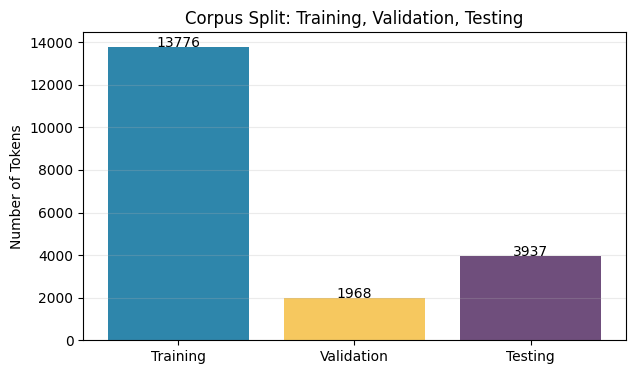

In [4]:
split_labels = ["Training", "Validation", "Testing"]
split_counts = [len(train_raw), len(valid_raw), len(test_raw)]
split_colors = ["#2E86AB", "#F6C85F", "#6F4E7C"]

plt.figure(figsize=(7, 4))
bars = plt.bar(split_labels, split_counts, color=split_colors)
plt.title("Corpus Split: Training, Validation, Testing")
plt.ylabel("Number of Tokens")
plt.grid(axis="y", alpha=0.25)

for bar, count in zip(bars, split_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, str(count), ha="center")

plt.show()

## 4. Vocabulary Limiting with `<UNK>`

In [5]:
def build_vocab(tokens, vocab_size):
    special = {"<UNK>", "<s>", "</s>"}
    most_common = [token for token, _ in Counter(tokens).most_common(max(0, vocab_size - len(special)))]
    return set(most_common) | special

def replace_unk(tokens, vocab):
    return [token if token in vocab else "<UNK>" for token in tokens]

def add_sentence_boundaries(tokens, n=4):
    output = ["<s>"] * (n - 1)
    for token in tokens:
        output.append(token)
        if token in {"។", "៕", "!", "?"}:
            output.extend(["</s>"] + ["<s>"] * (n - 1))
    output.append("</s>")
    return output

vocab_size = min(500, max(50, len(set(train_raw))))
vocab = build_vocab(train_raw, vocab_size)
train = add_sentence_boundaries(replace_unk(train_raw, vocab))
valid = replace_unk(valid_raw, vocab)
test = replace_unk(test_raw, vocab)

print("Vocabulary size:", len(vocab))
print("Validation <UNK> tokens:", valid.count("<UNK>"))
print("Test <UNK> tokens:", test.count("<UNK>"))

Vocabulary size: 500
Validation <UNK> tokens: 660
Test <UNK> tokens: 1433


## 5. N-gram Counting

In [6]:
def count_ngrams(tokens, max_order=4):
    counts = {order: Counter() for order in range(1, max_order + 1)}
    context_counts = {order: Counter() for order in range(2, max_order + 1)}
    followers = {order: defaultdict(list) for order in range(2, max_order + 1)}

    for order in range(1, max_order + 1):
        for i in range(len(tokens) - order + 1):
            gram = tuple(tokens[i:i + order])
            counts[order][gram] += 1
            if order > 1:
                context_counts[order][gram[:-1]] += 1

    for order in range(2, max_order + 1):
        seen = defaultdict(set)
        for gram, count in counts[order].items():
            context, token = gram[:-1], gram[-1]
            if token not in seen[context]:
                followers[order][context].append((token, count))
                seen[context].add(token)

    return counts, context_counts, followers

## 6. LM1: Unsmoothed Backoff 4-gram Model

LM1 first tries a 4-gram probability. If it cannot find the 4-gram, it backs off to 3-gram, then 2-gram, then unigram.

In [7]:
class BackoffLM:
    def __init__(self, tokens, vocab, max_order=4):
        self.max_order = max_order
        self.vocab = sorted(vocab)
        self.counts, self.context_counts, self.followers = count_ngrams(tokens, max_order)
        self.unigram_total = sum(self.counts[1].values())

    def probability(self, context, token):
        for order in range(min(self.max_order, len(context) + 1), 1, -1):
            current_context = context[-(order - 1):]
            gram = current_context + (token,)
            gram_count = self.counts[order].get(gram, 0)
            context_count = self.context_counts[order].get(current_context, 0)
            if gram_count > 0 and context_count > 0:
                return gram_count / context_count
        return self.counts[1].get((token,), 0) / self.unigram_total if self.unigram_total else 0.0

    def next_token(self, context, rng):
        for order in range(min(self.max_order, len(context) + 1), 1, -1):
            current_context = context[-(order - 1):]
            choices = self.followers[order].get(current_context)
            if choices:
                tokens_, weights = zip(*choices)
                return rng.choices(tokens_, weights=weights, k=1)[0]
        tokens_, weights = zip(*self.counts[1].items())
        return rng.choices([token[0] for token in tokens_], weights=weights, k=1)[0]

## 7. LM2: Interpolation 4-gram Model with Add-k Smoothing

LM2 combines unigram, bigram, trigram, and 4-gram probabilities with lambda weights. Each n-gram probability uses add-k smoothing.

In [8]:
class InterpolationLM:
    def __init__(self, tokens, vocab, lambdas, k, max_order=4):
        self.max_order = max_order
        self.vocab = sorted(vocab)
        self.lambdas = lambdas
        self.k = k
        self.counts, self.context_counts, self.followers = count_ngrams(tokens, max_order)
        self.unigram_total = sum(self.counts[1].values())

    def order_probability(self, order, context, token):
        vocab_n = len(self.vocab)
        if order == 1:
            return (self.counts[1].get((token,), 0) + self.k) / (self.unigram_total + self.k * vocab_n)
        current_context = context[-(order - 1):]
        gram = current_context + (token,)
        return (self.counts[order].get(gram, 0) + self.k) / (
            self.context_counts[order].get(current_context, 0) + self.k * vocab_n
        )

    def probability(self, context, token):
        return sum(
            self.lambdas[order - 1] * self.order_probability(order, context, token)
            for order in range(1, self.max_order + 1)
        )

    def next_token(self, context, rng):
        weights = [self.probability(context, token) for token in self.vocab]
        return rng.choices(self.vocab, weights=weights, k=1)[0]

## 8. Perplexity and Text Generation Functions

In [9]:
def perplexity(model, tokens, max_order=4):
    tokens = add_sentence_boundaries(tokens, max_order)
    log_prob = 0.0
    evaluated = 0
    for i in range(max_order - 1, len(tokens)):
        token = tokens[i]
        if token == "<s>":
            continue
        context = tuple(tokens[i - (max_order - 1):i])
        prob = model.probability(context, token)
        if prob <= 0.0:
            return float("inf")
        log_prob += math.log(prob)
        evaluated += 1
    return math.exp(-log_prob / max(1, evaluated))

def generate(model, seed, length=45, random_seed=7):
    rng = random.Random(random_seed)
    seed_tokens = tokenize(seed) if isinstance(seed, str) else list(seed)
    context = tuple((["<s>", "<s>", "<s>"] + seed_tokens)[-3:])
    generated = list(seed_tokens)
    for _ in range(length):
        token = model.next_token(context, rng)
        if token == "</s>":
            break
        if token != "<s>":
            generated.append(token)
        context = tuple((list(context) + [token])[-3:])
    return " ".join(generated).replace(" ។", "។").replace(" ៕", "៕")

## 9. Train Models and Tune Hyperparameters

In [10]:
backoff_model = BackoffLM(train, vocab)

lambda_grid = [
    (0.40, 0.30, 0.20, 0.10),
    (0.35, 0.30, 0.20, 0.15),
    (0.30, 0.30, 0.25, 0.15),
    (0.25, 0.25, 0.25, 0.25),
    (0.20, 0.30, 0.30, 0.20),
    (0.15, 0.25, 0.30, 0.30),
    (0.10, 0.20, 0.30, 0.40),
    (0.05, 0.15, 0.30, 0.50),
    (0.10, 0.10, 0.30, 0.50),
    (0.05, 0.10, 0.25, 0.60),
]

k_grid = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]

experiments = []
best = None
for lambdas in lambda_grid:
    for k in k_grid:
        model = InterpolationLM(train, vocab, lambdas=lambdas, k=k)
        pp = perplexity(model, valid)
        row = {"lambdas": lambdas, "k": k, "validation_perplexity": pp}
        experiments.append(row)
        if best is None or pp < best["validation_perplexity"]:
            best = row

interpolation_model = InterpolationLM(train, vocab, lambdas=best["lambdas"], k=best["k"])
best

{'lambdas': (0.4, 0.3, 0.2, 0.1),
 'k': 0.001,
 'validation_perplexity': 47.44928226995315}

## 10. Test Evaluation Results

Perplexity is used to compare the models. A lower perplexity means the model is less surprised by the test text and predicts the next token better.

In [11]:
backoff_test_pp = perplexity(backoff_model, test)
interpolation_test_pp = perplexity(interpolation_model, test)

result_table = pd.DataFrame([
    {
        "Model": "LM1",
        "Method": "Unsmoothed backoff 4-gram",
        "Best parameters": "No lambda/k",
        "Validation perplexity": "-",
        "Test perplexity": round(backoff_test_pp, 4),
    },
    {
        "Model": "LM2",
        "Method": "Interpolation + add-k smoothing",
        "Best parameters": f"lambdas={best['lambdas']}, k={best['k']}",
        "Validation perplexity": round(best["validation_perplexity"], 4),
        "Test perplexity": round(interpolation_test_pp, 4),
    },
])

display(result_table)

print("Best lambdas for LM2:", best["lambdas"])
print("Best k for LM2:", best["k"])
print("LM1 Backoff test perplexity:", round(backoff_test_pp, 4))
print("LM2 Interpolation test perplexity:", round(interpolation_test_pp, 4))

,Model,Method,Best parameters,Validation perplexity,Test perplexity
0,LM1,Unsmoothed backoff 4-gram,No lambda/k,-,27.2196
1,LM2,Interpolation + add-k smoothing,"lambdas=(0.4, 0.3, 0.2, 0.1), k=0.001",47.4493,45.7879


Best lambdas for LM2: (0.4, 0.3, 0.2, 0.1)
Best k for LM2: 0.001
LM1 Backoff test perplexity: 27.2196
LM2 Interpolation test perplexity: 45.7879


**Interpretation:** Lower perplexity means better next-token prediction. In this experiment, LM1 Backoff performs better because its test perplexity is lower than LM2. With a small corpus, the backoff model can reuse observed local patterns effectively. LM2 is more flexible because of smoothing and interpolation, but it spreads probability across more vocabulary items, which can reduce accuracy on a small test set.

## 10.1 Model Perplexity Visualization

This bar chart compares the final test perplexity of LM1 and LM2. Lower perplexity means better prediction performance.

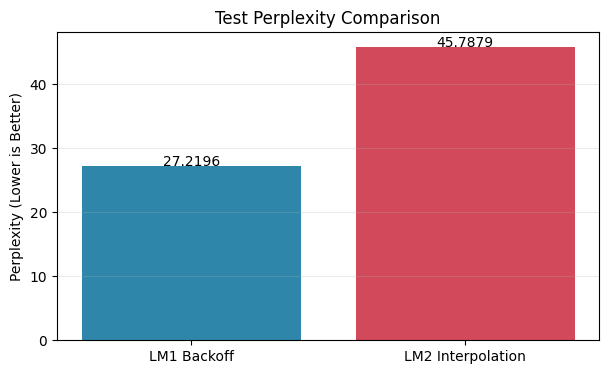

In [12]:
model_names = ["LM1 Backoff", "LM2 Interpolation"]
test_perplexities = [backoff_test_pp, interpolation_test_pp]
colors = ["#2E86AB", "#D1495B"]

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, test_perplexities, color=colors)
plt.title("Test Perplexity Comparison")
plt.ylabel("Perplexity (Lower is Better)")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, test_perplexities):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f"{value:.4f}", ha="center")

plt.show()

## 11. Vocabulary Size Experiment

The assignment asks us to limit the vocabulary and replace the remaining tokens with `<UNK>`. To show the effect of this choice, I tested three vocabulary sizes. This gives the project stronger experimental evidence, not only one fixed setting.

In [13]:
def run_experiment_for_vocab_size(vocab_cap):
    exp_vocab = build_vocab(train_raw, min(vocab_cap, max(50, len(set(train_raw)))))
    exp_train = add_sentence_boundaries(replace_unk(train_raw, exp_vocab))
    exp_valid = replace_unk(valid_raw, exp_vocab)
    exp_test = replace_unk(test_raw, exp_vocab)

    exp_backoff = BackoffLM(exp_train, exp_vocab)
    exp_best = None
    for lambdas in lambda_grid:
        for k in k_grid:
            exp_model = InterpolationLM(exp_train, exp_vocab, lambdas=lambdas, k=k)
            valid_pp = perplexity(exp_model, exp_valid)
            if exp_best is None or valid_pp < exp_best["validation_perplexity"]:
                exp_best = {"lambdas": lambdas, "k": k, "validation_perplexity": valid_pp}

    exp_interpolation = InterpolationLM(exp_train, exp_vocab, lambdas=exp_best["lambdas"], k=exp_best["k"])
    return {
        "Vocabulary cap": vocab_cap,
        "Actual vocab size": len(exp_vocab),
        "Validation <UNK>": exp_valid.count("<UNK>"),
        "Test <UNK>": exp_test.count("<UNK>"),
        "LM1 test perplexity": round(perplexity(exp_backoff, exp_test), 4),
        "LM2 test perplexity": round(perplexity(exp_interpolation, exp_test), 4),
        "Best LM2 lambdas": exp_best["lambdas"],
        "Best k": exp_best["k"],
    }

vocab_experiment_table = pd.DataFrame([
    run_experiment_for_vocab_size(vocab_cap)
    for vocab_cap in [100, 200, 300, 500, 700, 1000]
])

display(vocab_experiment_table)

,Vocabulary cap,Actual vocab size,Validation <UNK>,Test <UNK>,LM1 test perplexity,LM2 test perplexity,Best LM2 lambdas,Best k
0,100,100,1164,2344,7.0151,9.1844,"(0.3, 0.3, 0.25, 0.15)",0.001
1,200,200,930,2021,11.3045,16.1981,"(0.4, 0.3, 0.2, 0.1)",0.001
2,300,300,808,1783,16.2645,24.7400,"(0.4, 0.3, 0.2, 0.1)",0.001
3,500,500,660,1433,27.2196,45.7879,"(0.4, 0.3, 0.2, 0.1)",0.001
4,700,700,574,1233,38.2488,68.3284,"(0.4, 0.3, 0.2, 0.1)",0.001
5,1000,1000,523,1119,49.2772,92.2916,"(0.4, 0.3, 0.2, 0.1)",0.001


## 11.1 Vocabulary Experiment Visualization

This line chart shows how test perplexity changes when the vocabulary cap changes. It helps explain the trade-off between vocabulary size and model sparsity.

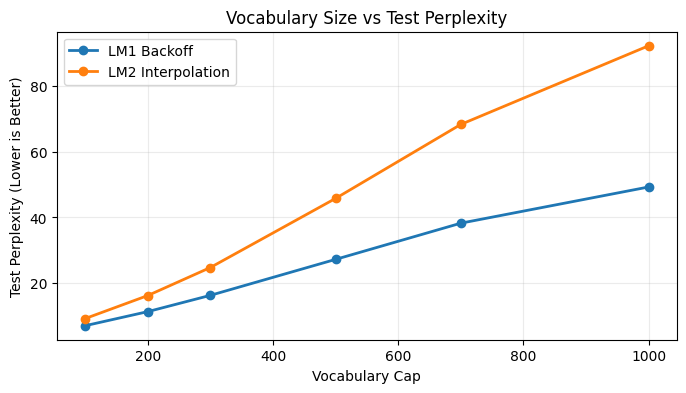

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(
    vocab_experiment_table["Vocabulary cap"],
    vocab_experiment_table["LM1 test perplexity"],
    marker="o",
    linewidth=2,
    label="LM1 Backoff",
)
plt.plot(
    vocab_experiment_table["Vocabulary cap"],
    vocab_experiment_table["LM2 test perplexity"],
    marker="o",
    linewidth=2,
    label="LM2 Interpolation",
)
plt.title("Vocabulary Size vs Test Perplexity")
plt.xlabel("Vocabulary Cap")
plt.ylabel("Test Perplexity (Lower is Better)")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

**Vocabulary experiment interpretation:** A smaller vocabulary creates more `<UNK>` tokens. A larger vocabulary keeps more original words, but it can also make the model more sparse because there are more possible tokens to estimate. This experiment helps justify the chosen vocabulary size instead of treating it as arbitrary.

## 12. Text Generation Examples

The text generator starts with a seed phrase and predicts the next token repeatedly. I test three different seed phrases to compare how the models behave with different starting contexts.

In [15]:
seed_phrases = ["អង្គរវត្ត", "ប្រាសាទ", "ស្ថាបត្យកម្ម"]

for seed_text in seed_phrases:
    print("=" * 80)
    print("Seed:", seed_text)
    print("\nLM1 Backoff generated text:")
    print(generate(backoff_model, seed_text, length=30, random_seed=11))
    print("\nLM2 Interpolation generated text:")
    print(generate(interpolation_model, seed_text, length=30, random_seed=11))
    print()

Seed: អង្គរវត្ត

LM1 Backoff generated text:
អង្គរវត្ត នៃ <UNK> បារាំង ការរកឃើញ ប្រាសាទ អង្គរវត្ត ជាមួយនិង <UNK> នូវ <UNK> <UNK> និង <UNK> ដើម្បី <UNK> ប្រព័ន្ធ <UNK> និង ជា <UNK> ដ៏ <UNK> នៅក្នុង <UNK> <UNK> នៅ ឆ្នាំ <UNK> ហើយ ទ្រង់

LM2 Interpolation generated text:
អង្គរវត្ត នៃ ចម្លាក់ សូរ្យ ប្រាសាទ ន័យ ថា ដៃ ប្រព័ន្ធ រដូវ <UNK> គេ <UNK> មាន ន័យ <UNK>។ អង្គរវត្ត ប្រាសាទ ភ្នំ <UNK> <UNK> ទីក្រុង <UNK> <UNK> <UNK> តែ បាន ល្បីល្បាញ

Seed: ប្រាសាទ

LM1 Backoff generated text:
ប្រាសាទ នេះ កសាង នៅ ចុង សតវត្សរ៍ ទី ១២ និង ១៣។

LM2 Interpolation generated text:
ប្រាសាទ នេះ បង្ហាញ ឲ្យដឹង ថា ត្រូវបាន ទៅជា <UNK> ទើប នៅក្នុង រូបរាង <UNK> <UNK> របស់ ព្រះអង្គ <UNK>។ អង្គរវត្ត ប្រាសាទ ភ្នំ <UNK> <UNK> ទីក្រុង <UNK> <UNK> <UNK> តែ បាន ល្បីល្បាញ

Seed: ស្ថាបត្យកម្ម

LM1 Backoff generated text:
ស្ថាបត្យកម្ម អង្គរវត្ត ប្រាសាទ អង្គរវត្ត ត្រូវបាន <UNK> ចោល ដោយ សង្គ្រាម ឈ្លានពាន របស់ កងទ័ព សៀម ក្នុង អំឡុង ស. វទី <UNK> ក្នុង រាជ ព្រះបាទ បរម រាជ <UNK> តាមរយៈ <UNK> <UNK> ដោយ លោក <UNK> <UNK>

LM2 Interpolatio

## 13. Interactive Text Generator Demo

This small UI is useful for presentation. Type a Khmer starting word or phrase, choose one model, and click **Generate Text**. For a cleaner demo, use **LM1 Backoff** with a shorter length because it has lower perplexity on this corpus. The generated text may show `<UNK>` because vocabulary limiting is part of the assignment preprocessing.

### 13.1 Demo Guidance

For presentation, LM1 Backoff is recommended because it has lower test perplexity and usually produces cleaner short text. Keep the length around 20-30 tokens. Longer output is possible, but it often becomes less readable because this is a simple n-gram model trained on a small corpus.

In [16]:
import ipywidgets as widgets
from IPython.display import HTML, display, clear_output
from collections import Counter
import random
import re
import html

# Rare words are words from the article that are outside the selected vocabulary.
rare_word_counts = Counter([word for word in tokens if word not in vocab])
rare_word_pool = [word for word, count in rare_word_counts.most_common()]

def replace_unk_with_rare_words(text, random_seed=7):
    rng = random.Random(random_seed)
    output_tokens = []

    for token in text.split():
        if token == "<UNK>":
            if rare_word_pool:
                rare_word = rng.choice(rare_word_pool)
                output_tokens.append(f"[{rare_word}]")
            else:
                output_tokens.append("[RARE_WORD]")
        else:
            output_tokens.append(token)

    return " ".join(output_tokens)

def count_unk(text):
    return text.split().count("<UNK>")

seed_box = widgets.Text(
    value="ប្រាសាទ អង្គរវត្ត",
    description="Seed:",
    layout=widgets.Layout(width="650px")
)

model_dropdown = widgets.Dropdown(
    options=[("LM1 Backoff", "backoff"), ("LM2 Interpolation", "interpolation")],
    value="backoff",
    description="Model:",
    layout=widgets.Layout(width="350px")
)

length_slider = widgets.IntSlider(
    value=25,
    min=10,
    max=60,
    step=5,
    description="Length:",
    continuous_update=False
)

generate_button = widgets.Button(
    description="Generate Text",
    button_style="success"
)

output_area = widgets.Output()

def on_generate_clicked(_):
    with output_area:
        clear_output()

        model = backoff_model if model_dropdown.value == "backoff" else interpolation_model

        raw_text = generate(
            model,
            seed_box.value,
            length=length_slider.value,
            random_seed=random.randint(1, 100000)
        )

        clean_text = replace_unk_with_rare_words(
            raw_text,
            random_seed=random.randint(1, 100000)
        )

        unk_total = count_unk(raw_text)

        raw_text_html = html.escape(raw_text)
        clean_text_html = html.escape(clean_text)

        display(HTML(f'''
        <h4>Raw Text</h4>
        <p><b>&lt;UNK&gt; count:</b> {unk_total}</p>

        <div style="
            border:1px solid #d0d7de;
            border-radius:6px;
            padding:14px;
            max-width:900px;
            white-space:normal;
            line-height:1.8;
            font-size:18px;
            font-family:'Khmer OS Siemreap','Noto Sans Khmer',Arial,sans-serif;">
            {raw_text_html}
        </div>

        <h4>Clean Text</h4>
        <p>Each &lt;UNK&gt; is replaced by a sample rare article word inside [ ].</p>

        <div style="
            border:1px solid #d0d7de;
            border-radius:6px;
            padding:14px;
            max-width:900px;
            white-space:normal;
            line-height:1.8;
            font-size:18px;
            font-family:'Khmer OS Siemreap','Noto Sans Khmer',Arial,sans-serif;">
            {clean_text_html}
        </div>
        '''))

generate_button.on_click(on_generate_clicked)

display(widgets.VBox([
    seed_box,
    model_dropdown,
    length_slider,
    generate_button,
    output_area
]))

In [17]:
print("Vocabulary size:", len(vocab))
print("First 50 vocabulary words:")
print(list(vocab)[:50])


Vocabulary size: 500
First 50 vocabulary words:
['ទាំងនោះ', 'វាយ', 'សោយរាជ្យ', 'គ្រិស្ត', 'ថ្ងៃ', 'ពាក្យ', 'រី', 'ចំណុច', 'ព្រះនាម', 'ល្អ', 'ថែវ', '១៣', 'រាជ', 'វស្សា', 'ដ៏', 'កណ្ដាល', 'ដោយសារ', 'ថ្ម', 'តែ', 'ទុក', 'ទន្លេ', 'ជាមួយនិង', 'ឬ', 'អ្នក', 'ឋាន', 'ព្រះអង្គ', 'ខាងលើ', 'ទីនោះ', 'ចុង', 'បារាយណ៍', 'ទេវតា', 'មួយ', 'បាគង', 'ថា', 'សករាជ', 'សាងសង់', 'ដាប', 'ផ្ទៃដី', 'ទៀតផង', 'កងទ័ព', 'ដើម្បី', 'ឲ្យ', 'អាណាចក្រ', 'ក្រហម', 'បន្តបន្ទាប់', 'ព្រឹត្តិការណ៍', 'តូច', 'ក្រោយ', 'បំផុត', 'នាក់']


In [18]:
print("Vocabulary size:", len(vocab))
print("Number of tokens:", len(tokens))
print("Number of rare tokens mapped to <UNK>:", len([w for w in tokens if w not in vocab]))


Vocabulary size: 500
Number of tokens: 19681
Number of rare tokens mapped to <UNK>: 5323


In [19]:
from collections import Counter
import pandas as pd

rare_words = [word for word in tokens if word not in vocab]

rare_word_table = pd.DataFrame(
    Counter(rare_words).most_common(50),
    columns=["Word mapped to <UNK>", "Frequency"]
)

rare_word_table


,Word mapped to <UNK>,Frequency
0,ចាម,24
1,ចាម្ប៉ា,22
2,វម៌្ម,18
3,អោយ,18
4,ចិន,17
5,ជយវម៌្ម,17
6,មាស,16
7,ពុទ្ធសាសនា,15
8,កាន់,15
9,ប្រជារាស្ត្រ,14


In [20]:
print("Vocabulary size:", len(vocab))
print(vocab)


Vocabulary size: 500
{'ទាំងនោះ', 'វាយ', 'សោយរាជ្យ', 'គ្រិស្ត', 'ថ្ងៃ', 'ពាក្យ', 'រី', 'ចំណុច', 'ព្រះនាម', 'ល្អ', 'ថែវ', '១៣', 'រាជ', 'វស្សា', 'ដ៏', 'កណ្ដាល', 'ដោយសារ', 'ថ្ម', 'តែ', 'ទុក', 'ទន្លេ', 'ជាមួយនិង', 'ឬ', 'អ្នក', 'ឋាន', 'ព្រះអង្គ', 'ខាងលើ', 'ទីនោះ', 'ចុង', 'បារាយណ៍', 'ទេវតា', 'មួយ', 'បាគង', 'ថា', 'សករាជ', 'សាងសង់', 'ដាប', 'ផ្ទៃដី', 'ទៀតផង', 'កងទ័ព', 'ដើម្បី', 'ឲ្យ', 'អាណាចក្រ', 'ក្រហម', 'បន្តបន្ទាប់', 'ព្រឹត្តិការណ៍', 'តូច', 'ក្រោយ', 'បំផុត', 'នាក់', 'ទាហាន', 'មុខ', 'ដំណើរ', 'ស្រុក', 'អស់', 'ពុទ្ធ', 'ដី', 'រជ្ជកាល', 'បង្កើត', 'អម្រឹត', 'ចេក', 'ដូច្នេះ', 'គេ', 'ជាតិ', 'ឆ្នាំ', 'ចុះ', 'ធ្លាក់', 'ថៃ្ង', 'ទិស', 'ប្រជាជន', 'ប្រារព្ធ', 'ដាក់', 'ទឹក', 'យើង', 'សោវ', 'ជាង', 'មិន', 'រួច', 'សម័យកាល', 'លើ', 'ឈ្លានពាន', 'ខែ្មរ', 'អំបូរ', 'គិត', 'នៅលើ', 'ជំនឿ', 'ផង', 'អង្គរវត្ត', 'អន្តរជាតិ', 'ន័យ', 'រវាង', 'ស្ដេច', 'គឺជា', 'ឯកសារ', 'ស្ទឹង', 'ព្រះរាជាណាចក្រ', 'ពាយ័ព្យ', 'បង្ក្រាប', '០៦', 'ខ្លោងទ្វារ', 'ក៏', 'ជាមួយ', 'ជនជាតិ', 'យាង', 'ហៅ', 'ប្រើប្រាស់', 'គ្នា', 'យក្ស', 'បញ្ជាក់', 'ត្រឡប់', '

In [21]:
import pandas as pd
from collections import Counter

vocab_table = pd.DataFrame({
    "Vocabulary word": sorted(list(vocab))
})

vocab_table


,Vocabulary word
0,</s>
1,<UNK>
2,<s>
3,ក
4,កងទ័ព
...,...
495,១៥
496,១៦
497,២
498,៣


## 14. Conclusion

This notebook successfully implements the required 4-gram language modeling project using a combined Khmer Wikipedia corpus related to **ប្រាសាទ អង្គរវត្ត**. The corpus is split into 70% training, 10% validation, and 20% testing. A limited vocabulary is created from the training set, and tokens outside the vocabulary are replaced with `<UNK>` as required.

The experiment shows that **LM1 Backoff** performs better than **LM2 Interpolation with add-k smoothing** on the test set. This is likely because the corpus is still limited compared with large NLP corpora, so the backoff model benefits from memorized local patterns. LM2 is more flexible and handles unseen events more smoothly, but this flexibility does not improve perplexity on this small dataset.

The generated text demonstrates how a 4-gram model predicts the next token using the previous three tokens. The output is not always perfectly natural because Khmer word segmentation is difficult with simple whitespace tokenization, and the corpus is not large enough for high-quality generation. A future improvement would be to use a Khmer word segmentation tool and a larger corpus.

In [23]:
import pandas as pd

def seed_to_context(seed_text, n=4):
    seed_tokens = tokenize(seed_text)
    return tuple((["<s>"] * (n - 1) + seed_tokens)[-(n - 1):])

def explain_lm2_next_word(seed_text, candidate_word=None, top_n=10):
    model = interpolation_model
    context = seed_to_context(seed_text, n=4)

    # If candidate word is not provided, use the model's highest-probability next word.
    if candidate_word is None:
        scores = [(word, model.probability(context, word)) for word in model.vocab]
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        candidate_word = scores[0][0]
    else:
        candidate_word = candidate_word if candidate_word in vocab else "<UNK>"

    rows = []
    vocab_n = len(model.vocab)

    for order in range(1, model.max_order + 1):
        lambda_value = model.lambdas[order - 1]

        if order == 1:
            count_value = model.counts[1].get((candidate_word,), 0)
            context_count = model.unigram_total
            denominator = model.unigram_total + model.k * vocab_n
            probability = (count_value + model.k) / denominator
            context_used = "(overall corpus)"
            ngram_used = candidate_word
        else:
            context_used_tuple = context[-(order - 1):]
            gram = context_used_tuple + (candidate_word,)

            count_value = model.counts[order].get(gram, 0)
            context_count = model.context_counts[order].get(context_used_tuple, 0)
            denominator = context_count + model.k * vocab_n
            probability = (count_value + model.k) / denominator

            context_used = " ".join(context_used_tuple)
            ngram_used = " ".join(gram)

        contribution = lambda_value * probability

        rows.append({
            "Order": f"{order}-gram",
            "Context used": context_used,
            "N-gram checked": ngram_used,
            "Count": count_value,
            "Context count": context_count,
            "k": model.k,
            "Vocabulary size": vocab_n,
            "Probability": probability,
            "Lambda": lambda_value,
            "Lambda × Probability": contribution
        })

    df = pd.DataFrame(rows)
    final_probability = df["Lambda × Probability"].sum()

    top_candidates = sorted(
        [(word, model.probability(context, word)) for word in model.vocab],
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    top_candidates_df = pd.DataFrame(
        top_candidates,
        columns=["Candidate next word", "Final interpolation probability"]
    )

    print("Seed text:", seed_text)
    print("Context used by 4-gram model:", context)
    print("Candidate word:", candidate_word)
    print("Final LM2 probability:", final_probability)

    display(df)
    print("\nTop candidate next words:")
    display(top_candidates_df)

    return df, top_candidates_df


In [26]:
explain_lm2_next_word(
    seed_text="ប្រាសាទ នេះ​ កសាង",
    candidate_word="នៅ",
    top_n=10
)


Seed text: ប្រាសាទ នេះ​ កសាង
Context used by 4-gram model: ('ប្រាសាទ', 'នេះ', 'កសាង')
Candidate word: នៅ
Final LM2 probability: 0.15459250248631132


,Order,Context used,N-gram checked,Count,Context count,k,Vocabulary size,Probability,Lambda,Lambda × Probability
0,1-gram,(overall corpus),នៅ,191,15420,0.001,500,0.012386,0.4,0.004954
1,2-gram,កសាង,កសាង នៅ,3,30,0.001,500,0.098393,0.3,0.029518
2,3-gram,នេះ កសាង,នេះ កសាង នៅ,1,2,0.001,500,0.400400,0.2,0.080080
3,4-gram,ប្រាសាទ នេះ កសាង,ប្រាសាទ នេះ កសាង នៅ,1,2,0.001,500,0.400400,0.1,0.040040



Top candidate next words:


,Candidate next word,Final interpolation probability
0,នៅ,0.154593
1,<UNK>,0.152767
2,សម្រាប់,0.130692
3,ប្រាសាទ,0.083513
4,<s>,0.032113
5,ដោយ,0.021929
6,ជា,0.014428
7,នៅក្នុង,0.014064
8,ក្នុង,0.011782
9,ភ្នំ,0.010952


(    Order      Context used       N-gram checked  Count  Context count      k  \
 0  1-gram  (overall corpus)                   នៅ    191          15420  0.001   
 1  2-gram              កសាង              កសាង នៅ      3             30  0.001   
 2  3-gram          នេះ កសាង          នេះ កសាង នៅ      1              2  0.001   
 3  4-gram  ប្រាសាទ នេះ កសាង  ប្រាសាទ នេះ កសាង នៅ      1              2  0.001   
 
    Vocabulary size  Probability  Lambda  Lambda × Probability  
 0              500     0.012386     0.4              0.004954  
 1              500     0.098393     0.3              0.029518  
 2              500     0.400400     0.2              0.080080  
 3              500     0.400400     0.1              0.040040  ,
   Candidate next word  Final interpolation probability
 0                  នៅ                         0.154593
 1               <UNK>                         0.152767
 2             សម្រាប់                         0.130692
 3             ប្រាសាទ                

In [25]:
explain_lm2_next_word(
    seed_text="ប្រាសាទ អង្គរវត្ត មាន",
    top_n=10
)


Seed text: ប្រាសាទ អង្គរវត្ត មាន
Context used by 4-gram model: ('ប្រាសាទ', 'អង្គរវត្ត', 'មាន')
Candidate word: <UNK>
Final LM2 probability: 0.2772689552933601


,Order,Context used,N-gram checked,Count,Context count,k,Vocabulary size,Probability,Lambda,Lambda × Probability
0,1-gram,(overall corpus),<UNK>,3230,15420,0.001,500,0.209461,0.4,0.083785
1,2-gram,មាន,មាន <UNK>,108,217,0.001,500,0.496556,0.3,0.148967
2,3-gram,អង្គរវត្ត មាន,អង្គរវត្ត មាន <UNK>,1,4,0.001,500,0.222444,0.2,0.044489
3,4-gram,ប្រាសាទ អង្គរវត្ត មាន,ប្រាសាទ អង្គរវត្ត មាន <UNK>,0,3,0.001,500,0.000286,0.1,0.000029



Top candidate next words:


,Candidate next word,Final interpolation probability
0,<UNK>,0.277269
1,ចម្លាក់,0.081024
2,កម្ពស់,0.078737
3,កំពូល,0.076108
4,<s>,0.032058
5,ទីតាំង,0.013137
6,</s>,0.010736
7,។,0.010710
8,ប្រាសាទ,0.010287
9,ន័យ,0.008506


(    Order           Context used               N-gram checked  Count  \
 0  1-gram       (overall corpus)                        <UNK>   3230   
 1  2-gram                    មាន                    មាន <UNK>    108   
 2  3-gram          អង្គរវត្ត មាន          អង្គរវត្ត មាន <UNK>      1   
 3  4-gram  ប្រាសាទ អង្គរវត្ត មាន  ប្រាសាទ អង្គរវត្ត មាន <UNK>      0   
 
    Context count      k  Vocabulary size  Probability  Lambda  \
 0          15420  0.001              500     0.209461     0.4   
 1            217  0.001              500     0.496556     0.3   
 2              4  0.001              500     0.222444     0.2   
 3              3  0.001              500     0.000286     0.1   
 
    Lambda × Probability  
 0              0.083785  
 1              0.148967  
 2              0.044489  
 3              0.000029  ,
   Candidate next word  Final interpolation probability
 0               <UNK>                         0.277269
 1             ចម្លាក់                         0.0810

In [27]:
import pandas as pd

def explain_lm1_next_word(seed_text, candidate_word=None, top_n=10):
    model = backoff_model
    context = seed_to_context(seed_text, n=4)

    rows = []

    # If candidate word is not provided, use highest-probability word from model vocabulary.
    if candidate_word is None:
        scores = [(word, model.probability(context, word)) for word in model.vocab]
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        candidate_word = scores[0][0]
    else:
        candidate_word = candidate_word if candidate_word in vocab else "<UNK>"

    selected_order = None
    final_probability = 0.0

    for order in range(min(model.max_order, len(context) + 1), 1, -1):
        context_used_tuple = context[-(order - 1):]
        gram = context_used_tuple + (candidate_word,)

        count_value = model.counts[order].get(gram, 0)
        context_count = model.context_counts[order].get(context_used_tuple, 0)

        if context_count > 0:
            probability = count_value / context_count
        else:
            probability = 0.0

        used_by_backoff = False

        if selected_order is None and count_value > 0 and context_count > 0:
            selected_order = order
            final_probability = probability
            used_by_backoff = True

        rows.append({
            "Order checked": f"{order}-gram",
            "Context used": " ".join(context_used_tuple),
            "N-gram checked": " ".join(gram),
            "Count": count_value,
            "Context count": context_count,
            "Probability": probability,
            "Used by LM1 Backoff?": "YES" if used_by_backoff else "NO"
        })

    # If no higher-order n-gram is found, back off to unigram.
    unigram_count = model.counts[1].get((candidate_word,), 0)
    unigram_total = model.unigram_total
    unigram_probability = unigram_count / unigram_total if unigram_total else 0.0

    if selected_order is None:
        selected_order = 1
        final_probability = unigram_probability
        used_unigram = "YES"
    else:
        used_unigram = "NO"

    rows.append({
        "Order checked": "1-gram",
        "Context used": "(overall corpus)",
        "N-gram checked": candidate_word,
        "Count": unigram_count,
        "Context count": unigram_total,
        "Probability": unigram_probability,
        "Used by LM1 Backoff?": used_unigram
    })

    df = pd.DataFrame(rows)

    top_candidates = sorted(
        [(word, model.probability(context, word)) for word in model.vocab],
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    top_candidates_df = pd.DataFrame(
        top_candidates,
        columns=["Candidate next word", "Backoff probability"]
    )

    print("Seed text:", seed_text)
    print("Context used by 4-gram model:", context)
    print("Candidate word:", candidate_word)
    print("Selected order:", f"{selected_order}-gram")
    print("Final LM1 probability:", final_probability)

    display(df)
    print("\nTop candidate next words:")
    display(top_candidates_df)

    return df, top_candidates_df


In [28]:
explain_lm1_next_word(
    seed_text="ប្រាសាទ អង្គរវត្ត មាន",
    candidate_word="កម្ពស់",
    top_n=10
)


Seed text: ប្រាសាទ អង្គរវត្ត មាន
Context used by 4-gram model: ('ប្រាសាទ', 'អង្គរវត្ត', 'មាន')
Candidate word: កម្ពស់
Selected order: 4-gram
Final LM1 probability: 0.3333333333333333


,Order checked,Context used,N-gram checked,Count,Context count,Probability,Used by LM1 Backoff?
0,4-gram,ប្រាសាទ អង្គរវត្ត មាន,ប្រាសាទ អង្គរវត្ត មាន កម្ពស់,1,3,0.333333,YES
1,3-gram,អង្គរវត្ត មាន,អង្គរវត្ត មាន កម្ពស់,1,4,0.250000,NO
2,2-gram,មាន,មាន កម្ពស់,4,217,0.018433,NO
3,1-gram,(overall corpus),កម្ពស់,5,15420,0.000324,NO



Top candidate next words:


,Candidate next word,Backoff probability
0,កម្ពស់,0.333333
1,កំពូល,0.333333
2,ចម្លាក់,0.333333
3,<UNK>,0.250000
4,<s>,0.079961
5,ទីតាំង,0.041475
6,ន័យ,0.027650
7,</s>,0.026654
8,។,0.026589
9,ឈ្មោះ,0.023041


(  Order checked           Context used                N-gram checked  Count  \
 0        4-gram  ប្រាសាទ អង្គរវត្ត មាន  ប្រាសាទ អង្គរវត្ត មាន កម្ពស់      1   
 1        3-gram          អង្គរវត្ត មាន          អង្គរវត្ត មាន កម្ពស់      1   
 2        2-gram                    មាន                    មាន កម្ពស់      4   
 3        1-gram       (overall corpus)                        កម្ពស់      5   
 
    Context count  Probability Used by LM1 Backoff?  
 0              3     0.333333                  YES  
 1              4     0.250000                   NO  
 2            217     0.018433                   NO  
 3          15420     0.000324                   NO  ,
   Candidate next word  Backoff probability
 0              កម្ពស់             0.333333
 1               កំពូល             0.333333
 2             ចម្លាក់             0.333333
 3               <UNK>             0.250000
 4                 <s>             0.079961
 5              ទីតាំង             0.041475
 6                 

In [29]:
explain_lm1_next_word(
    seed_text="ប្រាសាទ អង្គរវត្ត មាន",
    top_n=10
)


Seed text: ប្រាសាទ អង្គរវត្ត មាន
Context used by 4-gram model: ('ប្រាសាទ', 'អង្គរវត្ត', 'មាន')
Candidate word: កម្ពស់
Selected order: 4-gram
Final LM1 probability: 0.3333333333333333


,Order checked,Context used,N-gram checked,Count,Context count,Probability,Used by LM1 Backoff?
0,4-gram,ប្រាសាទ អង្គរវត្ត មាន,ប្រាសាទ អង្គរវត្ត មាន កម្ពស់,1,3,0.333333,YES
1,3-gram,អង្គរវត្ត មាន,អង្គរវត្ត មាន កម្ពស់,1,4,0.250000,NO
2,2-gram,មាន,មាន កម្ពស់,4,217,0.018433,NO
3,1-gram,(overall corpus),កម្ពស់,5,15420,0.000324,NO



Top candidate next words:


,Candidate next word,Backoff probability
0,កម្ពស់,0.333333
1,កំពូល,0.333333
2,ចម្លាក់,0.333333
3,<UNK>,0.250000
4,<s>,0.079961
5,ទីតាំង,0.041475
6,ន័យ,0.027650
7,</s>,0.026654
8,។,0.026589
9,ឈ្មោះ,0.023041


(  Order checked           Context used                N-gram checked  Count  \
 0        4-gram  ប្រាសាទ អង្គរវត្ត មាន  ប្រាសាទ អង្គរវត្ត មាន កម្ពស់      1   
 1        3-gram          អង្គរវត្ត មាន          អង្គរវត្ត មាន កម្ពស់      1   
 2        2-gram                    មាន                    មាន កម្ពស់      4   
 3        1-gram       (overall corpus)                        កម្ពស់      5   
 
    Context count  Probability Used by LM1 Backoff?  
 0              3     0.333333                  YES  
 1              4     0.250000                   NO  
 2            217     0.018433                   NO  
 3          15420     0.000324                   NO  ,
   Candidate next word  Backoff probability
 0              កម្ពស់             0.333333
 1               កំពូល             0.333333
 2             ចម្លាក់             0.333333
 3               <UNK>             0.250000
 4                 <s>             0.079961
 5              ទីតាំង             0.041475
 6                 